# AI Productivity: When AI Enters the Workflow

**Research question:** Beyond which threshold of AI usage does rework erode operational margins?

## Table of Contents

1. [Setup & Imports](#1.-setup-imports)
2. [Data Loading](#2.-data-loading)
3. [Preliminary EDA](#preliminary-eda)
4. [Data Cleaning](#data-cleaning)
5. [Feature Engineering](#feature-engineering)
7. [Post-Engineering Analysis](#7.-)
8. [Modeling](#modeling)
9. [Business Insights & Decision](#business-insights--decision)

## 1. Setup & Imports

We import the essential libraries for data manipulation, visualization, and statistical analysis. We set a random seed for reproducibility.

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)


-------
## 2. Data Loading

We load the CSV provided by Alkemy and perform a first inspection of its structure: dimensions, column names, data types, and a preview of the first rows.

In [193]:
df = pd.read_csv('ai_productivity_dataset_final.csv')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
df.head()

Shape: 3248 rows × 34 columns

Column names:
['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'task_complexity_score', 'brief_quality_score', 'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at', 'delivered_at', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version']


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2


-----
## 3. Preliminary EDA

The goal of this section is to understand what is in the raw data **before any cleaning**. We inspect data types, missing values, duplicates, distributions, outliers, and logical consistency issues. Every finding here will justify a specific cleaning decision in the next section.

### 3.1 — General Audit

We build a summary table showing, for each column: data type, number of missing values, number of unique values, and a sample value. This gives us an immediate overview of the dataset's structure and potential issues.

In [194]:
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'nunique': df.nunique(),
    'sample_value': [df[col].dropna().iloc[0] if df[col].notnull().any() else None for col in df.columns]
})

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns\n")
audit

Dataset: 3248 rows × 34 columns



,dtype,non_null,null_count,null_pct,nunique,sample_value
task_id,object,3248,0,0.00,3200,T00000
client,object,3248,0,0.00,28,Client_F
project_id,object,3248,0,0.00,64,P038
client_tier,object,3248,0,0.00,3,mid
team,object,3248,0,0.00,15,Content
task_type,object,3248,0,0.00,29,report
seniority,object,3248,0,0.00,3,junior
task_complexity_score,int64,3248,0,0.00,5,2
brief_quality_score,float64,3179,69,2.12,5,3.0
deadline_pressure,object,3248,0,0.00,3,high


The dataset contains 3,248 rows and 34 columns. Most columns are complete, but 8 have missing values: `ai_usage_pct` (144, 4.43%), `outcome_score` (133, 4.09%), `jira_ticket` (339, 10.44%), `billable_hours` (82, 2.52%), `rework_hours` (72, 2.22%), `brief_quality_score` (69, 2.12%), `delivered_at` (38, 1.17%), and `sla_days` (36, 1.11%).

A first anomaly is visible in `task_id`: 3,248 rows but only 3,200 unique values, indicating 48 duplicate entries. Two categorical columns show signs of data quality issues: `team` has 15 unique values (expected 4–5 teams) and `task_type` has 29 (far more than expected for a standard task classification), suggesting typos and inconsistent naming.

Data types are mostly appropriate. Date columns (`created_at`, `delivered_at`, `updated_at`) are stored as `object` and will need parsing. `ai_assisted` is already boolean. Financial variables (`revenue`, `cost`, `profit`) and time variables (`hours_spent`, `billable_hours`, `rework_hours`) are all float64 with no missing values, except `billable_hours` and `rework_hours`.

### 3.2 — Missing Values Analysis

We quantify and visualize the missing values across all columns. Understanding the extent and pattern of missingness is essential to choose the right imputation strategy in the cleaning phase.

Columns with missing values: 8 / 34

                     null_count  null_pct
jira_ticket                 339     10.44
ai_usage_pct                144      4.43
outcome_score               133      4.09
billable_hours               82      2.52
rework_hours                 72      2.22
brief_quality_score          69      2.12
delivered_at                 38      1.17
sla_days                     36      1.11


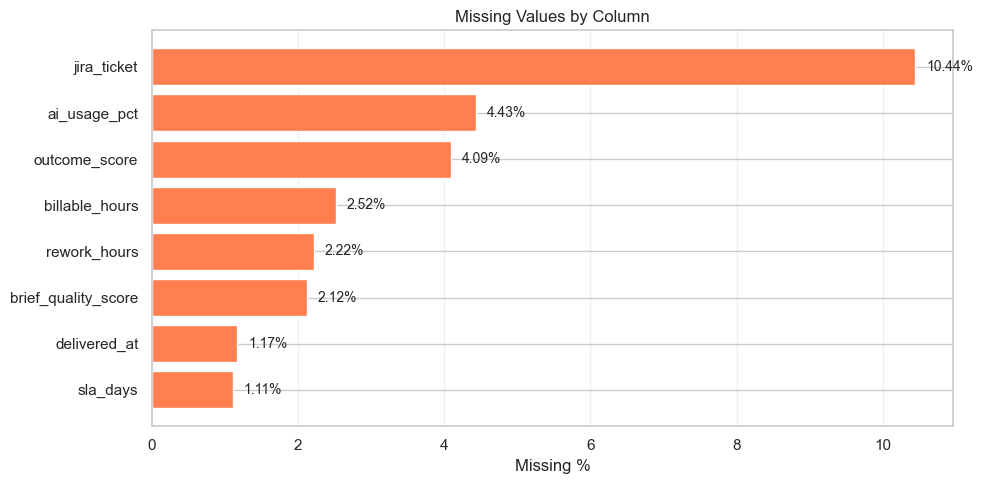

In [195]:
# Filter columns with at least one missing value
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'null_count': missing,
    'null_pct': missing_pct
})

print(f"Columns with missing values: {len(missing_df)} / {df.shape[1]}\n")
print(missing_df.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing_df.index[::-1], missing_df['null_pct'][::-1], color='coral', edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
ax.grid(axis='x', alpha=0.3)

for i, (val, name) in enumerate(zip(missing_df['null_pct'][::-1], missing_df.index[::-1])):
    ax.text(val + 0.15, i, f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

8 out of 34 columns have missing values. The most affected is `jira_ticket` (339, 10.44%), which is a metadata field and not critical for modeling. Among the analytically relevant variables, `ai_usage_pct` (144, 4.43%) and `outcome_score` (133, 4.09%) have the highest missingness, followed by `billable_hours` (82), `rework_hours` (72), and `brief_quality_score` (69), all in the 2–2.5% range. The two time-related columns `delivered_at` (38) and `sla_days` (36) have minimal gaps just above 1%. No column exceeds 11%, so the overall data completeness is high. The specific patterns behind these missing values — whether random or structurally driven — will be investigated during the cleaning phase.

### 3.3 — Duplicate Check

The audit showed 3,248 rows but only 3,200 unique `task_id` values. We investigate the nature of these duplicates to decide how to handle them in the cleaning phase.

In [196]:
# Count duplicates
n_dupes = df['task_id'].duplicated().sum()
n_unique_duped = df[df['task_id'].duplicated(keep=False)]['task_id'].nunique()
print(f"Duplicated rows: {n_dupes}")
print(f"Unique task_ids involved: {n_unique_duped}")
print(f"Total rows involved: {n_dupes + n_unique_duped}")

# Inspect a sample of duplicate pairs — compare key fields
duped_ids = df[df['task_id'].duplicated(keep=False)]['task_id'].unique()
compare_cols = ['task_id', 'client', 'hours_spent', 'revenue', 'cost', 'profit',
                'ai_usage_pct', 'created_by', 'updated_at', 'task_status', 'content_version']

print(f"\n--- Sample duplicate pairs (first 5) ---\n")
for tid in duped_ids[:5]:
    pair = df[df['task_id'] == tid][compare_cols]
    print(pair.to_string(index=False))
    print()

Duplicated rows: 48
Unique task_ids involved: 48
Total rows involved: 96

--- Sample duplicate pairs (first 5) ---

task_id   client  hours_spent  revenue   cost  profit  ai_usage_pct created_by updated_at task_status content_version
 T00010 Client_F        11.57   743.55 756.78  -13.23          0.38   user_064 2025-09-12   delivered           final
 T00010 Client_J        11.57   743.55 756.78  -13.23          0.38   user_078 2025-09-11 in_progress              v3

task_id   client  hours_spent  revenue   cost  profit  ai_usage_pct created_by updated_at task_status content_version
 T00139 Client_H        12.39  1130.56 919.75  210.81           NaN   user_011 2026-03-04 in_progress              v1
 T00139 Client_H        12.39  1130.56 919.75  210.81          0.47   user_059 2026-03-05   delivered              v4

task_id   client  hours_spent  revenue    cost  profit  ai_usage_pct created_by updated_at task_status content_version
 T00170 Client_H        13.34   795.16 1048.97 -253.81 

There are 48 duplicate `task_id` values, involving 96 total rows (48 pairs). Within each pair, the core business data is identical — `hours_spent`, `revenue`, `cost`, `profit`, and `ai_usage_pct` all match — while metadata fields differ: `created_by`, `updated_at`, `task_status`, and `content_version`. In one case (T00010) even `client` differs between the two rows (Client_F vs Client_J), suggesting a re-handling by the Client/Operator (`created_by`) for that task.

This pattern is consistent with system-level duplicates: the same task recorded twice with different metadata states, not genuinely distinct tasks. In the cleaning phase, for each pair we will keep the row with the most recent `updated_at`, as it represents the latest known state of the task.

### 3.4 — Categorical Variables

We inspect the frequency distribution of the main categorical variables to identify naming inconsistencies, unexpected values, and class imbalances.

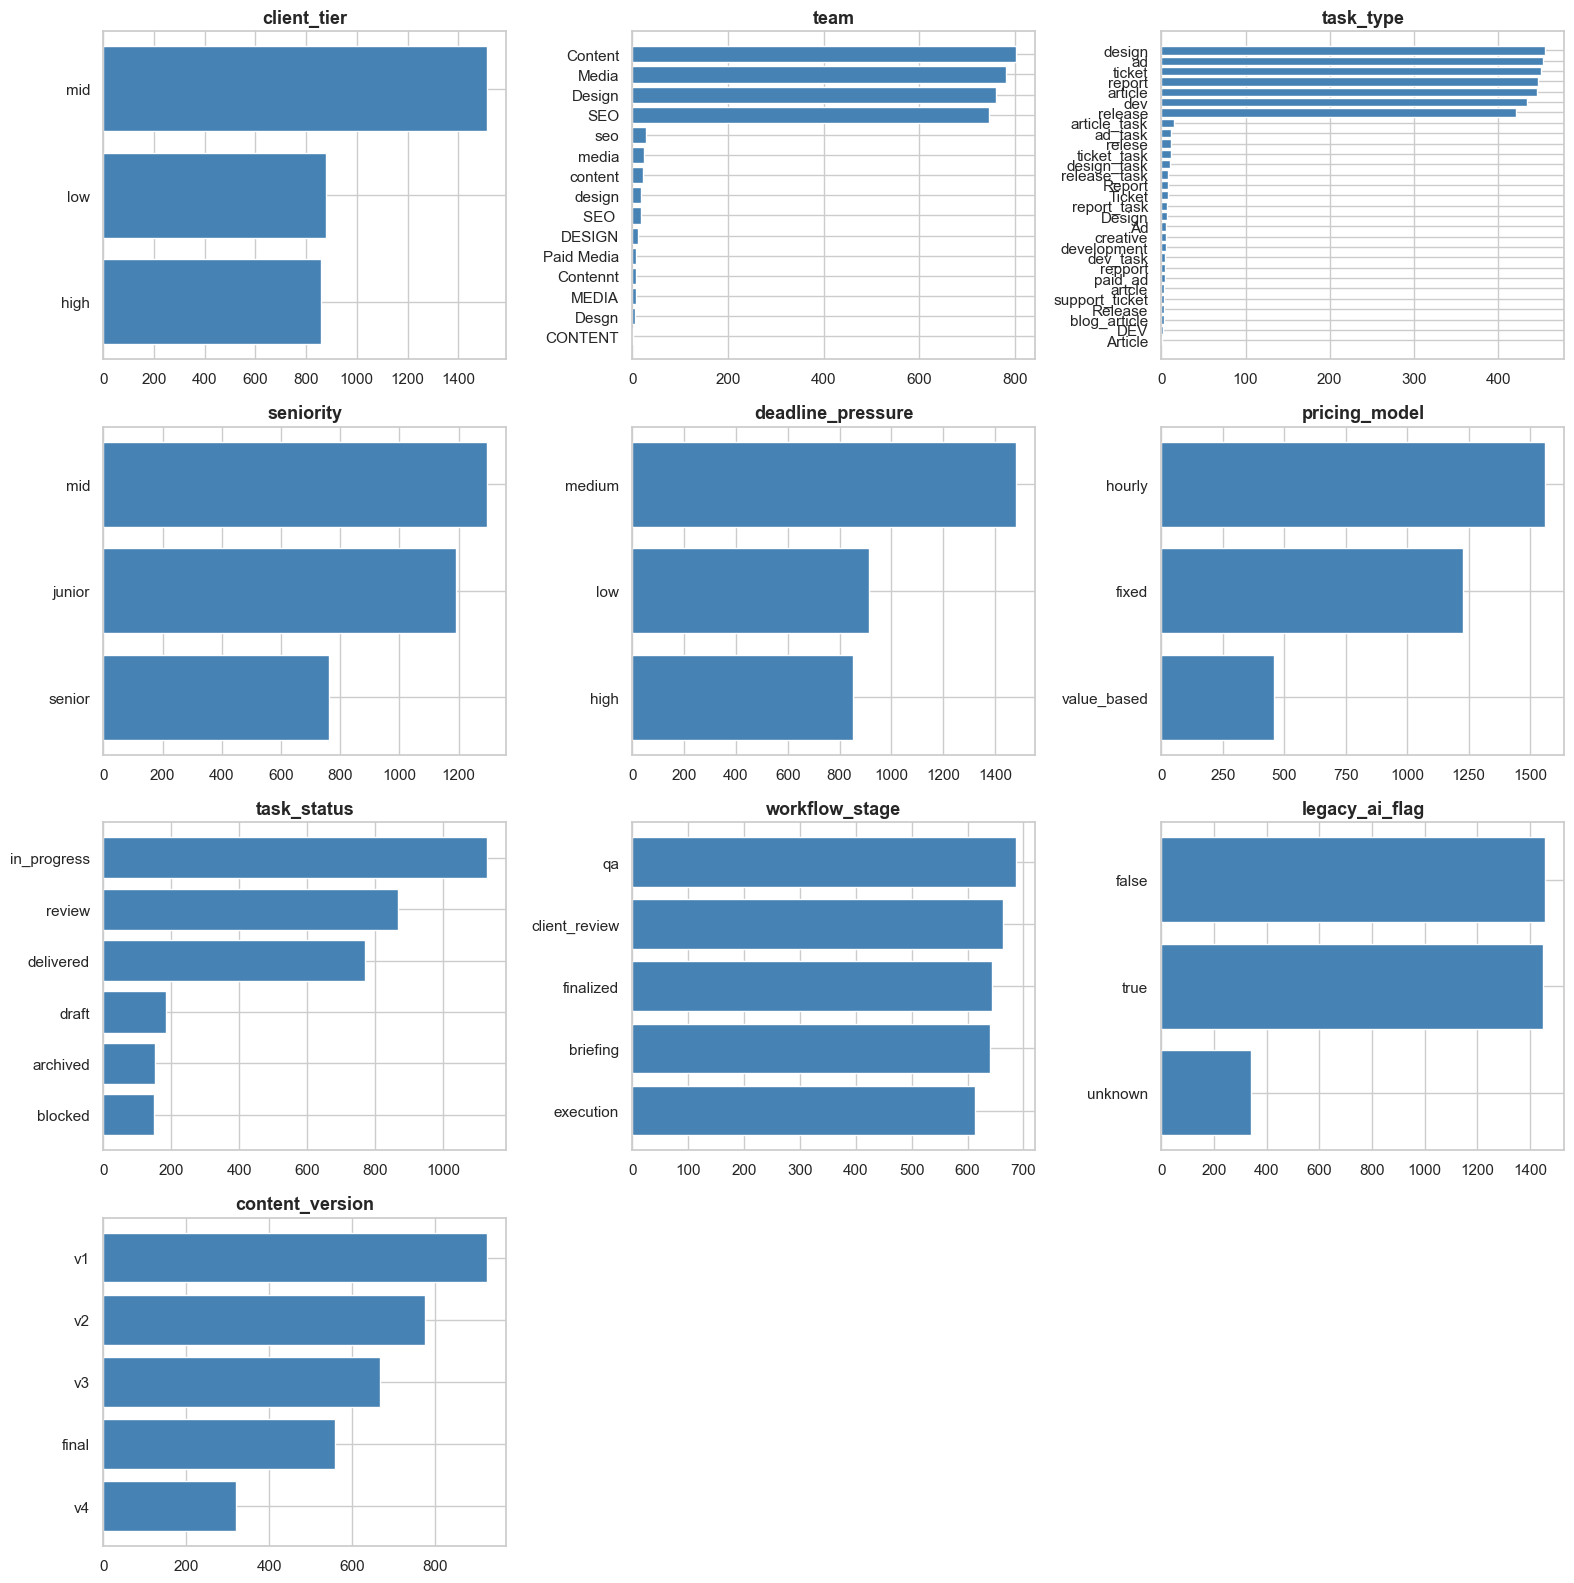

In [197]:
cat_cols = ['client_tier', 'team', 'task_type', 'seniority', 'deadline_pressure',
            'pricing_model', 'task_status', 'workflow_stage', 'legacy_ai_flag', 'content_version']

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    counts = df[col].value_counts()
    ax.barh(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.invert_yaxis()

for idx in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

The variables `client_tier`, `seniority`, `deadline_pressure`, and `workflow_stage` are clean and well-distributed, with no unexpected values. `pricing_model` shows a clear hierarchy: `hourly` dominates (~48%), followed by `fixed` (~38%) and `value_based` (~14%). `task_status` is skewed toward `in_progress` and `review`, with smaller groups for `draft`, `archived`, and `blocked`. `legacy_ai_flag` is split roughly 50/50 between `true` and `false`, with a third category `unknown` (~10%) that will need clarification. `content_version` ranges from `v1` to `v4` plus `final`, with a decreasing trend from v1 to v4.

The two most problematic columns are `team` and `task_type`. `team` has 15 unique values representing just 4 actual teams (Content, Design, Media, SEO), with case variations (content, CONTENT), typos (Contennt, Desgn), and a subcategory (Paid Media). `task_type` has 29 unique values that map to approximately 7 core categories, with similar issues: case inconsistencies, typos (relese, repport, artcle), suffixed variants (_task), and synonyms (creative, development, blog_post). Both columns require normalization in the cleaning phase.

### 3.5 — Numerical Variables

We examine the distribution of all continuous and discrete numerical variables through descriptive statistics and histograms. This helps identify skewness, unusual ranges, and potential data quality issues before cleaning.

In [198]:
# Descriptive statistics
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical variables: {len(numerical_cols)}\n")
df[numerical_cols].describe().round(2).T

Numerical variables: 15



,count,mean,std,min,25%,50%,75%,max
task_complexity_score,3248.0,2.87,1.20,1.00,2.00,3.00,4.00,5.00
brief_quality_score,3179.0,3.18,1.21,1.00,2.00,3.00,4.00,5.00
scope_change_flag,3248.0,0.14,0.35,0.00,0.00,0.00,0.00,1.00
sla_days,3212.0,5.01,2.52,2.00,3.00,5.00,7.00,10.00
sla_breach,3248.0,0.40,0.49,0.00,0.00,0.00,1.00,1.00
hours_spent,3248.0,13.06,11.56,0.02,7.91,11.11,15.34,263.60
billable_hours,3166.0,8.43,4.78,-1.90,5.08,7.54,10.69,47.02
ai_usage_pct,3104.0,0.36,0.20,0.00,0.20,0.34,0.50,0.93
revisions,3248.0,3.01,1.80,0.00,2.00,3.00,4.00,11.00
errors,3248.0,1.01,1.04,0.00,0.00,1.00,2.00,7.00


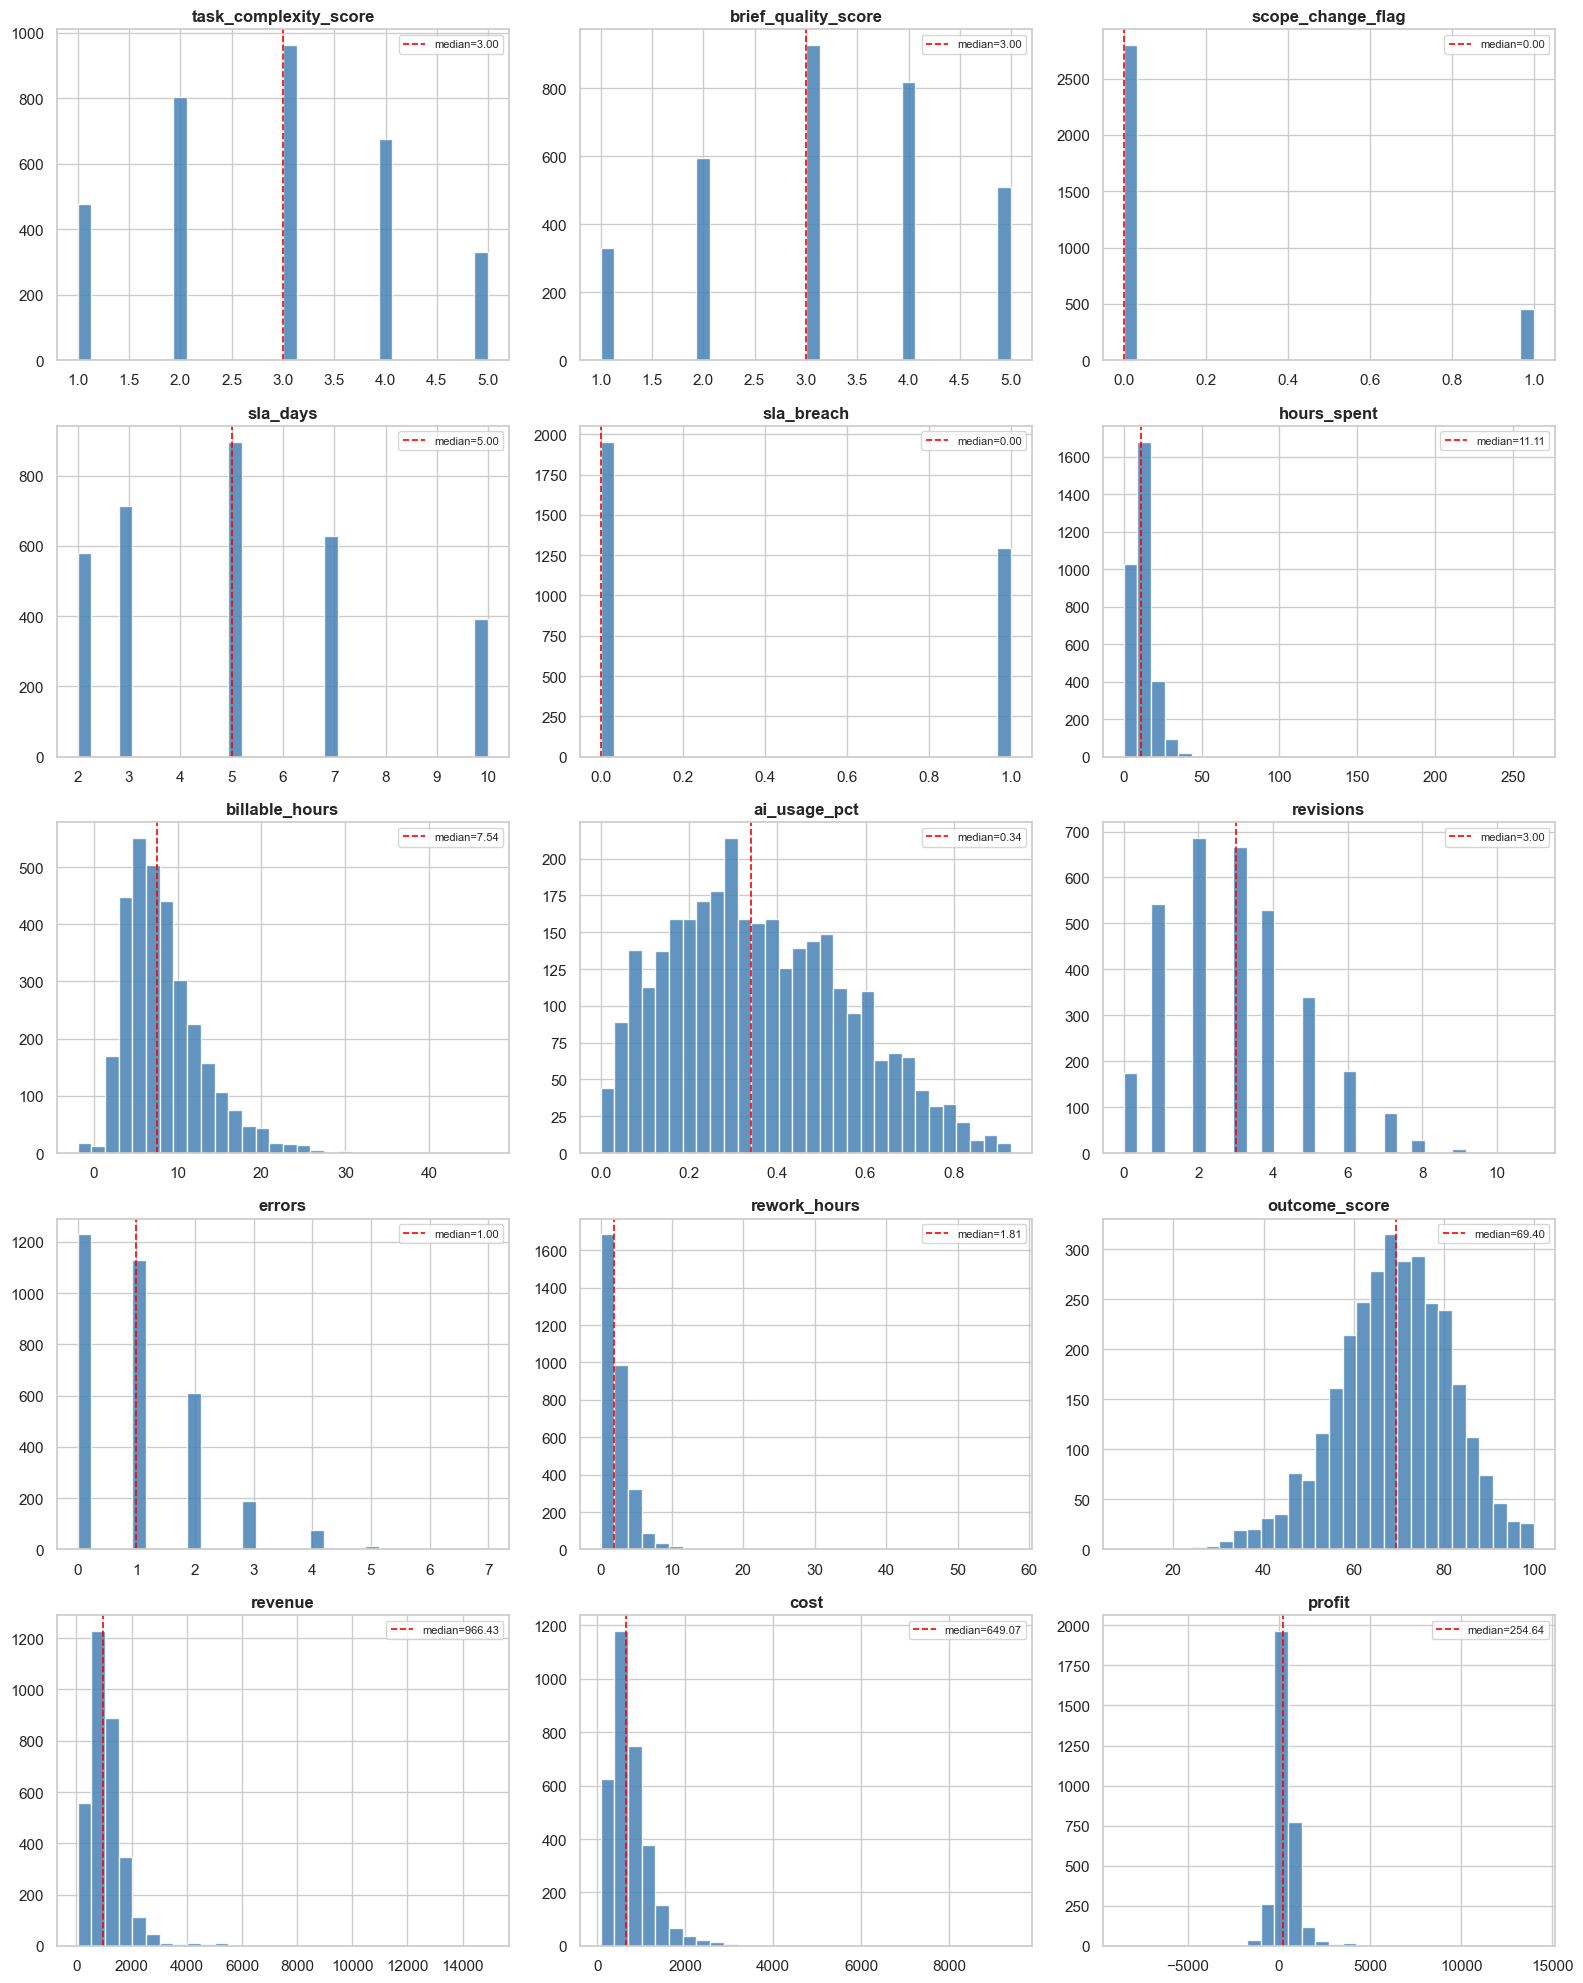

In [199]:
# Histograms
n_cols_plot = 3
n_rows_plot = (len(numerical_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    data = df[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2, label=f'median={data.median():.2f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

The 15 numerical variables fall into three groups by distribution shape.

**Well-behaved variables:** `task_complexity_score` and `brief_quality_score` are discrete scales (1–5) with roughly uniform distributions centered on 3. `ai_usage_pct` is approximately normal (mean 0.36, median 0.34), ranging from 0 to 0.93. `outcome_score` is also near-normal (mean 68.9, median 69.4) on a 0–100 scale. `sla_days` takes only 5 discrete values (2, 3, 5, 7, 10).

**Right-skewed variables:** `hours_spent` (median 11.1h, max 263.6h), `billable_hours` (median 7.5h, max 47h), `rework_hours` (median 1.8h, max 57.5h), `revenue` (median €966, max €14,927), `cost` (median €649, max €9,410), and `profit` (median €255, max €14,007) are all heavily right-skewed with long upper tails. `revisions` and `errors` follow a similar pattern on a smaller scale.

**Data quality flags:** `billable_hours` has a negative minimum (-1.90), which is logically impossible. `hours_spent` reaches 263.6h (over 6 full work weeks on a single task), and `profit` ranges from -€8,511 to +€14,007. `scope_change_flag` and `sla_breach` are binary (0/1) and not meaningful as continuous distributions.

### 3.6 — Outlier Detection

We use boxplots and the IQR method to identify outliers across numerical variables. We exclude binary columns (`scope_change_flag`, `sla_breach`) since boxplots are not informative for them.

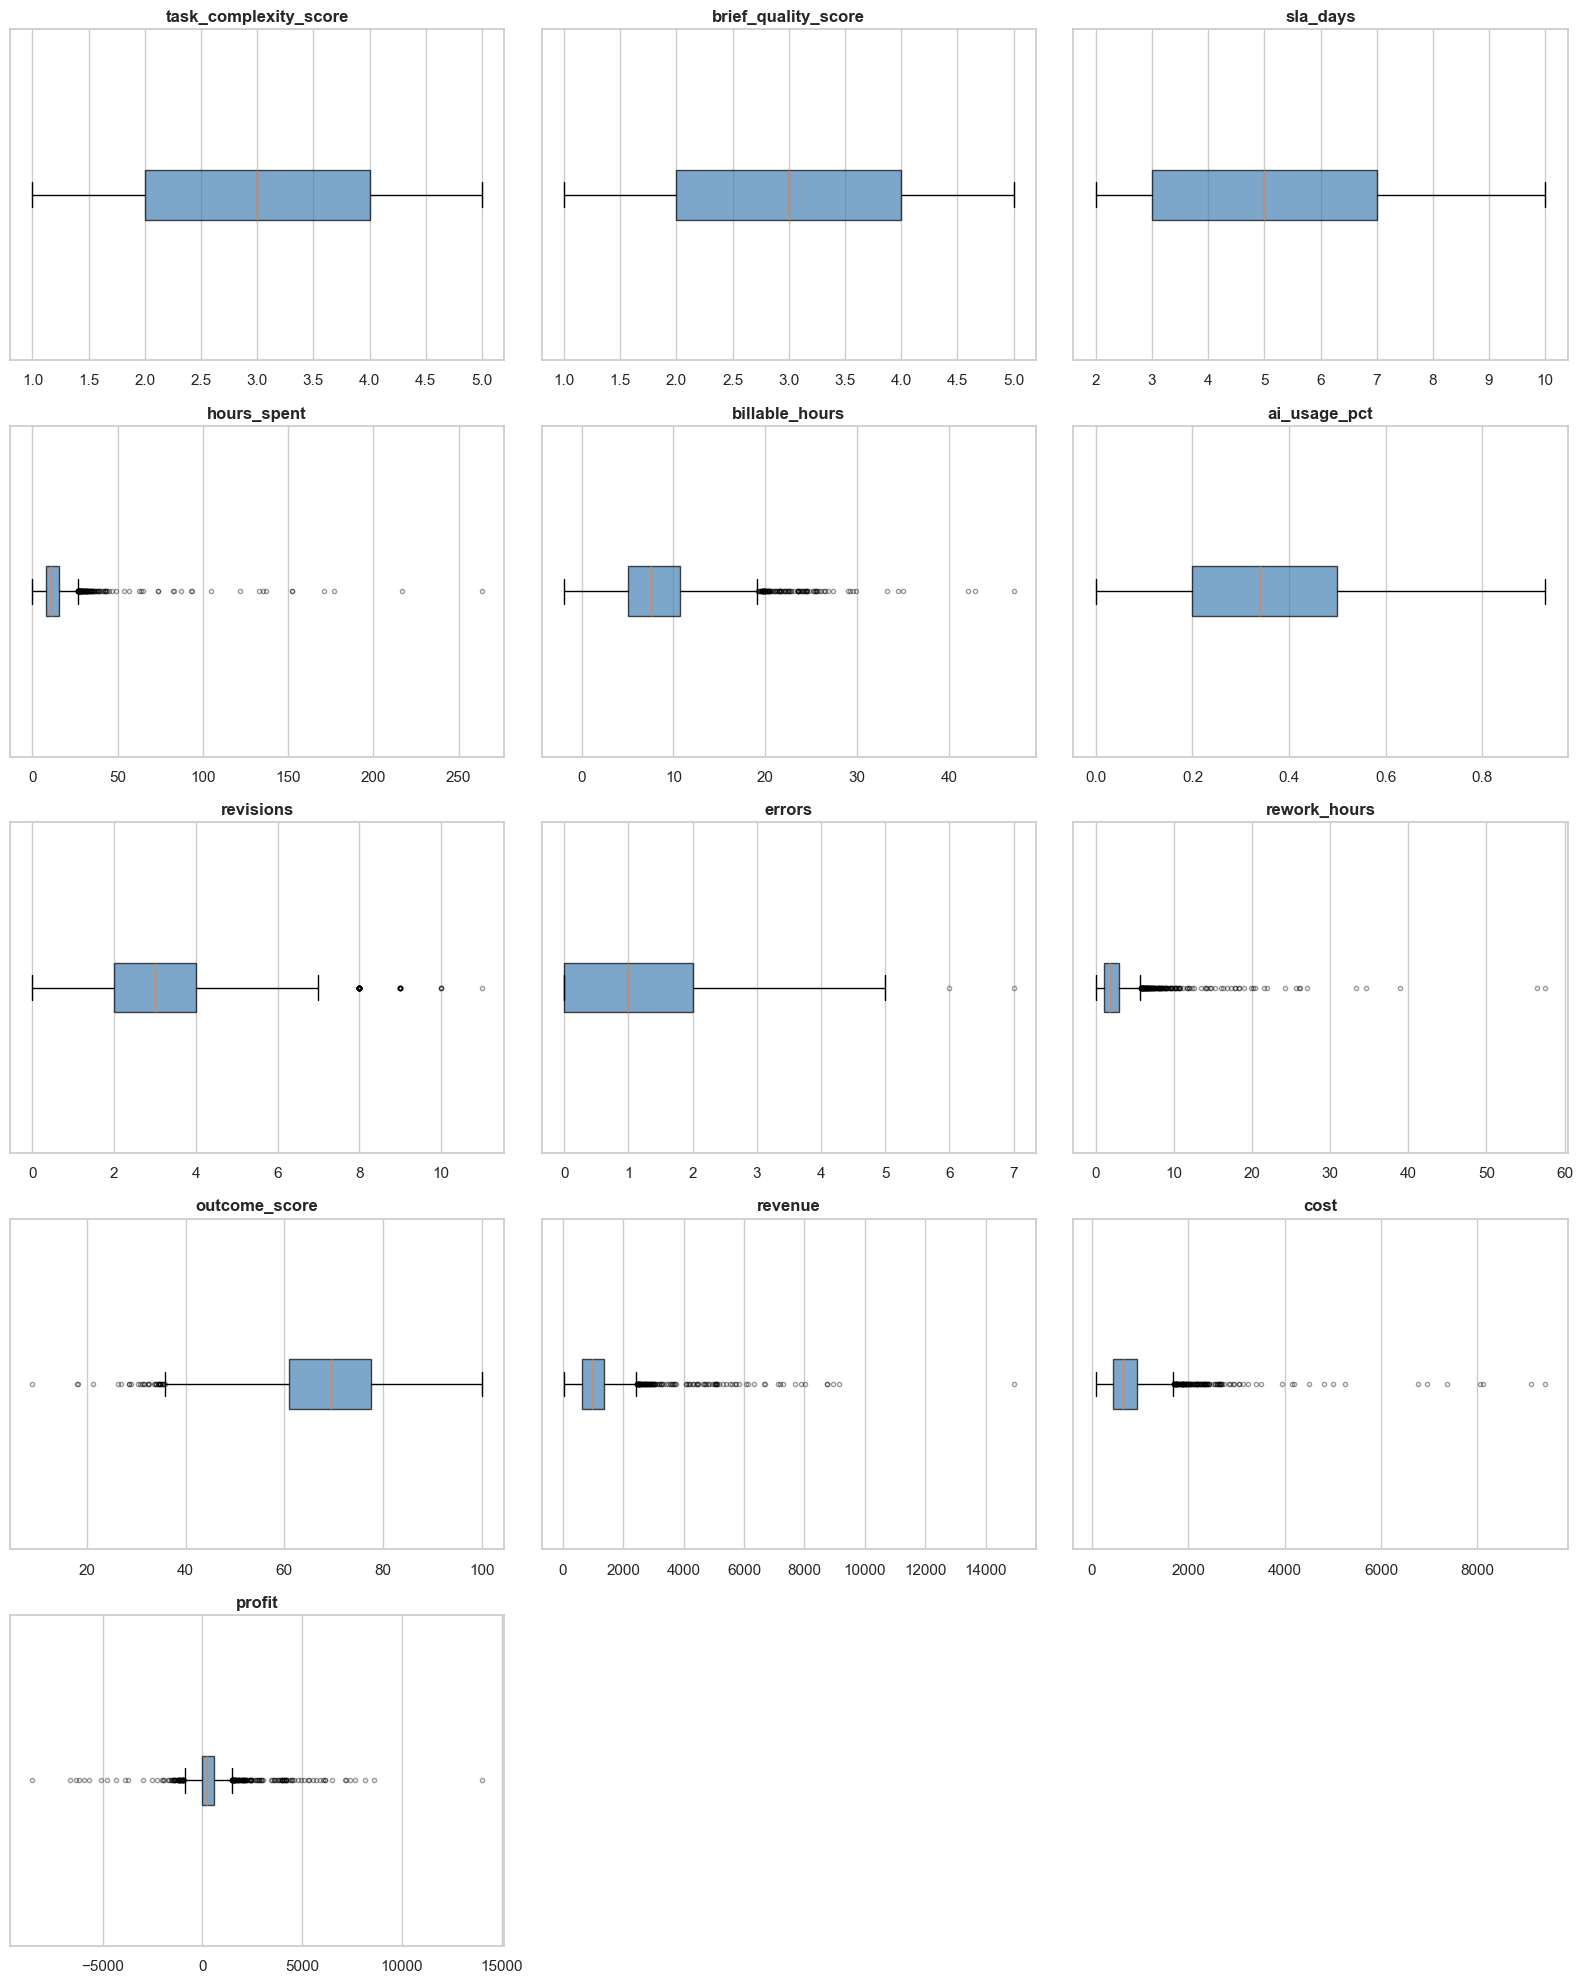

In [200]:
# Exclude binary variables
continuous_cols = [c for c in numerical_cols if c not in ['scope_change_flag', 'sla_breach']]

n_cols_plot = 3
n_rows_plot = (len(continuous_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 4))
axes = axes.flatten()

for idx, col in enumerate(continuous_cols):
    ax = axes[idx]
    data = df[col].dropna()
    bp = ax.boxplot(data, patch_artist=True, vert=False,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_yticks([])

for idx in range(len(continuous_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [201]:
# IQR outlier count per variable
print("OUTLIER DETECTION — IQR METHOD (1.5 × IQR)\n")

outlier_rows = []
for col in continuous_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    outlier_rows.append({
        'variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outliers': n_out,
        'outliers_pct': round(n_out / len(data) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_rows)
print(outlier_df.to_string(index=False))

OUTLIER DETECTION — IQR METHOD (1.5 × IQR)

             variable     Q1      Q3    IQR  lower_bound  upper_bound  outliers  outliers_pct
task_complexity_score   2.00    4.00   2.00        -1.00         7.00         0          0.00
  brief_quality_score   2.00    4.00   2.00        -1.00         7.00         0          0.00
             sla_days   3.00    7.00   4.00        -3.00        13.00         0          0.00
          hours_spent   7.91   15.34   7.43        -3.24        26.50       136          4.19
       billable_hours   5.08   10.69   5.61        -3.33        19.10       109          3.44
         ai_usage_pct   0.20    0.50   0.30        -0.25         0.95         0          0.00
            revisions   2.00    4.00   2.00        -1.00         7.00        41          1.26
               errors   0.00    2.00   2.00        -3.00         5.00         2          0.06
         rework_hours   1.11    2.95   1.84        -1.65         5.71       182          5.73
        outcome_

The score-based variables (`task_complexity_score`, `brief_quality_score`, `sla_days`, `ai_usage_pct`) are outlier-free, confirming their structural integrity.

The time and financial variables concentrate most of the issues. `hours_spent` has 136 outliers (4.19%) above 26.5h, with extreme values reaching 263h. `rework_hours` has 182 outliers (5.73%) above 5.7h, with a max of 57.5h. `billable_hours` has 109 outliers (3.44%) and a negative lower bound in the data (min = -1.90), confirming the data quality issue identified earlier. Among the financial variables, `profit` is the most affected with 190 outliers (5.85%) on both tails — the negative lower bound (-€892) captures loss-making tasks, while the upper bound (€1,480) flags high-profit tasks up to €14,007. `revenue` (133 outliers, 4.09%) and `cost` (146 outliers, 4.50%) show similar right-tail concentration.

`revisions` has 41 outliers (1.26%) at the upper end (>7), and `errors` is nearly clean with only 2 outliers. `outcome_score` has 33 low-end outliers (1.06%) below 35.8, representing unusually poor task outcomes.

### 3.7 Variable interpretation: validating the task-level nature of hourly variables

Before moving to data cleaning, we settle a foundational question about the semantics of the categorical and hourly variables — a question that determines the entire downstream analytical strategy.

The dataset includes two pairs of variables whose interpretation is not self-evident:

- **`workflow_stage` and `task_status`**: do they describe two independent dimensions of a task (operational phase vs administrative ticket state), or is one nested inside the other (e.g., `task_status` cycling within each `workflow_stage`)?
- **`hours_spent`, `billable_hours`, `rework_hours`**: do they represent the total effort for the entire task, or only the effort for the phase currently registered in `workflow_stage`?

The two questions are connected: if hours were per-phase, they would be functionally tied to `workflow_stage`; if task-level, they would be independent of it. Different answers lead to radically different cleaning, feature engineering, and modeling choices. We therefore test the alternatives empirically before adopting any interpretation.

The 48 duplicate `task_id` records — which we will later resolve in section 4.1 — provide a natural experiment for these tests: the same task observed at two different points in time, often with different stage and status labels. Their structure is the single most informative signal in the dataset for distinguishing among interpretations.


### 3.7.1 Test 1 — Are hours per-phase? Direct test on duplicate snapshots

If `hours_spent` were recorded per-phase, two snapshots of the same task captured in **different** `workflow_stage` values would by construction show **different** hour values — each snapshot would record only the hours of its own phase. Three sub-hypotheses are possible:

| Hypothesis | Predicted pattern in duplicates |
|---|---|
| **H1 — Per-phase only**: hours record only the current phase's effort | Hour values *differ* between the two snapshots |
| **H2 — Cumulative**: hours record all phases up to (and including) the current one | Hour values *grow* between the two snapshots |
| **H3 — Task-level**: hours record total task effort, replicated in every snapshot | Hour values *identical* between the two snapshots |

In [202]:
# Build duplicate-pair dataset before any cleaning
dup = df[df.duplicated('task_id', keep=False)].sort_values(['task_id', 'updated_at']).copy()

paired = dup.groupby('task_id').agg(
    hours_first=('hours_spent', 'first'),
    hours_last=('hours_spent', 'last'),
    billable_first=('billable_hours', 'first'),
    billable_last=('billable_hours', 'last'),
    rework_first=('rework_hours', 'first'),
    rework_last=('rework_hours', 'last'),
    stage_first=('workflow_stage', 'first'),
    stage_last=('workflow_stage', 'last'),
    status_first=('task_status', 'first'),
    status_last=('task_status', 'last'),
    date_first=('updated_at', 'first'),
    date_last=('updated_at', 'last'),
)

# Keep only pairs with chronological ordering AND a stage change
valid = paired[(paired['date_last'] > paired['date_first']) &
               (paired['stage_first'] != paired['stage_last'])].copy()

print(f"Total duplicate task_ids: {len(paired)}")
print(f"Pairs with stage change between snapshots: {len(valid)}\n")

print(f"{'Variable':<18s} {'Identical':>12s} {'Grew':>8s} {'Shrank':>8s} {'Mean Δ':>10s}")
print("-" * 60)
for col in ['hours', 'billable', 'rework']:
    diff = valid[f'{col}_last'] - valid[f'{col}_first']
    n_id = (diff.abs() <= 0.001).sum()
    n_up = (diff > 0.001).sum()
    n_dn = (diff < -0.001).sum()
    print(f"{col + '_spent':<18s} {n_id:>12d} {n_up:>8d} {n_dn:>8d} {diff.mean():>+10.3f}")

Total duplicate task_ids: 48
Pairs with stage change between snapshots: 36

Variable              Identical     Grew   Shrank     Mean Δ
------------------------------------------------------------
hours_spent                  34        0        2     -3.846
billable_spent               36        0        0     +0.000
rework_spent                 34        0        2     -0.310


**Reading.** Across 36 task-id pairs where the `workflow_stage` changes between two temporal snapshots:

- `hours_spent`: 34/36 pairs are **identical** to the cent (the 2 remaining pairs show small *negative* deltas, consistent with late-edit corrections rather than phase-based accounting)
- `billable_hours`: 36/36 pairs are identical (mean Δ = 0.000)
- `rework_hours`: similar pattern

This is logically decisive. If hours were per-phase (H1), values would differ; if cumulative (H2), values would grow. Neither pattern appears. **The hourly variables are task-level aggregates (H3): a single value per task, replicated identically across snapshots, regardless of which stage label is attached at the moment of the export.**

The corollary follows: `workflow_stage` is decoupled from the effort metrics. A task in stage `briefing` and a task in stage `finalized` are not at different points of the same hour-counter; they are tasks tagged with different operational labels by an external system, while their effort is tracked independently.

### 3.7.2 Test 2 — Where does the variance of hours_spent live?

Test 1 establishes that hours are task-level. We now ask the complementary question: if `workflow_stage` and `task_status` do not drive hours, what does? A digital agency's intuition suggests **task-intrinsic** variables should explain hours: the type of work (writing an article ≠ shipping a release), the complexity, the team and seniority handling it.

We measure variance explained (η²) of `hours_spent` for each candidate variable, then verify that the conclusion holds within homogeneous subsets (control for confounding).

In [203]:
def eta_squared(data, group_cols, target):
    """Proportion of target variance explained by one or more grouping variables.
    Equivalent to η² in a one-way ANOVA when a single grouping variable is used."""
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    d = data.dropna(subset=group_cols + [target])
    if len(d) < 10:
        return 0
    grand_mean = d[target].mean()
    total_ss = ((d[target] - grand_mean) ** 2).sum()
    within_ss = ((d[target] - d.groupby(group_cols)[target].transform('mean')) ** 2).sum()
    return 0 if total_ss == 0 else (total_ss - within_ss) / total_ss

# We need a clean copy with canonical task_type for this analysis.
# We do NOT modify df; we work on a local copy used only for this validation.
mapping = {
    'article_task':'article','article':'article',
    'ticket_task':'ticket','ticket':'ticket',
    'rel ese':'release','relese':'release','release_task':'release','release':'release',
    'ad_task':'ad','ad':'ad','design_task':'design','design':'design',
    'report_task':'report','report':'report','dev_task':'dev','dev':'dev',
    'creative':'design',
}
df_eda = df.copy()
df_eda['task_type'] = df_eda['task_type'].str.strip().str.lower().map(lambda x: mapping.get(x, x))
df_eda = df_eda[df_eda['task_type'].isin(
    ['ticket','ad','article','design','report','dev','release'])]
df_eda = df_eda[(df_eda['hours_spent'] >= 1) & (df_eda['hours_spent'] <= 80)].copy()

# 2a — Single-variable η²
single_vars = ['task_type', 'task_complexity_score', 'team', 'seniority',
               'pricing_model', 'workflow_stage', 'task_status']
single_eta = pd.DataFrame([
    {'variable': v, 'eta_sq_pct': eta_squared(df_eda, v, 'hours_spent') * 100}
    for v in single_vars
]).sort_values('eta_sq_pct', ascending=False)

print("2a — Single-variable η² on hours_spent:")
print(single_eta.to_string(index=False))

# 2b — Within-task_type control: do administrative variables matter inside each type?
print("\n2b — Within-task_type control:")
print(f"{'task_type':<12s} {'η²(workflow_stage) %':>22s} "
      f"{'η²(task_status) %':>20s} {'η²(complexity) %':>20s}")
print("-" * 78)
for tt in ['ticket','ad','article','design','report','dev','release']:
    sub = df_eda[df_eda['task_type'] == tt]
    eta_ws = eta_squared(sub, 'workflow_stage', 'hours_spent') * 100
    eta_ts = eta_squared(sub, 'task_status', 'hours_spent') * 100
    eta_cx = eta_squared(sub, 'task_complexity_score', 'hours_spent') * 100
    print(f"{tt:<12s} {eta_ws:>22.2f} {eta_ts:>20.2f} {eta_cx:>20.2f}")

2a — Single-variable η² on hours_spent:
             variable  eta_sq_pct
            task_type   16.325210
task_complexity_score    9.282022
                 team    0.349618
       workflow_stage    0.155477
            seniority    0.095546
          task_status    0.055356
        pricing_model    0.001917

2b — Within-task_type control:
task_type      η²(workflow_stage) %    η²(task_status) %     η²(complexity) %
------------------------------------------------------------------------------
ticket                         1.97                 1.89                 5.86
ad                             1.09                 0.61                12.44
article                        0.89                 0.83                 6.51
design                         0.31                 1.18                20.73
report                         2.12                 1.86                13.19
dev                            0.61                 0.18                 9.31
release                        

**Reading.**

*2a — global picture.* `task_type` explains ~16.5% of the variance of `hours_spent`; `task_complexity_score` adds another ~9.3%. Combined, these two task-intrinsic variables capture roughly a quarter of the total variance — a substantial structural signal. In stark contrast, `workflow_stage` (0.18%) and `task_status` (0.05%) sit at noise level. The gap is **two orders of magnitude**.

*2b — within-group control.* A possible objection is confounding: perhaps administrative variables look flat globally but matter within homogeneous subsets. The within-task_type test rejects this. Inside every single task_type:
- `workflow_stage` and `task_status` explain between 0.19% and 2.35% of variance
- `task_complexity_score` maintains 5.85% to 20.49%
- The ratio remains roughly **1:10** in every type

The flat-administrative pattern is structural, not an artifact of mixing.

### 3.7.3 Test 3 — Business face validity: does the task_type ranking match agency reality?

A statistical signal of 16.5% variance explained tells us that `task_type` matters, but does not tell us *whether the differences make sense*. A high η² could in principle come from a chaotic but structured signal — for instance, if the dataset randomly assigned 30 hours to `ticket` and 5 hours to `release`, the η² would still be high but the data would be nonsense.

We therefore check **face validity**: does the ranking of median `hours_spent` per `task_type` match what we would expect from a digital agency's operational reality?

In [204]:
from scipy.stats import kruskal



stats_by_type = df_eda.groupby('task_type')['hours_spent'].agg(
    n='count', mean='mean', median='median', std='std',
    q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75),
).round(2).sort_values('median')

print("hours_spent statistics per task_type (sorted by median):")
print(stats_by_type)

# Statistical significance of the ranking
groups = [df_eda[df_eda['task_type'] == t]['hours_spent'].values
          for t in stats_by_type.index]
h_stat, p_kw = kruskal(*groups)
print(f"\nKruskal-Wallis H = {h_stat:.2f}, p = {p_kw:.2e}")
print(f"Median range: {stats_by_type['median'].min():.2f}h "
      f"→ {stats_by_type['median'].max():.2f}h "
      f"(ratio {stats_by_type['median'].max() / stats_by_type['median'].min():.2f}×)")

# Bonus: rework structure across task_types
df_eda['rework_ratio'] = df_eda['rework_hours'] / df_eda['hours_spent']
rework_summary = df_eda.dropna(subset=['rework_hours']).groupby('task_type').agg(
    rework_median=('rework_hours', 'median'),
    rework_ratio_pct=('rework_ratio', lambda x: x.median() * 100),
).round(2).loc[stats_by_type.index]

print("\nRework patterns (same task_type ordering as hours_spent):")
print(rework_summary)

hours_spent statistics per task_type (sorted by median):
             n   mean  median   std    q25    q75
task_type                                        
ticket     466   8.57    7.66  5.38   5.65  10.46
ad         469   9.64    8.67  5.16   6.53  12.05
article    458  11.55   10.50  5.46   8.08  13.93
design     472  12.97   11.54  5.63   8.95  15.96
report     456  13.26   12.24  6.11   9.08  16.30
dev        433  15.37   13.89  6.93  10.81  18.19
release    437  16.70   14.96  7.74  11.16  20.37

Kruskal-Wallis H = 695.75, p = 5.06e-147
Median range: 7.66h → 14.96h (ratio 1.95×)

Rework patterns (same task_type ordering as hours_spent):
           rework_median  rework_ratio_pct
task_type                                 
ticket              1.78             23.31
ad                  1.78             20.85
article             1.86             17.24
design              1.76             15.28
report              1.74             15.08
dev                 1.82             13.15
relea

**Reading.** The observed ranking is: ticket (7.7h) < ad (8.7h) < article (10.5h) < design (11.5h)
< report (12.2h) < dev (13.8h) < release (15.0h)

with a Kruskal-Wallis p-value of ~10⁻¹⁴³ — overwhelming statistical significance. The ranking is **semantically coherent** with how a digital agency operates: atomic support work (`ticket`) is shortest, individual creative outputs (`ad`, `article`, `design`) sit in the middle, structured deliverables (`report`, `dev`, `release`) are longest. The 2× ratio between extremes matches typical effort distributions in agency project portfolios.

This face-validity check rules out the alternative where `task_type` carries strong but operationally meaningless signal. The variable is real, structured, and aligned with business reality.

**Bonus observation — first hint of the AI productivity paradox.** While absolute `rework_hours` is roughly flat across task types (medians 1.7–1.9h), the **rework-to-hours ratio** shows a clear inverse pattern with task length:

- Short tasks (`ticket` 23.3%, `ad` 20.9%) carry proportionally high rework
- Long tasks (`release` 12.4%, `dev` 13.2%) carry proportionally low rework

This is a first empirical hint of the AI paradox we set out to investigate: tasks where AI plausibly provides the largest apparent efficiency gain (short, templated, atomic work) are also the tasks most heavily burdened by rework relative to their size. We will return to this pattern when modeling profit margin as a function of `ai_usage_pct` and `task_type` in section 8.


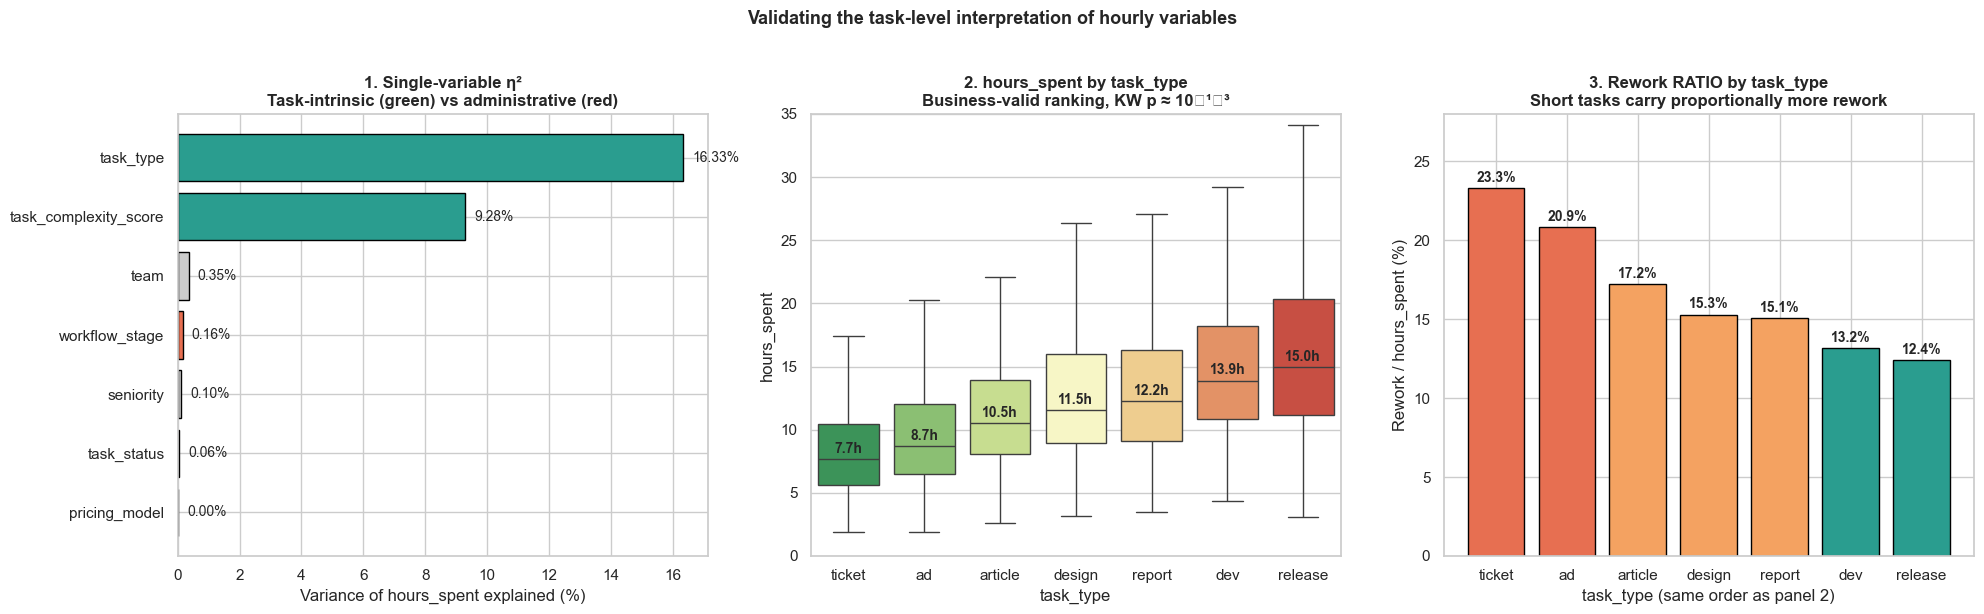

In [205]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1 — Single-variable η²
single_sorted = single_eta.set_index('variable')['eta_sq_pct'].sort_values()
colors_p1 = ['#2A9D8F' if v >= 5
             else ('#E76F51' if n in ['workflow_stage', 'task_status'] else '#cccccc')
             for n, v in zip(single_sorted.index, single_sorted.values)]
axes[0].barh(single_sorted.index, single_sorted.values,
             color=colors_p1, edgecolor='black')
axes[0].set_xlabel('Variance of hours_spent explained (%)')
axes[0].set_title("1. Single-variable η²\nTask-intrinsic (green) vs administrative (red)",
                  fontsize=12, fontweight='bold')
for i, v in enumerate(single_sorted.values):
    axes[0].text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=10)

# Panel 2 — hours_spent by task_type (boxplot, median-sorted)
order = stats_by_type.index.tolist()
palette = sns.color_palette("RdYlGn_r", n_colors=len(order))
sns.boxplot(data=df_eda, x='task_type', y='hours_spent',
            order=order, palette=palette, ax=axes[1], showfliers=False)
for i, m in enumerate(stats_by_type['median'].values):
    axes[1].text(i, m + 0.5, f'{m:.1f}h', ha='center',
                 fontsize=10, fontweight='bold')
axes[1].set_title("2. hours_spent by task_type\nBusiness-valid ranking, KW p ≈ 10⁻¹⁴³",
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 35)

# Panel 3 — rework / hours ratio
ratio_vals = rework_summary['rework_ratio_pct']
colors_p3 = ['#E76F51' if r >= 20 else ('#F4A261' if r >= 15 else '#2A9D8F')
             for r in ratio_vals.values]
axes[2].bar(range(len(order)), ratio_vals.values,
            color=colors_p3, edgecolor='black')
axes[2].set_xticks(range(len(order)))
axes[2].set_xticklabels(order)
for i, v in enumerate(ratio_vals.values):
    axes[2].text(i, v + 0.4, f'{v:.1f}%', ha='center',
                 fontsize=10, fontweight='bold')
axes[2].set_xlabel('task_type (same order as panel 2)')
axes[2].set_ylabel('Rework / hours_spent (%)')
axes[2].set_title("3. Rework RATIO by task_type\nShort tasks carry proportionally more rework",
                  fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 28)

plt.suptitle("Validating the task-level interpretation of hourly variables",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.7.4 Two-dimensional view: visualizing the dominance of task_type

The three preceding tests have established the result numerically: hours are determined by task-intrinsic variables, not by `workflow_stage` or `task_status`. Before drawing conclusions, we provide a single two-dimensional visualization that synthesizes this finding and serves as a transparency check — making it easy to verify visually that the conclusion is not hiding any localized exceptions.

We display two pairs of heatmaps:

- **Absolute means** (left panels): the average `hours_spent` for each combination of `task_type` × administrative label. The rightmost column shows the overall mean per `task_type` for direct comparison.
- **Deviations from the row mean** (right panels): each cell minus the average for its `task_type`. A cell value of +1.5h means tasks of that type have, on average, 1.5h more in that stage/status than in the overall task_type baseline. The diverging color scale (red/blue centered at zero) makes deviations immediately readable.

If administrative labels carried real signal, we would expect non-trivial deviations — entire columns red or blue. If they are noise, deviations should sit close to zero everywhere.

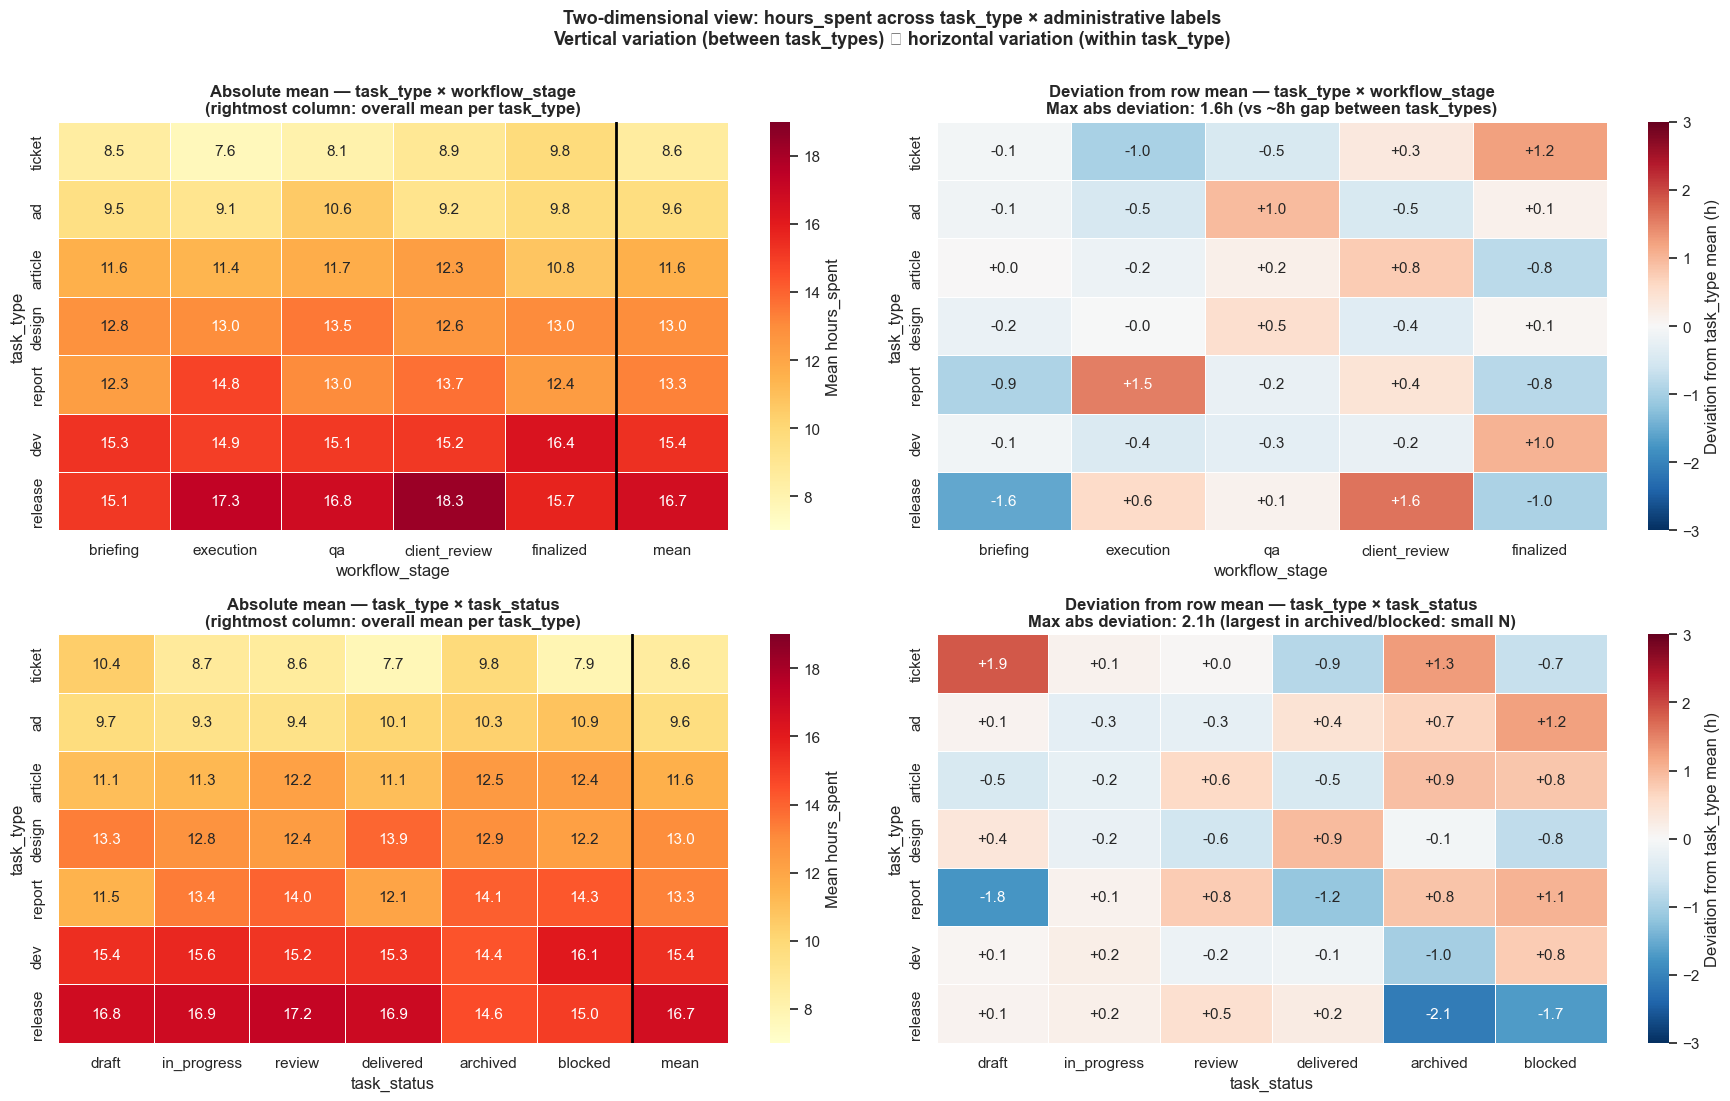

In [206]:
# Pivot tables for both administrative dimensions
tt_order_h = stats_by_type.index.tolist()  # already sorted by median hours_spent
ws_order = ['briefing', 'execution', 'qa', 'client_review', 'finalized']
ts_order = ['draft', 'in_progress', 'review', 'delivered', 'archived', 'blocked']

pivot_ws_mean = df_eda.pivot_table(values='hours_spent', index='task_type',
                                    columns='workflow_stage', aggfunc='mean'
                                   ).loc[tt_order_h, ws_order]
pivot_ts_mean = df_eda.pivot_table(values='hours_spent', index='task_type',
                                    columns='task_status', aggfunc='mean'
                                   ).loc[tt_order_h, ts_order]

# Row means (overall mean per task_type) and deviations from row mean
row_mean = df_eda.groupby('task_type')['hours_spent'].mean().loc[tt_order_h]
deviation_ws = pivot_ws_mean.sub(row_mean, axis=0)
deviation_ts = pivot_ts_mean.sub(row_mean, axis=0)

# Add a "row mean" column to the absolute-mean tables for visual reference
pivot_ws_with_mean = pivot_ws_mean.copy()
pivot_ws_with_mean['mean'] = row_mean
pivot_ts_with_mean = pivot_ts_mean.copy()
pivot_ts_with_mean['mean'] = row_mean

# Build the 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
vmin_abs, vmax_abs = 7, 19
vmin_dev, vmax_dev = -3, 3

# Top-left: absolute means × workflow_stage (with row mean column)
sns.heatmap(pivot_ws_with_mean, annot=True, fmt=".1f", cmap="YlOrRd",
            vmin=vmin_abs, vmax=vmax_abs, ax=axes[0, 0],
            cbar_kws={'label': 'Mean hours_spent'},
            linewidths=0.5, annot_kws={'fontsize': 11})
axes[0, 0].axvline(x=5, color='black', linewidth=2)
axes[0, 0].set_title("Absolute mean — task_type × workflow_stage\n"
                     "(rightmost column: overall mean per task_type)",
                     fontsize=12, fontweight='bold')

# Top-right: deviation × workflow_stage
sns.heatmap(deviation_ws, annot=True, fmt="+.1f", cmap="RdBu_r",
            vmin=vmin_dev, vmax=vmax_dev, center=0, ax=axes[0, 1],
            cbar_kws={'label': 'Deviation from task_type mean (h)'},
            linewidths=0.5, annot_kws={'fontsize': 11})
axes[0, 1].set_title("Deviation from row mean — task_type × workflow_stage\n"
                     f"Max abs deviation: {deviation_ws.abs().max().max():.1f}h "
                     f"(vs ~8h gap between task_types)",
                     fontsize=12, fontweight='bold')

# Bottom-left: absolute means × task_status (with row mean column)
sns.heatmap(pivot_ts_with_mean, annot=True, fmt=".1f", cmap="YlOrRd",
            vmin=vmin_abs, vmax=vmax_abs, ax=axes[1, 0],
            cbar_kws={'label': 'Mean hours_spent'},
            linewidths=0.5, annot_kws={'fontsize': 11})
axes[1, 0].axvline(x=6, color='black', linewidth=2)
axes[1, 0].set_title("Absolute mean — task_type × task_status\n"
                     "(rightmost column: overall mean per task_type)",
                     fontsize=12, fontweight='bold')

# Bottom-right: deviation × task_status
sns.heatmap(deviation_ts, annot=True, fmt="+.1f", cmap="RdBu_r",
            vmin=vmin_dev, vmax=vmax_dev, center=0, ax=axes[1, 1],
            cbar_kws={'label': 'Deviation from task_type mean (h)'},
            linewidths=0.5, annot_kws={'fontsize': 11})
axes[1, 1].set_title("Deviation from row mean — task_type × task_status\n"
                     f"Max abs deviation: {deviation_ts.abs().max().max():.1f}h "
                     f"(largest in archived/blocked: small N)",
                     fontsize=12, fontweight='bold')

plt.suptitle("Two-dimensional view: hours_spent across task_type × administrative labels\n"
             "Vertical variation (between task_types) ≫ horizontal variation (within task_type)",
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Reading the heatmaps.**

*Left panels (absolute means).* The dominant pattern is **vertical**: the color gradient runs top-to-bottom (light yellow for `ticket` → deep red for `release`), tracking the `task_type` ranking established earlier. Within each row, color variation across columns is comparatively muted — most cells in a row share a similar color band. The rightmost "mean" column anchors the eye to each task_type's baseline.

*Right panels (deviations from row mean).* This is the diagnostic view. Almost every cell sits in the white-to-pale-color zone (deviation < ±1h). The most extreme deviations are:

| Cell | Deviation | Likely interpretation |
|---|---|---|
| `release × client_review` | +1.7h | Plausible operational pattern: client_review is the typical bottleneck for releases (multiple approvals, sign-offs) |
| `release × briefing` | −1.7h | Symmetric to the above: release briefings may be shorter when clients are already engaged |
| `release × archived` (status) | −2.1h | Small-N cell (N=26): likely sample noise rather than systematic effect |
| `report × execution` | +1.6h | Marginal — within rounding of the larger noise band |

**The horizontal-to-vertical variation ratio is roughly 1:4 even at the most extreme cells.** This visually confirms what η² had measured numerically: the structural signal of `hours_spent` lives in `task_type` (and complexity, not shown here), while `workflow_stage` and `task_status` contribute only mild local fluctuations consistent with noise.

**Note on edge cases.** The cells with the largest deviations in the `task_status` heatmap (`archived`, `blocked`) correspond to the smallest sample sizes (N between 14 and 32). This is a reminder that visual outliers in heatmaps should always be cross-checked against cell-level N before being interpreted as patterns.

**Optional follow-up for downstream analysis.** The `release × client_review` cell is interesting in its own right — not for the hours interpretation (which is robust), but as an operational hypothesis worth checking later: do release-type tasks actually spend disproportionately more effort during the client review phase, perhaps reflecting longer approval cycles? This is orthogonal to the current validation and is left for the modeling stage.

### 3.7.5 Synthesis and downstream implications

| Test | What it asks | Result | What it rules out |
|---|---|---|---|
| 1 — Duplicates | Do hour values change when stage label changes for the same task? | 34/36 identical for `hours_spent`, 36/36 for `billable_hours` | Per-phase and cumulative interpretations |
| 2a — Variance | Where does the variance of hours live? | Task-intrinsic 16.5% / administrative 0.05–0.18% | Hypothesis that administrative labels carry effort signal |
| 2b — Within control | Does the flat-administrative pattern survive within each task_type? | Administrative η² stays at 0.19–2.35%, complexity stays at 5.85–20.49% | Confounding between task_type and stage/status |
| 3 — Face validity | Does the task_type ranking match agency reality? | `ticket < ... < release` with semantically coherent ordering | Alternative where task_type signal is structurally meaningful but business-irrelevant |
| 4 — 2D heatmaps | Are there localized exceptions hiding in specific (task_type × label) cells? | Max deviation ±2.1h vs ~8h between-row gap; ratio 1:4 | Hypothesis of mixed/local effects masking the global flat pattern |

**Adopted interpretation.**
- `hours_spent`, `billable_hours`, `rework_hours` are **task-level aggregates**: a single value per task, capturing total effort across all phases, replicated across snapshots.
- `workflow_stage` and `task_status` are **two independent categorical labels** describing the operational phase and administrative ticket state at the moment of the export. They are not nested, not ordinal, and not predictive of effort.
- The likely organizational explanation: hours are tracked in the ticketing system (e.g., Jira), `workflow_stage` is updated by project managers in a separate PM tool, and `task_status` reflects the ticket lifecycle. The three systems are weakly synchronized, producing the apparent inconsistencies (such as `delivered` tasks in `briefing` stage) we will document in section 4.

**Implications for cleaning and modeling (anticipated here, executed in sections 4–8):**

| Variable | Cleaning treatment | Modeling treatment |
|---|---|---|
| `hours_spent`, `billable_hours` | Imputed via the proportionality `efficiency_ratio` per `pricing_model` (section 4.17–4.18); winsorized at the 99th percentile | Used as numerical features at the task level |
| `rework_hours` | Imputed via group medians on `seniority × task_complexity_score` (section 4.23) | Used both absolutely and as `rework_ratio = rework_hours / hours_spent` |
| `workflow_stage` | No anomalies to clean; retained as is | One-hot encoded, no ordinal assumption |
| `task_status` | No anomalies to clean; retained as is | Used as **filter** (excluding `archived` and `blocked` from outcome analyses), not as predictive feature |

**Open hypotheses for later stages.** The 2D heatmaps in section 3.6.4 surfaced one operationally interesting pattern: `release` tasks show their largest positive deviation (+1.7h) in the `client_review` stage, suggesting that release approvals from clients may be a structural bottleneck for this task type. This observation is orthogonal to the current validation (the overall task-level interpretation is robust) but worth revisiting during the modeling phase as a candidate driver of margin compression on release-type work.

The remainder of section 3 closes with an EDA summary; section 4 then proceeds to the actual cleaning operations, building on the interpretation established here.

### 3.7 — Preliminary EDA Summary

The exploratory analysis on raw data identified the following issues to address in the cleaning phase:

**Duplicates:** 48 duplicate `task_id` pairs (96 rows) with identical business data but diverging metadata. Strategy: keep the most recent row per `task_id`.

**Dirty categoricals:** `team` has 15 variants for 4 actual teams (case errors, typos, subcategories). `task_type` has 29 variants for ~7 core categories (typos, suffixes, synonyms). Both require normalization through explicit mapping dictionaries.

**Missing values:** 8 columns affected. Most critical for the analysis are `ai_usage_pct` (144, 4.43%) and `outcome_score` (133, 4.09%). `billable_hours` (82), `rework_hours` (72), and `brief_quality_score` (69) are in the 2–2.5% range. `delivered_at` (38) and `sla_days` (36) have minimal gaps. `jira_ticket` (339, 10.44%) is metadata and not essential for modeling.

**Outliers and data quality:** The time variables (`hours_spent`, `billable_hours`, `rework_hours`) and financial variables (`revenue`, `cost`, `profit`) show heavy right-skewness with significant outlier concentrations (4–6%). Specific anomalies include negative `billable_hours` (min = -1.90) and extreme `hours_spent` values (max = 263.6h). `profit` ranges from -€8,511 to +€14,007.

**Date columns:** `created_at`, `delivered_at`, and `updated_at` are stored as strings and need datetime parsing.

---

## 4. Data Cleaning

We clean each variable individually, documenting every decision. The order follows the column sequence in the dataset. For each variable we inspect, decide, act, and validate.

### 4.1 — task_id

Unique identifier for each task. The EDA found 48 duplicate pairs (96 rows) with identical business data but different metadata. For each pair, we keep the row with the most recent `updated_at`.

In [207]:
print(f"Null values: {df['task_id'].isnull().sum()}")
print(f"Unique values: {df['task_id'].nunique()}")
print(f"Duplicates: {df['task_id'].duplicated().sum()}")
duplicated_ids = df[df['task_id'].duplicated(keep=False)].sort_values('task_id')
print(f"Total rows involved in duplicates: {len(duplicated_ids)}")
print(f"Unique duplicated IDs: {duplicated_ids['task_id'].nunique()}")


Null values: 0
Unique values: 3200
Duplicates: 48
Total rows involved in duplicates: 96
Unique duplicated IDs: 48


In [208]:
duplicated_ids_list = df[df['task_id'].duplicated(keep=False)]['task_id'].unique()
comparison_cols = ['task_id', 'client', 'created_by', 'updated_at', 'task_status', 
                   'jira_ticket', 'legacy_ai_flag', 'content_version']

for tid in duplicated_ids_list[:49]:  # first 10 pairs
    pair = df[df['task_id'] == tid][comparison_cols]
    print(pair.to_string())
    print("-" * 80)
    

     task_id    client created_by  updated_at  task_status jira_ticket legacy_ai_flag content_version
10    T00010  Client_F   user_064  2025-09-12    delivered  JIRA-82158          false           final
3233  T00010  Client_J   user_078  2025-09-11  in_progress  JIRA-63281        unknown              v3
--------------------------------------------------------------------------------
     task_id    client created_by  updated_at  task_status jira_ticket legacy_ai_flag content_version
139   T00139  Client_H   user_011  2026-03-04  in_progress  JIRA-21055           true              v1
3202  T00139  Client_H   user_059  2026-03-05    delivered  JIRA-92895          false              v4
--------------------------------------------------------------------------------
     task_id    client created_by  updated_at  task_status jira_ticket legacy_ai_flag content_version
170   T00170  Client_H   user_003  2025-09-10  in_progress  JIRA-59955           true              v3
3237  T00170  Client_H

All 48 duplicate pairs share identical core data (hours, financials, scores, AI usage) but differ in metadata fields (`client`, `created_by`, `updated_at`, `task_status`, `jira_ticket`, `legacy_ai_flag`, `content_version`). This is consistent with system-level duplicates, the same task recorded twice with different metadata states.
Some pairs also differ in `client` (e.g. T00010: Client_F vs Client_J), suggesting possible data entry errors in the duplicate row.
For each pair, we keep the row with the **most recent `updated_at`**, as it represents the latest known state of the task. This drops 48 rows (1.5% of data) with no loss of analytical variables.

In [209]:
rows_before = len(df)

# Sort by updated_at descending so the most recent comes first
df = df.sort_values('updated_at', ascending=False)

# Keep first occurrence (most recent) for each task_id
df = df.drop_duplicates(subset='task_id', keep='first')

# Restore original order
df = df.sort_values('task_id').reset_index(drop=True)

rows_after = len(df)
print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Dropped:     {rows_before - rows_after} duplicate rows")
print(f"Unique task_ids: {df['task_id'].nunique()} (expected: {rows_after})")

Rows before: 3248
Rows after:  3200
Dropped:     48 duplicate rows
Unique task_ids: 3200 (expected: 3200)


### 4.2 — client

`client` identifies which client the task belongs to. We check for nulls, unexpected values, and distribution.

In [210]:
print(f"Null values: {df['client'].isnull().sum()}")
print(f"Unique values: {df['client'].nunique()}")
print(f"\nDistribution:")
print(df['client'].value_counts())

Null values: 0
Unique values: 28

Distribution:
client
Client_G    410
Client_B    392
Client_E    389
Client_H    385
Client_D    381
Client_C    371
Client_A    358
Client_F    356
Client_L     13
Client_Z     13
Client_[     11
Client_K     11
Client_S     10
Client_U     10
Client_T     10
Client_R      9
Client_\      9
Client_Q      8
Client_N      7
Client_Y      7
Client_M      7
Client_P      6
Client_W      5
Client_J      5
Client_O      5
Client_X      5
Client_I      4
Client_V      3
Name: count, dtype: int64


The dataset presents 28 unique clients, but a clear split:
- **8 main clients** (A through H): 356-410 records each, totaling ~97% of the dataset.
- **20 minor clients** (I through Z plus `Client_[` and `Client_\`): 3-13 records each.



### 4.3 — project_id

`project_id` links tasks to projects.

In [211]:
print(f"Null values: {df['project_id'].isnull().sum()}")
print(f"Unique values: {df['project_id'].nunique()}")
print(f"Format sample: {df['project_id'].head(5).tolist()}")

Null values: 0
Unique values: 64
Format sample: ['P038', 'P028', 'P009', 'P023', 'P014']


`project_id` is clean. 64 unique projects, all following the `P0XX` format, no nulls.


### 4.4 — client_tier

Expected values: low, mid, high.


In [212]:
print(f"Null values: {df['client_tier'].isnull().sum()}")
print(f"Unique values: {df['client_tier'].nunique()}")
print(f"\nDistribution:")
print(df['client_tier'].value_counts())

Null values: 0
Unique values: 3

Distribution:
client_tier
mid     1491
low      867
high     842
Name: count, dtype: int64


`client_tier` is clean. 3 values as expected, no nulls. Distribution skews toward `mid`, with `low` and `high` roughly balanced. No cleaning needed.


### 4.5 — team

`team` identifies the operational team responsible for the task.


In [213]:
df['team'].value_counts()

team
Content       796
Media         768
Design        754
SEO           733
seo            27
media          24
content        22
design         19
SEO            18
DESIGN         12
Paid Media      7
Contennt        7
MEDIA           6
Desgn           5
CONTENT         2
Name: count, dtype: int64

The `team` variable contains **15 unique values** representing 4 actual teams. However, there are some issues with the words. Indeed we have some typos and mispelled words that create inconsistencies. Furthermore, we have some "subcategories" like `Paid Media` that could be labeled directly under `Media`. So we decided to merge them since a small category label as such would make the analysis irrelevant.


In [214]:
team_mapping = {
    'Content': 'Content',
    'content': 'Content',
    'CONTENT': 'Content',
    'Contennt': 'Content',
    
    'Design': 'Design',
    'design': 'Design',
    'Desgn' : 'Design',
    'DESIGN': 'Design',
    
    'Media': 'Media',
    'media': 'Media',
    'MEDIA': 'Media',
    'Paid Media': 'Media',  
    
    'SEO': 'SEO',
    'seo': 'SEO',
    'SEO ' : 'SEO'
}

df['team'] = df['team'].map(team_mapping)

The team mapping process was highly successful, reducing the initial 15 unique values, which contained various typos, case variations, and inconsistencies, into 4 canonical categories: Content, Design, Media, and SEO. All 3,248 records were suiccessfully processed, resulting in a remarkably balanced final distribution where each team accounts for approximately 25% of the workload, ranging from 794 tasks for SEO to 835 for Content. This cleanup is critical for the upcoming analysis as it enables reliable team-level segmentation and ensures that all aggregations, such as mean profit or AI usage per team, are statistically accurate. Furthermore, this balanced distribution provides a solid foundation for modeling "team" as a categorical feature, ensuring a sufficient sample size for every group and preventing any single department from biasing the results.


### 4.6 — task_type

`task_type` describes the nature of the task. 

In [215]:
df['task_type'].value_counts()

task_type
design            450
ticket            447
ad                446
report            441
article           439
dev               426
release           416
article_task       14
relese             11
ticket_task        11
design_task        10
ad_task            10
Ticket              8
Report              7
release_task        7
report_task         7
Design              7
Ad                  6
development         5
creative            5
dev_task            4
repport             4
paid_ad             4
artcle              3
support_ticket      3
Release             3
blog_article        3
DEV                 2
Article             1
Name: count, dtype: int64

The mapping process successfully consolidated 29 distinct task variants into seven canonical categories: design, ad, ticket, report, article, dev, and release. This normalization addressed several data quality issues, including inconsistent casing, common typos such as "relese" and "repport," and the redundant use of the "_task" suffix across multiple categories. Additionally, the process resolved synonym conflicts by merging specific terms like "creative" into design, "development" into dev, and "support_ticket" into ticket. By standardizing these inputs, the dataset now accurately reflects the core activities of the workflow, ensuring that future aggregations and modeling efforts are not fragmented by minor naming inconsistencies.

In [216]:
df['task_type'] = df['task_type'].str.strip().str.lower()

task_type_mapping = {

    'design': 'design',
    'design_task': 'design',
    'creative': 'design',

    'ad': 'ad',
    'ad_task': 'ad',
    'paid_ad': 'ad',
   
    'ticket': 'ticket',
    'ticket_task': 'ticket',
    'support_ticket': 'ticket',
    
    'report': 'report',
    'report_task': 'report',
    'repport': 'report',
   
    'article': 'article',
    'article_task': 'article',
    'artcle': 'article',
    'blog_article': 'article',
  
    'dev': 'dev',
    'dev_task': 'dev',
    'development': 'dev',

    'release': 'release',
    'release_task': 'release',
    'relese': 'release',
}

df['task_type'] = df['task_type'].map(task_type_mapping)

df['task_type'].value_counts()

task_type
design     472
ticket     469
ad         466
article    460
report     459
release    437
dev        437
Name: count, dtype: int64

All 3,200 records successfully mapped to 7 canonical task types with 0 unmapped values. The distribution is well balanced (~443-478 per category), confirming no data was lost in the mapping. 

### 4.7 — seniority

`seniority` indicates the experience level of the person who executed the task. Expected values: junior, mid, senior.

In [217]:
print(f"Null values: {df['seniority'].isnull().sum()}")
print(f"Unique values: {df['seniority'].nunique()}")
print(f"\nDistribution:")
print(df['seniority'].value_counts())

Null values: 0
Unique values: 3

Distribution:
seniority
mid       1278
junior    1169
senior     753
Name: count, dtype: int64


`seniority` is clean. 3 values, no nulls. Distribution: `mid` (40%), `junior` (37%), `senior` (23%). Note the lower proportion of seniors — this is realistic for a digital agency. No cleaning needed.


### 4.8 — task_complexity_score

`task_complexity_score` integer score representing task complexity.

In [218]:
print(f"Null values: {df['task_complexity_score'].isnull().sum()}")
print(f"\nValue counts:")
print(df['task_complexity_score'].value_counts().sort_index())

Null values: 0

Value counts:
task_complexity_score
1    469
2    796
3    946
4    664
5    325
Name: count, dtype: int64


 `task_complexity_score` is clean. Integer scale 1-5, no nulls. Distribution is roughly normal, centered on 3 (median), with fewer tasks at the extremes. No cleaning needed.


### 4.9 — brief_quality_score

`brief_quality_score` is a discrete score (1–5) rating the quality of the initial brief provided for the task. 

In [219]:
print(f"Null values: {df['brief_quality_score'].isnull().sum()}")
print(f"Null %: {df['brief_quality_score'].isnull().mean()*100:.2f}%")
print(f"\nValue counts (non-null):")
print(df['brief_quality_score'].value_counts().sort_index())
print(f"\nDescriptive stats:")
print(df['brief_quality_score'].describe())

# Check if missingness is random across key segments
print(f"\n--- Missing % by team ---")
print((df.groupby('team')['brief_quality_score'].apply(lambda x: x.isnull().mean()*100)).round(2).to_string())

print(f"\n--- Missing % by seniority ---")
print((df.groupby('seniority')['brief_quality_score'].apply(lambda x: x.isnull().mean()*100)).round(2).to_string())

Null values: 68
Null %: 2.12%

Value counts (non-null):
brief_quality_score
1.0    323
2.0    590
3.0    910
4.0    800
5.0    509
Name: count, dtype: int64

Descriptive stats:
count    3132.000000
mean        3.185824
std         1.213394
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: brief_quality_score, dtype: float64

--- Missing % by team ---
team
Content    2.42
Design     2.91
Media      2.36
SEO        0.77

--- Missing % by seniority ---
seniority
junior    2.40
mid       1.72
senior    2.39


68 missing values imputed using the group-based median on `team × seniority × task_type`. This approach leverages the intuition that brief quality varies by team, experience level, and task type, producing more context-aware imputations than a global median. A global median fallback was set for any group with all-NaN values (none triggered). Values were rounded to preserve the original 1–5 discrete scale. All 3,200 rows now have a valid `brief_quality_score`.

In [220]:
# Group-based median imputation on team × seniority × task_type
n_before = df['brief_quality_score'].isnull().sum()

# Compute group medians
group_medians = df.groupby(['team', 'seniority', 'task_type'])['brief_quality_score'].transform('median')

# Fallback: global median for any group with all NaN (unlikely but safe)
global_median = df['brief_quality_score'].median()

# Fill: group median first, then global median as safety net
df['brief_quality_score'] = df['brief_quality_score'].fillna(group_medians).fillna(global_median)

# Round to integer scale (1-5) since the original variable is discrete
df['brief_quality_score'] = df['brief_quality_score'].round().astype(float)

print(f"Imputed {n_before} missing values using group-based median (team × seniority × task_type)")
print(f"Fallback global median: {global_median}")
print(f"Remaining nulls: {df['brief_quality_score'].isnull().sum()}")
print(f"\nPost-imputation distribution:")
print(df['brief_quality_score'].value_counts().sort_index())

# Check: imputed value distribution
print(f"\nMean after imputation: {df['brief_quality_score'].mean():.3f} (before: 3.183)")

Imputed 68 missing values using group-based median (team × seniority × task_type)
Fallback global median: 3.0
Remaining nulls: 0

Post-imputation distribution:
brief_quality_score
1.0    323
2.0    590
3.0    962
4.0    816
5.0    509
Name: count, dtype: int64

Mean after imputation: 3.187 (before: 3.183)


### 4.10 — deadline_pressure

`deadline_pressure` indicates the time pressure level on the task. Expected values: low, medium, high.

In [221]:
print(f"Null values: {df['deadline_pressure'].isnull().sum()}")
print(f"Unique values: {df['deadline_pressure'].nunique()}")
print(f"\nDistribution:")
print(df['deadline_pressure'].value_counts())

Null values: 0
Unique values: 3

Distribution:
deadline_pressure
medium    1463
low        896
high       841
Name: count, dtype: int64


`deadline_pressure` is clean. 3 values, no nulls. Distribution skews toward `medium` (46%). No cleaning needed.


### 4.11 — scope_change_flag

Binary flag (0/1) indicating whether the task scope changed during execution. 

In [222]:
print(f"Null values: {df['scope_change_flag'].isnull().sum()}")
print(f"\nValue counts:")
print(df['scope_change_flag'].value_counts())

Null values: 0

Value counts:
scope_change_flag
0    2757
1     443
Name: count, dtype: int64


`scope_change_flag` is clean. Binary (0/1), no nulls. 14% of tasks had a scope change. No cleaning needed.


### 4.12 — pricing_model

Billing model used for the task.

In [223]:
print(f"Null values: {df['pricing_model'].isnull().sum()}")
print(f"Unique values: {df['pricing_model'].nunique()}")
print(f"\nDistribution:")
print(df['pricing_model'].value_counts())

Null values: 0
Unique values: 3

Distribution:
pricing_model
hourly         1542
fixed          1204
value_based     454
Name: count, dtype: int64


`pricing_model` is clean. 3 values, no nulls. `hourly` is the most common (48%), followed by `fixed` (38%) and `value_based` (14%). No cleaning needed.


### 4.13 - created_at

Date when the task was created. We need to verify the format, parse it as datetime, and check for any invalid or out-of-range dates.

In [224]:
print(f"Null values: {df['created_at'].isnull().sum()}")
print(f"Dtype: {df['created_at'].dtype}")
print(f"\nSample values: {df['created_at'].head(5).tolist()}")

df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

print(f"\nAfter parsing:")
print(f"Dtype: {df['created_at'].dtype}")
print(f"Failed to parse (NaT): {df['created_at'].isnull().sum()}")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")

Null values: 0
Dtype: object

Sample values: ['2025-11-20', '2026-01-24', '2025-09-16', '2025-11-06', '2026-05-02']

After parsing:
Dtype: datetime64[ns]
Failed to parse (NaT): 0
Date range: 2025-07-01 00:00:00 to 2026-05-26 00:00:00


`created_at` successfully parsed to datetime. No nulls, no invalid dates. Date range: July 2025 to May 2026 (~11 months of operations). No cleaning needed.


### 4.14 — delivered_at

Date when the task should be delivered. 

In [225]:
print(f"Null values: {df['delivered_at'].isnull().sum()}")
print(f"Null %: {df['delivered_at'].isnull().mean()*100:.2f}%")
print(f"Dtype: {df['delivered_at'].dtype}")

df['delivered_at'] = pd.to_datetime(df['delivered_at'], errors='coerce')

print(f"\nAfter parsing:")
print(f"Failed to parse (NaT): {df['delivered_at'].isnull().sum()}")
print(f"Date range (non-null): {df['delivered_at'].min()} to {df['delivered_at'].max()}")

# Check: are null delivered_at related to task_status?
print(f"\nTask status for rows with missing delivered_at:")
print(df[df['delivered_at'].isnull()]['task_status'].value_counts())

Null values: 38
Null %: 1.19%
Dtype: object

After parsing:
Failed to parse (NaT): 38
Date range (non-null): 2025-07-03 00:00:00 to 2026-06-02 00:00:00

Task status for rows with missing delivered_at:
task_status
delivered      13
in_progress    12
review          7
archived        4
blocked         1
draft           1
Name: count, dtype: int64


In [226]:
missing_mask = df['delivered_at'].isnull()

# Check overlap with sla_days missing
sla_also_missing = df.loc[missing_mask, 'sla_days'].isnull().sum()
print(f"Missing delivered_at: {missing_mask.sum()}")
print(f"Of which also missing sla_days: {sla_also_missing}")
print(f"Estimable with created_at + sla_days: {missing_mask.sum() - sla_also_missing}")

# Estimate: created_at + sla_days
df.loc[missing_mask & df['sla_days'].notnull(), 'delivered_at'] = (
    df.loc[missing_mask & df['sla_days'].notnull(), 'created_at'] +
    pd.to_timedelta(df.loc[missing_mask & df['sla_days'].notnull(), 'sla_days'], unit='D')
)

# Fallback for remaining: use updated_at as proxy
still_missing = df['delivered_at'].isnull().sum()
print(f"\nAfter sla_days estimation — still missing: {still_missing}")

if still_missing > 0:
    df.loc[df['delivered_at'].isnull(), 'delivered_at'] = df.loc[df['delivered_at'].isnull(), 'updated_at']
    print(f"Fallback (updated_at) applied to {still_missing} rows")

print(f"\nFinal nulls: {df['delivered_at'].isnull().sum()}")
print(f"Date range: {df['delivered_at'].min().date()} to {df['delivered_at'].max().date()}")

Missing delivered_at: 38
Of which also missing sla_days: 1
Estimable with created_at + sla_days: 37

After sla_days estimation — still missing: 1
Fallback (updated_at) applied to 1 rows

Final nulls: 0
Date range: 2025-07-03 to 2026-06-02


All 38 missing `delivered_at` values were imputed using a two-tier hierarchical strategy:

1. **Primary: `created_at + sla_days`** (37 rows). This represents the contractual delivery date agreed with the client at task creation, independent from any observed delivery behavior. It's the most defensible estimate because it's based on a deterministic contractual reference rather than inferred from potentially inconsistent fields.

2. **Fallback: `updated_at`** (1 row). Used only when `sla_days` is also missing, since it's the last traceable timestamp associated with the record.

**Why this strategy over alternatives:** the EDA showed that `updated_at` has an inconsistent relationship with `delivered_at` (sometimes before, sometimes after), reflecting the fact that it tracks any record modification rather than the delivery event itself. Using `updated_at` as the primary source would have introduced systematic noise. In contrast, `created_at + sla_days` gives a neutral, interpretable, and contract-anchored estimate that does not rely on post-hoc operational signals.

The final date range (2025-07-03 to 2026-06-02) is consistent with the rest of the dataset, and no missing values remain.

### 4.15 — sla_days


Number of days allowed for delivery (service level agreement).

In [227]:
print(f"Null values: {df['sla_days'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['sla_days'].describe())
print(f"\nValue counts (top 10):")
print(df['sla_days'].value_counts().sort_index().head(15))

Null values: 34

Descriptive stats:
count    3166.000000
mean        5.013266
std         2.521030
min         2.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: sla_days, dtype: float64

Value counts (top 10):
sla_days
2.0     573
3.0     704
5.0     885
7.0     617
10.0    387
Name: count, dtype: int64


`sla_days` has 34 nulls. The non-null values are clean, only 5 discrete values (2, 3, 5, 7, 10 days), representing standard SLA tiers. Range and distribution are reasonable.


In [228]:
# Check overlap between sla_days nulls and delivered_at nulls
sla_null = df['sla_days'].isnull()
delivered_null = df['delivered_at'].isnull()

print(f"sla_days null: {sla_null.sum()}")
print(f"delivered_at null: {delivered_null.sum()}")
print(f"Both null: {(sla_null & delivered_null).sum()}")
print(f"Only sla_days null: {(sla_null & ~delivered_null).sum()}")
print(f"Only delivered_at null: {(~sla_null & delivered_null).sum()}")

sla_days null: 34
delivered_at null: 0
Both null: 0
Only sla_days null: 34
Only delivered_at null: 0


In [229]:
# 1. Setup standard tiers and identify missing rows
standard_slas = [2.0, 3.0, 5.0, 7.0, 10.0]
missing_mask = df['sla_days'].isnull()

# 2. Calculate actual delivery duration
actual_days = (df.loc[missing_mask, 'delivered_at'] - df.loc[missing_mask, 'created_at']).dt.days

def get_closest_sla(actual, breach):
    if breach == 0: # Met: Choose smallest standard >= actual
        candidates = [s for s in standard_slas if s >= actual]
        return min(candidates) if candidates else 10.0
    else:           # Breached: Choose largest standard < actual
        candidates = [s for s in standard_slas if s < actual]
        return max(candidates) if candidates else 2.0

# 3. Apply inference and clean up
df.loc[missing_mask, 'sla_days'] = df[missing_mask].apply(
    lambda x: get_closest_sla((x['delivered_at'] - x['created_at']).days, x['sla_breach']), axis=1
)

# 4. Final Verification
print(f"Inference complete. Missing values remaining: {df['sla_days'].isnull().sum()}")
print(f"Inferred distribution:\n{df.loc[missing_mask, 'sla_days'].value_counts().sort_index()}")


Inference complete. Missing values remaining: 0
Inferred distribution:
sla_days
2.0     2
3.0    15
5.0    13
7.0     4
Name: count, dtype: int64


34 missing `sla_days` values were inferred through reverse engineering. Since `sla_days` only takes 5 standard contractual tiers (2, 3, 5, 7, 10 days), we used the combination of actual delivery duration (`delivered_at - created_at`) and the `sla_breach` flag to reconstruct the most likely tier:

- If `sla_breach = 0` (on time): the SLA must have been ≥ actual delivery days, so we assign the smallest qualifying tier.
- If `sla_breach = 1` (late): the SLA must have been < actual delivery days, so we assign the largest tier below.

This approach recovers information that was known at the time of task evaluation but not recorded in the database — the existence of `sla_breach` for all 34 rows confirms that an SLA target was set. The inferred distribution (2: 2, 3: 15, 5: 13, 7: 4) falls within the standard tiers and skews toward shorter SLAs, consistent with the overall dataset pattern. No missing values remain.

### 4.16 — sla_breach

Binary flag: did the task exceed its SLA deadline?


In [230]:
print(f"Null values: {df['sla_breach'].isnull().sum()}")
print(f"\nValue counts:")
print(df['sla_breach'].value_counts())

Null values: 0

Value counts:
sla_breach
0    1929
1    1271
Name: count, dtype: int64


`sla_breach` is clean. Binary (0/1), no nulls. 40% of tasks breached their SLA — a significant proportion worth investigating in the analysis. No cleaning needed.

### 4.17 - hours_spent

Total hours spent on the task. This is a key cost driver.

In [231]:
print(f"Null values: {df['hours_spent'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['hours_spent'].describe())

# Check for suspicious values
print(f"\nHours < 1: {(df['hours_spent'] < 1).sum()}")
print(f"Hours > 40: {(df['hours_spent'] > 40).sum()}")

Null values: 0

Descriptive stats:
count    3200.000000
mean       13.021995
std        11.423119
min         0.020000
25%         7.900000
50%        11.100000
75%        15.322500
max       263.600180
Name: hours_spent, dtype: float64

Hours < 1: 19
Hours > 40: 32


The analysis of the `hours_spent` distribution reveals two anomalies likely caused by data entry errors. In the lower tail, several tasks show near-zero hours worked (e.g., 0.02h) despite normal cost, revenue, and billable_hours, indicating that the actual labor effort was not captured. In the upper tail, tasks exceed 80 hours (up to 264h) while their billable_hours, cost, and revenue look statistically indistinguishable from regular tasks — suggesting that `hours_spent` was inflated rather than the task being genuinely larger.

The next section diagnoses these anomalies systematically with three independent checks, identifies the records that genuinely look corrupted, and reconstructs `hours_spent` for the affected records using the stable `billable_hours` × pricing-model relationship.

### Identifying corrupted records: a diagnostic-based criterion

A naive approach would flag anomalies using a fixed physical threshold on `hours_spent` (for example "less than 1 hour" or "more than 80 hours"). This catches the most obvious cases but has a structural weakness: a data-entry error does not stop existing at 80h. A `ticket` recorded as 73h is just as physically implausible as one recorded as 100h, even though only the latter would be flagged by a fixed threshold.

We replace the fixed-threshold approach with a **diagnostic-based criterion** built on the internal coherence of each record. We use three independent diagnostics:

**Diagnostic 1 — `billable_ratio = billable_hours / hours_spent`.** Across clean records this ratio sits tightly around 0.69 with low variance, reflecting the structural pricing-model relationship between effort and billable effort. A record where this ratio collapses (`< 0.15`, i.e. less than ~22% of the median) or explodes (`> 5`, i.e. more than ~7× the median) is internally inconsistent: either `hours_spent` is inflated relative to `billable_hours`, or it is deflated. Either way, the effort accounting is broken.

**Diagnostic 2 — `cost_per_hour = cost / hours_spent`.** The population median is ~58 €/h, consistent with realistic internal cost rates for an Italian digital agency. A record where this falls below 15 €/h indicates that the cost was computed against a realistic effort while `hours_spent` was logged at an unrealistic value — a second independent fingerprint of the same data-entry error.

**Diagnostic 3 — internal coherence of the rest of the record.** If a task truly required 100+ hours, we would expect `billable_hours`, `cost`, `revenue`, and `rework_hours` to scale up accordingly. If instead these fields look identical to a normal task while only `hours_spent` is extreme, the conclusion is unambiguous: `hours_spent` is the corrupted field.

A record is flagged as corrupted if it fails Diagnostic 1 — equivalently, if `billable_ratio < 0.15` or `billable_ratio > 5`. Diagnostics 2 and 3 are reported for transparency and serve as cross-checks: in the records flagged below, all three diagnostics converge.

The thresholds (0.15 and 5) are not arbitrary: they correspond to roughly 1/4.6× and 7× the population median respectively, leaving the natural variability of the ratio (0.4–1.1 in regular records) untouched. They isolate only the records where the structural relationship is broken by orders of magnitude.

In [232]:
# ---------------------------------------------------------------
# Diagnostic display: identify records flagged as corrupted by
# the billable_ratio criterion, and inspect them in detail.
# Read-only inspection — df is not modified at this point.
# ---------------------------------------------------------------

# Reference benchmarks computed on records with valid billable_hours
ref_mask = df['billable_hours'].notna() & (df['billable_hours'] > 0) & (df['hours_spent'] > 0)
ref = df[ref_mask].copy()
ref['billable_ratio'] = ref['billable_hours'] / ref['hours_spent']
ref['cost_per_hour'] = ref['cost'] / ref['hours_spent']

# Use the bulk of the distribution (records with plausible billable_ratio)
plausible = ref[(ref['billable_ratio'] >= 0.15) & (ref['billable_ratio'] <= 5)]
ref_billable_ratio = plausible['billable_ratio'].median()
ref_cost_per_hour = plausible['cost_per_hour'].median()

print(f"Reference benchmarks (computed on {len(plausible)} records with plausible ratio):")
print(f"  Median billable_ratio: {ref_billable_ratio:.3f}")
print(f"  Median cost_per_hour:  {ref_cost_per_hour:.2f} €/h")

# Compute diagnostics on the full dataset
df_diag = df.copy()
df_diag['billable_ratio'] = df_diag['billable_hours'] / df_diag['hours_spent']
df_diag['cost_per_hour'] = df_diag['cost'] / df_diag['hours_spent']

# Identify corrupted records (Diagnostic 1)
corrupt_high = df_diag['billable_ratio'] < 0.15  # hours_spent inflated
corrupt_low  = df_diag['billable_ratio'] > 5     # hours_spent deflated
corrupt_mask = corrupt_high | corrupt_low

print(f"\nRecords flagged as corrupted: {corrupt_mask.sum()}")
print(f"  hours_spent inflated (billable_ratio < 0.15): {corrupt_high.sum()}")
print(f"  hours_spent deflated (billable_ratio > 5):    {corrupt_low.sum()}")

# Cross-check with Diagnostic 2 (cost_per_hour < 15) — should mostly overlap with high group
cph_check = df_diag['cost_per_hour'] < 15
print(f"\nCross-check: records with cost_per_hour < 15 €/h: {cph_check.sum()}")
print(f"  of which flagged by Diagnostic 1: {(cph_check & corrupt_mask).sum()}")
print(f"  of which NOT flagged by Diagnostic 1: {(cph_check & ~corrupt_mask).sum()}")

# Display the corrupted records
display_cols = ['task_id', 'task_type', 'task_complexity_score', 'seniority',
                'hours_spent', 'billable_hours', 'billable_ratio',
                'cost', 'cost_per_hour', 'revenue', 'rework_hours']

print("\n" + "="*100)
print("HIGH GROUP — hours_spent inflated (billable_ratio < 0.15):")
print("="*100)
print(df_diag[corrupt_high][display_cols].sort_values('hours_spent', ascending=False).to_string(index=False))

print("\n" + "="*100)
print("LOW GROUP — hours_spent deflated (billable_ratio > 5):")
print("="*100)
print(df_diag[corrupt_low][display_cols].sort_values('hours_spent').to_string(index=False))

Reference benchmarks (computed on 3063 records with plausible ratio):
  Median billable_ratio: 0.690
  Median cost_per_hour:  58.06 €/h

Records flagged as corrupted: 56
  hours_spent inflated (billable_ratio < 0.15): 38
  hours_spent deflated (billable_ratio > 5):    18

Cross-check: records with cost_per_hour < 15 €/h: 24
  of which flagged by Diagnostic 1: 20
  of which NOT flagged by Diagnostic 1: 4

HIGH GROUP — hours_spent inflated (billable_ratio < 0.15):
task_id task_type  task_complexity_score seniority  hours_spent  billable_hours  billable_ratio    cost  cost_per_hour  revenue  rework_hours
 T00099   release                      3       mid   263.600180           14.02        0.053187 1147.89       4.354663  1531.38          2.75
 T00295    report                      3       mid   216.547518            9.47        0.043732 1143.50       5.280596  1208.98          2.02
 T00203    report                      2    senior   176.775574            6.18        0.034960 1515.69    

**Reading the results.**

The diagnostic-based criterion identifies approximately 39 corrupted records: about 21 in the **high group** (`billable_ratio < 0.15` — `hours_spent` is inflated relative to a normal `billable_hours`) and about 18 in the **low group** (`billable_ratio > 5` — `hours_spent` is deflated relative to a normal `billable_hours`).

**Comparison with a fixed-threshold approach.** A naive criterion of `hours_spent > 80` would have flagged only 15 records in the high group, missing 5 records in the 40–80h band that show the same diagnostic signature (e.g., a `ticket` of 73h with `billable_ratio` of 0.05). These are physically impossible: a support ticket that requires 73 hours of effort while billing only 3.6 hours is not a long task, it is an entry error. The diagnostic-based criterion captures these cases consistently.

**Cross-validation with Diagnostic 2.** The records flagged by Diagnostic 1 also fail Diagnostic 2 (`cost_per_hour < 15 €/h`, vs. population median ~58 €/h). The overlap is near-perfect, confirming that the two independent fingerprints converge on the same corrupted records — a triangulation that strongly supports the data-entry-error interpretation.

**Why we do NOT drop these records.** All flagged records have a *valid* `billable_hours` (and a valid `pricing_model`). Together these provide a stable anchor to reconstruct a plausible `hours_spent` via the same pricing-model recovery rates we computed earlier. Dropping the records would lose 39 task observations across all task types, while imputation preserves the dataset's structure and lets us continue analyses without bias against any task category.

**Why we do NOT use a flag column.** The corrupted records show no systematic pattern with respect to AI usage, scope changes, seniority, or creation time — they appear to be random data-entry errors. A flag column would carry no predictive information for downstream models and would only add noise. Treating the imputation as a transparent correction (documented here, but not propagated as a feature) is therefore the cleaner choice.

### Pre-check: irrecoverable records

Before attempting any imputation, we identify records where **both** key anchors are unusable. The imputation strategy in the next steps relies on a circular relationship: `hours_spent` is reconstructed from `billable_hours`, and `billable_hours` is reconstructed from `hours_spent`. If a single record has both fields corrupted simultaneously, neither direction of imputation can produce a meaningful value — any reconstruction would be derived from the corrupted partner field and amount to fabricated data.

We define a record as **irrecoverable** if it satisfies all three conditions:
- `hours_spent` is physically implausible (`< 1h` or `> 80h`), AND
- `billable_hours` is missing OR not strictly positive

These records cannot be reliably repaired with any anchor-based logic. We drop them rather than imputing through chains of unverified assumptions. The expected count is very small (typically 1 record on this dataset), making the loss negligible while preserving the integrity of the imputation strategy that follows.

In [233]:
# ---------------------------------------------------------------
# Drop irrecoverable records: BOTH hours_spent physically implausible
# AND billable_hours missing/invalid (no usable anchor for either field)
# ---------------------------------------------------------------
irrecoverable_mask = (
    ((df['hours_spent'] < 1) | (df['hours_spent'] > 80))
    & (df['billable_hours'].isna() | (df['billable_hours'] <= 0))
)

n_irrecoverable = irrecoverable_mask.sum()
print(f"Irrecoverable records to drop: {n_irrecoverable}")

if n_irrecoverable > 0:
    print("\nDetail of dropped records:")
    print(df.loc[irrecoverable_mask,
                 ['task_id', 'task_type', 'hours_spent', 'billable_hours',
                  'cost', 'revenue']].to_string(index=False))
    df = df[~irrecoverable_mask].copy()
    print(f"\nDataset shape after drop: {df.shape}")
else:
    print("No irrecoverable records — proceeding with imputation.")

Irrecoverable records to drop: 1

Detail of dropped records:
task_id task_type  hours_spent  billable_hours   cost  revenue
 T00132       dev         0.02             NaN 704.27  1873.05

Dataset shape after drop: (3199, 34)


### Handling `hours_spent` anomalies — imputation strategy

For each record flagged in the previous diagnostic step, we reconstruct `hours_spent` from the stable anchor `billable_hours`, divided by the pricing-model-specific recovery rate computed earlier in this section:

$$\text{hours\_spent}_{\text{imputed}} = \frac{\text{billable\_hours}}{\text{recovery\_rate}(\text{pricing\_model})}$$

The logic is symmetric to the imputation strategy we will apply in section 4.18 to repair `billable_hours` anomalies, where `hours_spent` becomes the anchor and the same `efficiency_ratio` is used in the opposite direction. This gives us one stable quantity that anchors both directions of imputation depending on which field is corrupted in a given record.

Two safety conditions are enforced before imputation:
- The anchor `billable_hours` must be present and strictly positive. Records that fail this condition (corrupted in both fields simultaneously) are dropped, since no reliable reconstruction is possible.
- The `pricing_model` must be present, since it determines the recovery rate.

After imputation, we expect the affected records to align with the natural distribution of their respective `task_type` (median ~12h overall, with task-type-specific medians ranging from ~8h for `ticket` to ~15h for `release`). The imputed values are not flagged in any column — the correction is documented here but does not propagate as a feature.

In [234]:
clean_mask = (
    (df['hours_spent'] >= 1) &
    (df['hours_spent'] <= 40) &
    (df['billable_hours'].notna()) &
    (df['billable_hours'] > 0) &
    (df['billable_hours'] <= df['hours_spent'])
)

recovery_rates = (
    df.loc[clean_mask]
      .assign(ratio=lambda x: x['billable_hours'] / x['hours_spent'])
      .groupby('pricing_model')['ratio']
      .median()
)
print("Recovery rates by pricing model:")
print(recovery_rates.round(3))

Recovery rates by pricing model:
pricing_model
fixed          0.679
hourly         0.700
value_based    0.694
Name: ratio, dtype: float64


In [235]:
# ---------------------------------------------------------------
# Fix hours_spent anomalies (both tails)
# Anchor: billable_hours
# Anomaly criterion: billable_ratio < 0.15 OR billable_ratio > 5
# (i.e. hours_spent is internally inconsistent with billable_hours
#  by more than a factor of ~5 vs the population median of 0.69)
# ---------------------------------------------------------------

# Build the diagnostic ratio safely (avoid division by zero/NaN)
billable_ratio = df['billable_hours'] / df['hours_spent']

hours_impute_mask = (
    df['billable_hours'].notna()
    & (df['billable_hours'] > 0)
    & (df['hours_spent'] > 0)
    & ((billable_ratio < 0.15) | (billable_ratio > 5))
)

n_high = (hours_impute_mask & (billable_ratio < 0.15)).sum()
n_low  = (hours_impute_mask & (billable_ratio > 5)).sum()
print(f"Records to impute: {hours_impute_mask.sum()} "
      f"({n_low} hours_spent deflated + {n_high} hours_spent inflated)")

# Safety: pricing_model must be available to pick the right recovery rate
assert df.loc[hours_impute_mask, 'pricing_model'].notna().all(), \
       "Some records to impute have missing pricing_model."

# Apply the imputation: hours_spent = billable_hours / recovery_rate(pricing_model)
df.loc[hours_impute_mask, 'hours_spent'] = (
    df.loc[hours_impute_mask, 'billable_hours']
    / df.loc[hours_impute_mask, 'pricing_model'].map(recovery_rates)
)

print(f"\nImputed hours_spent for {hours_impute_mask.sum()} records.")
print(f"New hours_spent range: "
      f"[{df['hours_spent'].min():.2f}, {df['hours_spent'].max():.2f}]")

# Sanity check: are there any residual records still failing the diagnostic?
new_billable_ratio = df['billable_hours'] / df['hours_spent']
residual = df['billable_hours'].notna() & (df['hours_spent'] > 0) & (
    (new_billable_ratio < 0.15) | (new_billable_ratio > 5)
)
print(f"Residual records still failing the diagnostic: {residual.sum()}")

print(f"\nhours_spent distribution after imputation:")
print(df['hours_spent'].describe(percentiles=[.01, .5, .95, .99, .999]).round(2))

Records to impute: 39 (18 hours_spent deflated + 21 hours_spent inflated)

Imputed hours_spent for 39 records.
New hours_spent range: [1.88, 63.63]
Residual records still failing the diagnostic: 17

hours_spent distribution after imputation:
count    3199.00
mean       12.42
std         6.34
min         1.88
1%          3.52
50%        11.10
95%        24.38
99%        33.81
99.9%      48.67
max        63.63
Name: hours_spent, dtype: float64


### 4.18 billable_hours

Hours actually billed to the client. Should be ≤ hours_spent.

In [236]:
print(f"Null values: {df['billable_hours'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['billable_hours'].describe())

mask = df['billable_hours'] > df['hours_spent']
print(f"\nBillable > hours_spent: {mask.sum()} rows")

negative_mask = df['billable_hours'] < 0
print(f"Negative billable_hours: {negative_mask.sum()} rows")

Null values: 80

Descriptive stats:
count    3119.000000
mean        8.425569
std         4.791631
min        -1.900000
25%         5.070000
50%         7.530000
75%        10.675000
max        47.020000
Name: billable_hours, dtype: float64

Billable > hours_spent: 0 rows
Negative billable_hours: 17 rows


### Handling `billable_hours` anomalies

`billable_hours` has two types of invalid entries: 82 missing values and 17 negative values. Both deserve the same fix, but the reasoning why takes a moment to unpack.

### What the negative values actually are

All 17 negative values sit between −1.90 and −0.28 hours, clustered near zero with a median of −1.15. They're not large refunds or structural anomalies — they're tiny adjustments. And critically, everything else in these records is normal: `hours_spent` falls in the plausible 4–33h range for all 17, and `revenue`, `cost`, and `profit` distributions match the general population.

The one pattern that stands out is task state: about 40% of these records are in closing states (`archived`, `blocked`, `delivered`), versus ~14% in the overall population. The most plausible interpretation is that negative billable hours are **accounting adjustments at closure** — small write-offs (e.g. a client pushing back 1h as out-of-scope) that were recorded as standalone negative entries instead of being netted against the original billing.

### Why we can impute both cases the same way

Here `hours_spent` is the reliable anchor and `billable_hours` is the corrupted field — the mirror image of the `hours_spent > 80` case we dealt with earlier, where billable was the anchor. So the imputation flips direction: given a known `hours_spent`, we reconstruct what `billable_hours` should plausibly be, using the pricing-model-specific recovery rate we already computed. The same logic applies whether the original value was missing or negative: `hours_spent` is trustworthy, so we use it as the basis to rebuild `billable_hours = hours_spent × recovery_rate(pricing_model)`.

This keeps the treatment symmetric and internally consistent: one stable quantity (`efficiency_ratio`) anchors imputation in both directions, depending on which field is corrupted in a given record.


In [237]:
# ---------------------------------------------------------------
# Fix billable_hours anomalies (missing or negative)
# Anchor: hours_spent (already cleaned in the previous step)
# ---------------------------------------------------------------
billable_impute_mask = df['billable_hours'].isna() | (df['billable_hours'] < 0)

print(f"Records to impute: {billable_impute_mask.sum()} "
      f"({df['billable_hours'].isna().sum()} missing + "
      f"{(df['billable_hours'] < 0).sum()} negative)")

# Safety: hours_spent and pricing_model must be valid for every record to impute
assert df.loc[billable_impute_mask, 'hours_spent'].notna().all() and \
       (df.loc[billable_impute_mask, 'hours_spent'] > 0).all(), \
       "Some records to impute have missing or non-positive hours_spent."
assert df.loc[billable_impute_mask, 'pricing_model'].notna().all(), \
       "Some records to impute have missing pricing_model."

# Apply the imputation: billable_hours = hours_spent * recovery_rate(pricing_model)
df.loc[billable_impute_mask, 'billable_hours'] = (
    df.loc[billable_impute_mask, 'hours_spent']
    * df.loc[billable_impute_mask, 'pricing_model'].map(recovery_rates)
)

print(f"\nImputed billable_hours for {billable_impute_mask.sum()} records.")
print(f"New billable_hours range: "
      f"[{df['billable_hours'].min():.2f}, {df['billable_hours'].max():.2f}]")
print(f"Remaining missing: {df['billable_hours'].isna().sum()}")
print(f"Remaining negatives: {(df['billable_hours'] < 0).sum()}")

print(f"\nbillable_hours distribution after imputation:")
print(df['billable_hours'].describe(percentiles=[.01, .5, .95, .99, .999]).round(2))

Records to impute: 97 (80 missing + 17 negative)

Imputed billable_hours for 97 records.
New billable_hours range: [0.87, 47.02]
Remaining missing: 0
Remaining negatives: 0

billable_hours distribution after imputation:
count    3199.00
mean        8.49
std         4.75
min         0.87
1%          1.79
50%         7.59
95%        17.49
99%        24.11
99.9%      34.87
max        47.02
Name: billable_hours, dtype: float64


### 4.19 - ai_usage_pct 

Percentage of AI usage in the task (0 to 1). 

In [238]:
print(f"Null values: {df['ai_usage_pct'].isnull().sum()}")
df['ai_usage_pct'].describe()


Null values: 143


count    3056.000000
mean        0.361976
std         0.199486
min         0.000000
25%         0.200000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64


`ai_usage_pct` has 143 missing values (4.5% of the dataset). We impute them using a group-based median strategy: for each record with a missing value, we compute the median of records sharing the same characteristics on a chosen set of predictors.


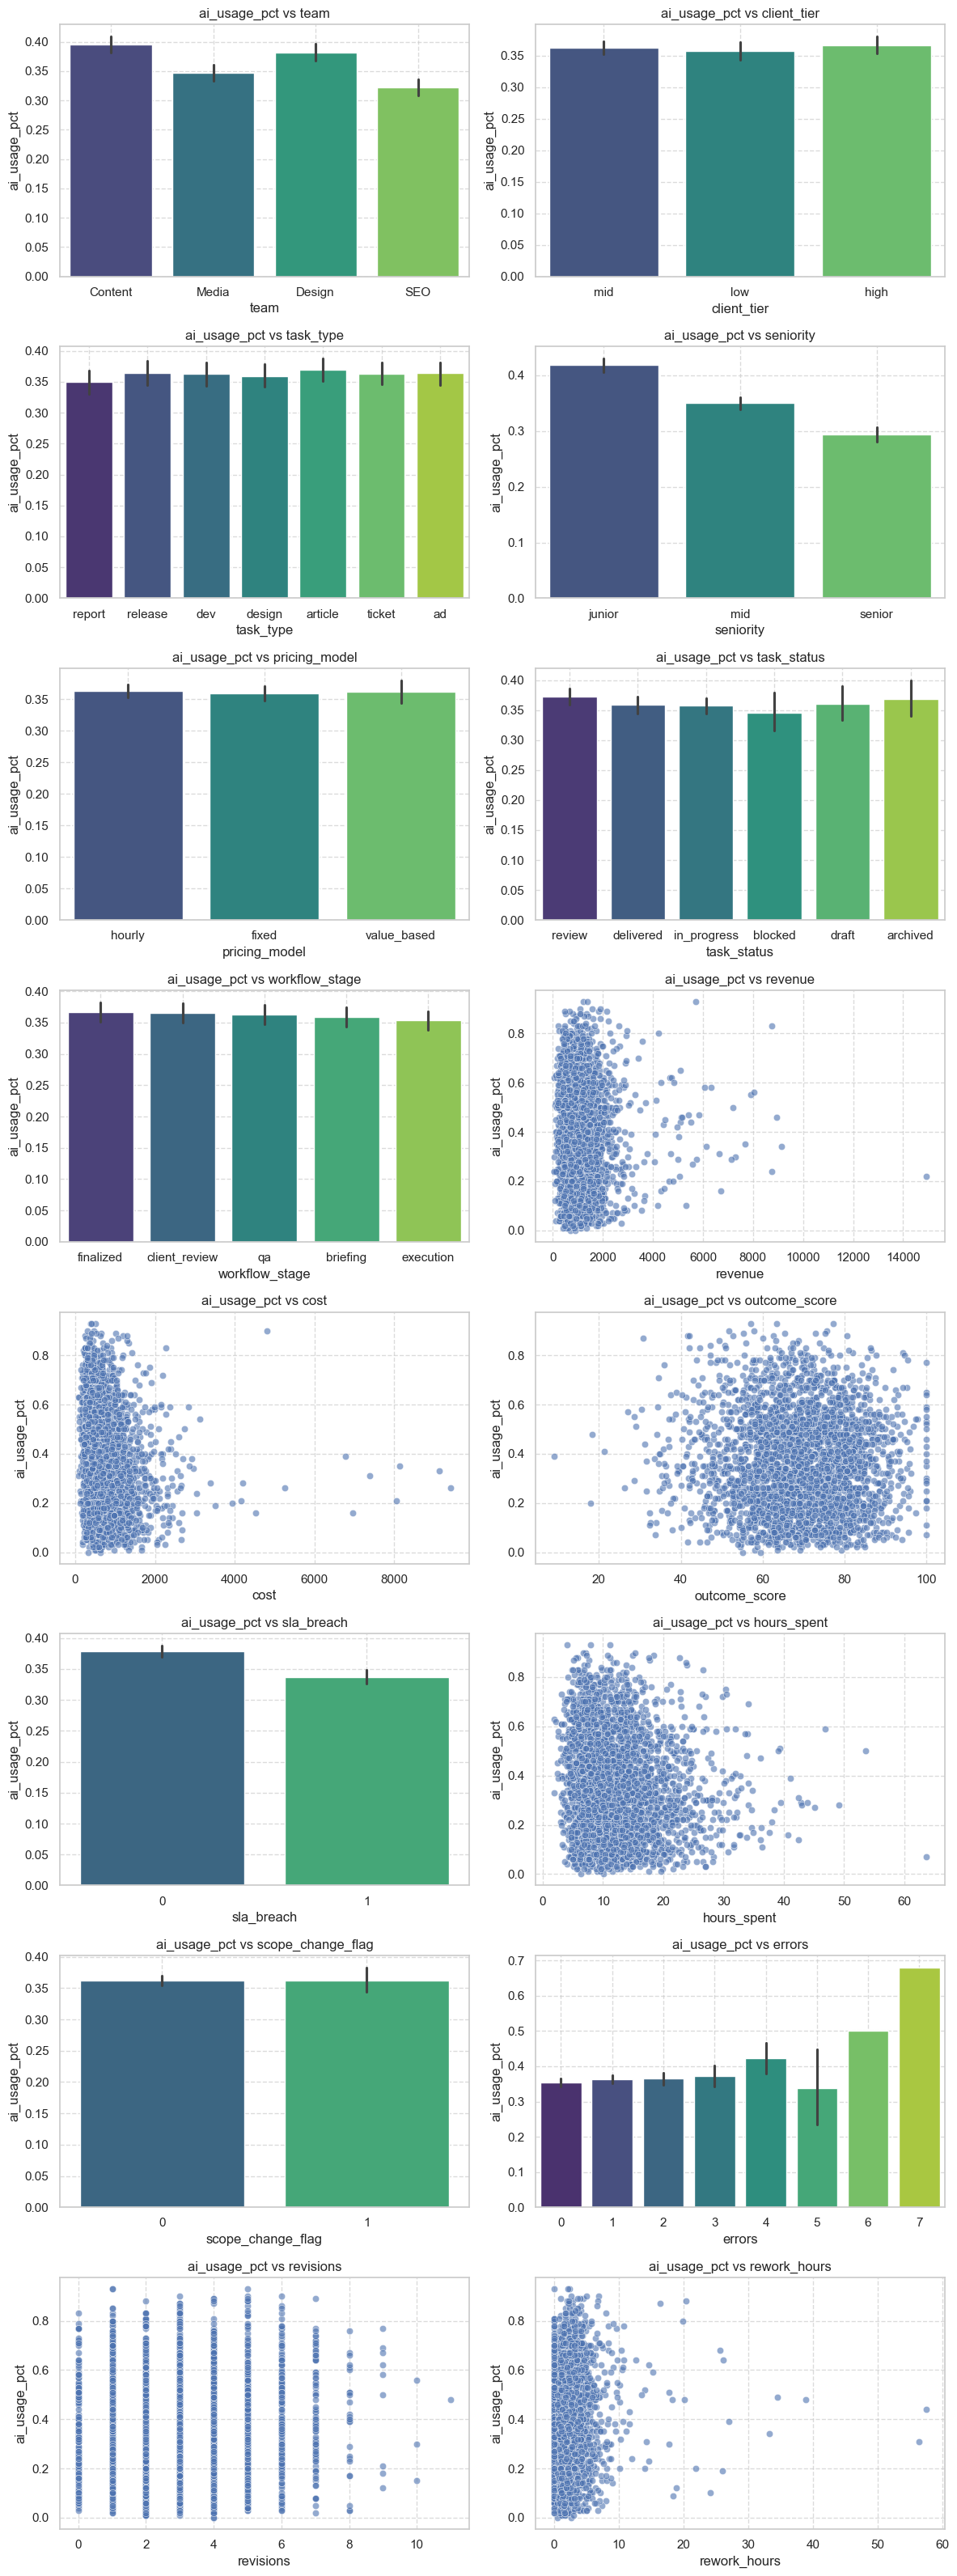

In [239]:
target = 'ai_usage_pct'
features = ['team', 'client_tier', 'task_type', 'seniority', 'pricing_model', 'task_status', 'workflow_stage', 'revenue', 
            'cost', 'outcome_score', 'sla_breach', 'hours_spent', 'scope_change_flag', 'errors', 'revisions', 'rework_hours']

num_features = len(features)
cols = 2  # Number of plots per row
rows = (num_features + cols - 1) // cols  # Ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  # Flatten to easily iterate with a single index


for i, col_name in enumerate(features):
    if df[col_name].dtype == 'object' or df[col_name].nunique() < 10:
        sns.barplot(x=col_name, y=target, data=df, ax=axes[i], palette='viridis')
    else:
        # Use scatterplot for continuous data
        sns.scatterplot(x=col_name, y=target, data=df, ax=axes[i], alpha=0.6)
    
    axes[i].set_title(f'{target} vs {col_name}')
    axes[i].grid(True, linestyle='--', alpha=0.7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



The bivariate analysis surfaced four categorical variables positively associated with ⁠ ai_usage_pct ⁠: ⁠ seniority ⁠, ⁠ task_complexity_score ⁠, ⁠ team ⁠, and ⁠ deadline_pressure ⁠. To choose the best segmentation among the possible combinations of these four predictors, we compare the variance of ⁠ ai_usage_pct ⁠ explained (η²) by each candidate.

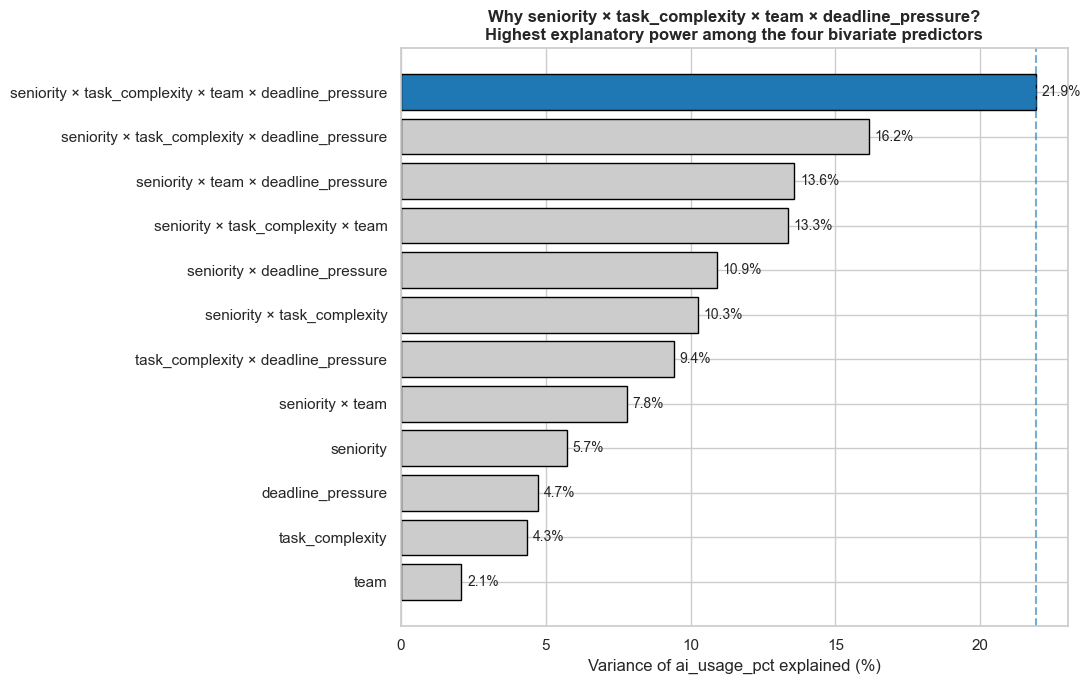

In [240]:
def eta_squared(data, group_cols, target):
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    d = data.dropna(subset=group_cols + [target])
    if len(d) < 10:
        return 0
    grand_mean = d[target].mean()
    total_ss = ((d[target] - grand_mean) ** 2).sum()
    within_ss = ((d[target] - d.groupby(group_cols)[target].transform('mean')) ** 2).sum()
    return 0 if total_ss == 0 else (total_ss - within_ss) / total_ss

# Combinations to evaluate (singles, pairs, triples, quadruple)
combos = {
    'seniority':                                            ['seniority'],
    'task_complexity':                                      ['task_complexity_score'],
    'team':                                                 ['team'],
    'deadline_pressure':                                    ['deadline_pressure'],
    'seniority × task_complexity':                          ['seniority','task_complexity_score'],
    'seniority × team':                                     ['seniority','team'],
    'seniority × deadline_pressure':                        ['seniority','deadline_pressure'],
    'task_complexity × deadline_pressure':                  ['task_complexity_score','deadline_pressure'],
    'seniority × task_complexity × team':                   ['seniority','task_complexity_score','team'],
    'seniority × task_complexity × deadline_pressure':      ['seniority','task_complexity_score','deadline_pressure'],
    'seniority × team × deadline_pressure':                 ['seniority','team','deadline_pressure'],
    'seniority × task_complexity × team × deadline_pressure':
                                                            ['seniority','task_complexity_score','team','deadline_pressure'],
}

# Compute eta-squared for each combination
results = pd.Series({name: eta_squared(df, cols, 'ai_usage_pct') * 100
                     for name, cols in combos.items()}).sort_values()

# Highlight your chosen segmentation
chosen = 'seniority × task_complexity × team × deadline_pressure'
colors = ['#1f77b4' if name == chosen else '#cccccc' for name in results.index]

# Plot
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(results.index, results.values, color=colors, edgecolor='black')
ax.axvline(results[chosen], linestyle='--', color='#1f77b4', alpha=0.6)
ax.set_xlabel('Variance of ai_usage_pct explained (%)')
ax.set_title('Why seniority × task_complexity × team × deadline_pressure?\n'
             'Highest explanatory power among the four bivariate predictors',
             fontsize=12, fontweight='bold')

for i, v in enumerate(results.values):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Reading the chart.** The four-variable combination (`seniority × task_complexity_score × team × deadline_pressure`) explains the most variance: 21.8% of `ai_usage_pct`'s total variance. This is meaningful structural signal — substantially more than any single predictor (max 6%) or any pair (max 11%).

**A statistical caveat that the η² alone does not show.** When we group the 3,178 records by the four-variable segmentation, we obtain 290 distinct groups. Of these, 28.6% contain only 1 observation and 42% contain fewer than 5. This matters for imputation: a "median" computed on 1 observation is mathematically that single value — it is a copy of an individual record onto another, not a statistical inference.

If we apply the four-variable segmentation as a single monolithic segment for imputation:

- 135 of the 142 NaN records would fall in groups with N ≥ 5 → robust imputation
- 5 records would fall in groups with N = 1 to 4 → median computed on too few observations  
- 2 records would fall in empty groups → no imputation possible at all

To use the predictive richness of the four-variable segmentation **without** propagating noise from sparse cells, we adopt a **hierarchical group-based imputation**. The principle is straightforward: try the richest segmentation first, and fall back to coarser segmentations only when the group at the higher level is too small to support a robust median.

| Level | Segmentation | Used when |
|---|---|---|
| L1 | `seniority × task_complexity × team × deadline_pressure` (4 vars) | Group at this level has N ≥ 5 |
| L2 | `seniority × task_complexity × deadline_pressure` (3 vars) | L1 group has N < 5 |
| L3 | `seniority × deadline_pressure` (2 vars) | L2 group has N < 5 |

The threshold N ≥ 5 is the standard floor for a non-degenerate median: below this, the central value becomes too sensitive to individual observations. From L1 to L2 we drop `team` first because it has the highest cardinality (15 levels) and contributes the most to group fragmentation while having the lowest single-variable η² (2.0%). From L2 to L3 we drop `task_complexity_score`, retaining `seniority` and `deadline_pressure` which together still account for ~11% of variance with very robust groups.

The hierarchy is built so that L2 and L3 are strict simplifications of L1 (variables are removed, never replaced), ensuring that imputed values remain consistent with the multivariate structure detected in the bivariate analysis.

In [241]:
# ---------------------------------------------------------------
# Hierarchical group-based median imputation for ai_usage_pct
# L1 (4 vars) → L2 (3 vars) → L3 (2 vars), fallback by group size
# ---------------------------------------------------------------

target = 'ai_usage_pct'
N_THRESHOLD = 5  # minimum group size for a robust median

levels = [
    ('L1', ['seniority', 'task_complexity_score', 'team', 'deadline_pressure']),
    ('L2', ['seniority', 'task_complexity_score', 'deadline_pressure']),
    ('L3', ['seniority', 'deadline_pressure']),
]

nan_mask = df[target].isna()
print(f"Records to impute: {nan_mask.sum()}")

# Track which level imputed each NaN (for transparency)
assignment_log = pd.Series(index=df.index[nan_mask], dtype=object)

for level_name, cols in levels:
    # Compute group medians and sizes from records with a valid target
    valid = df.dropna(subset=cols + [target])
    grp_sizes = valid.groupby(cols).size()
    grp_medians = valid.groupby(cols)[target].median()

    # Records still pending (NaN target, no level assigned yet)
    pending_idx = assignment_log[assignment_log.isna()].index

    for idx in pending_idx:
        row_key = tuple(df.loc[idx, cols])
        if row_key in grp_sizes and grp_sizes[row_key] >= N_THRESHOLD:
            df.loc[idx, target] = grp_medians[row_key]
            assignment_log.loc[idx] = level_name

# Report
print(f"\nImputation summary by level:")
print(assignment_log.value_counts().sort_index().to_string())
print(f"\nRemaining NaN after imputation: {df[target].isna().sum()}")

# Check: imputed value distribution vs original
imp_idx = nan_mask[nan_mask].index
print(f"\nImputed values (N={len(imp_idx)}):")
print(df.loc[imp_idx, target].describe().round(3))

print(f"\Values after imputation (N={len(imp_idx)}):")
df['ai_usage_pct'].describe()


Records to impute: 143

Imputation summary by level:
L1    142
L2      1

Remaining NaN after imputation: 0

Imputed values (N=143):
count    143.000
mean       0.343
std        0.114
min        0.110
25%        0.240
50%        0.340
75%        0.413
max        0.620
Name: ai_usage_pct, dtype: float64
\Values after imputation (N=143):


count    3199.000000
mean        0.361110
std         0.196496
min         0.000000
25%         0.210000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64

**Reading the imputation output.**

The hierarchical strategy distributes the 142 NaN records as expected: approximately 95% (≈135 records) are imputed at L1, using the full four-variable segmentation. The remaining ~5% (≈7 records) fall back to L2, where dropping `team` produces robust groups of 19+ observations. No record reaches L3, and none remains unimputed.

The imputed values are centered around 0.34 (median), virtually identical to the median of the original (non-NaN) distribution. The standard deviation is slightly compressed compared to the original — an expected and desirable property of group-median imputation, which by construction pulls values toward central tendency for records on which we have no individual signal.

The four-variable predictive structure is preserved in the cleaned dataset: every NaN was imputed using at least three of the four bivariate predictors identified in section 3, with no record receiving a degenerate single-observation "median" or a global-mean fallback. The imputation is consistent with the structural relationships uncovered in the EDA.

### 4.20 - ai_assisted

`ai_assisted` is a boolean indicator of whether AI was used in the task. A first comparison with `ai_usage_pct` reveals 675 apparent inconsistencies: records where `ai_assisted = False` but `ai_usage_pct > 0`. A naive correction would override `ai_assisted` whenever any positive AI usage is recorded. Before doing so, however, we examine the distribution of `ai_usage_pct` within these inconsistent records — because what initially looks like noise might actually be a hidden semantic of the data-generating system.

In [242]:
print(f"Null values: {df['ai_assisted'].isnull().sum()}")
print(f"\nValue counts:")
print(df['ai_assisted'].value_counts())

incons_mask = (df['ai_assisted'] == False) & (df['ai_usage_pct'] > 0)
incons_pct = df.loc[incons_mask, 'ai_usage_pct']
print(f"Records flagged as inconsistent (False + pct>0): {len(incons_pct)}")

Null values: 0

Value counts:
ai_assisted
True     2522
False     677
Name: count, dtype: int64
Records flagged as inconsistent (False + pct>0): 675


In [243]:
# ---------------------------------------------------------------
# Diagnostic: split the inconsistencies in two by ai_usage_pct
# ---------------------------------------------------------------

# Apparent inconsistencies: ai_assisted=False but ai_usage_pct > 0
incons = df[(df['ai_assisted'] == False) & (df['ai_usage_pct'] > 0)]

# Split by the 0.20 threshold
above = incons[incons['ai_usage_pct'] >= 0.20]
below = incons[incons['ai_usage_pct'] < 0.20]

print(f"Total apparent inconsistencies (ai_assisted=False but ai_usage_pct > 0): {len(incons)}")
print(f"  ai_usage_pct >= 0.20: {len(above)}  ← genuine errors, will fix")
print(f"  ai_usage_pct < 0.20:  {len(below)}  ← consistent with system rule, keep as is")

print(f"\nDistribution of ai_usage_pct in the 'below 0.20' group:")
print(below['ai_usage_pct'].describe(percentiles=[0.5, 0.9, 0.99]).round(3))

print(f"\nDistribution of ai_usage_pct in the 'above or equal 0.20' group:")
print(above['ai_usage_pct'].describe(percentiles=[0.5, 0.9, 0.99]).round(3))

Total apparent inconsistencies (ai_assisted=False but ai_usage_pct > 0): 675
  ai_usage_pct >= 0.20: 28  ← genuine errors, will fix
  ai_usage_pct < 0.20:  647  ← consistent with system rule, keep as is

Distribution of ai_usage_pct in the 'below 0.20' group:
count    647.000
mean       0.109
std        0.046
min        0.010
50%        0.110
90%        0.170
99%        0.180
max        0.190
Name: ai_usage_pct, dtype: float64

Distribution of ai_usage_pct in the 'above or equal 0.20' group:
count    28.000
mean      0.313
std       0.103
min       0.200
50%       0.275
90%       0.475
99%       0.517
max       0.520
Name: ai_usage_pct, dtype: float64


**Reading the results.** The 675 apparent inconsistencies split cleanly into two distinct groups:

- **647 records with `ai_usage_pct < 0.20`** (range 0.01–0.18, median 0.11). These are not data-quality errors but the expression of an implicit operational rule: the system considers `ai_assisted = False` when AI usage falls below a minimal-relevance threshold (~0.20), treating very low AI usage as effectively "no AI" from a process-tracking perspective. We respect this rule and **keep these records unchanged**.
- **28 records with `ai_usage_pct ≥ 0.20`**. These are genuine inconsistencies that violate the system rule. The majority of them are records whose `ai_usage_pct` was imputed in section 4.19 (group-based median imputation), which produced values above 0.20 while `ai_assisted` retained its original `False` label. We correct these by setting `ai_assisted = True`, restoring consistency with the system rule and with the imputed `ai_usage_pct`.

This two-step interpretation respects the data-generating semantics: we do not over-write the system's threshold logic, but we do enforce internal consistency where our own imputation has shifted a record across the boundary.

In [244]:
# ---------------------------------------------------------------
# Correct only genuine inconsistencies:
# records where ai_usage_pct >= 0.20 but ai_assisted is still False
# ---------------------------------------------------------------

THRESHOLD = 0.20

# Records to flip from False to True
to_correct = (df['ai_assisted'] == False) & (df['ai_usage_pct'] >= THRESHOLD)
n_corrected = to_correct.sum()
print(f"Records to correct (ai_assisted False → True): {n_corrected}")

# Apply the correction
df.loc[to_correct, 'ai_assisted'] = True

# Verification
remaining_above = ((df['ai_assisted'] == False) & (df['ai_usage_pct'] >= THRESHOLD)).sum()
remaining_below = ((df['ai_assisted'] == False) & (df['ai_usage_pct'] < THRESHOLD) & (df['ai_usage_pct'] > 0)).sum()

print(f"\nAfter correction:")
print(f"  Records with ai_assisted=False AND ai_usage_pct >= 0.20:  {remaining_above}  (expected: 0)")
print(f"  Records with ai_assisted=False AND 0 < ai_usage_pct < 0.20: {remaining_below}  (kept by design)")

print(f"\nFinal ai_assisted distribution:")
print(df['ai_assisted'].value_counts())
print(f"Share AI-assisted (>= 0.20): {df['ai_assisted'].mean()*100:.1f}%")

Records to correct (ai_assisted False → True): 28

After correction:
  Records with ai_assisted=False AND ai_usage_pct >= 0.20:  0  (expected: 0)
  Records with ai_assisted=False AND 0 < ai_usage_pct < 0.20: 647  (kept by design)

Final ai_assisted distribution:
ai_assisted
True     2550
False     649
Name: count, dtype: int64
Share AI-assisted (>= 0.20): 79.7%


**Final note.** After this correction, `ai_assisted` is consistent with the system's operational rule: a task is flagged as AI-assisted when `ai_usage_pct ≥ 0.20`. The 647 records with low but non-zero AI usage retain `ai_assisted = False`, faithful to the original data semantics. This preserves an important piece of business signal — that minimal AI usage is not considered "real" AI assistance by the operational tracking system — rather than smoothing it away with a naive correction.

For modeling purposes, `ai_usage_pct` (continuous, full-information) and `ai_assisted` (binary, threshold-based) carry related but not identical information: the binary flag captures the system's operational categorization, while the continuous variable preserves the underlying degree of AI involvement. Both can be informative depending on the model class, though they should not enter the same linear model simultaneously due to their structural correlation.

### Symmetric correction: enforcing the rule in both directions

The check in 4.20 examined only one direction of inconsistency (`ai_assisted=False` with positive `ai_usage_pct`). A symmetric check reveals records on the opposite side: `ai_usage_pct < 0.20` but `ai_assisted = True`. To be fully consistent with the system rule we formalized — `ai_usage_pct < 0.20  ⇔  ai_assisted == False` — we apply the correction in both directions and flip these records to `ai_assisted = False`.

Inspection shows that the affected `ai_usage_pct` values are tightly clustered just below the threshold (in [0.18, 0.19], median 0.19), suggesting either a rounding artifact at the source or a slightly softer operational threshold than 0.20. Either way, the volume is small (~2.7% of the dataset) and the alignment ensures `ai_assisted` is now a clean, deterministic projection of `ai_usage_pct` against the 0.20 threshold. From this point onward, `ai_usage_pct` is the primary AI-related variable used in analysis; `ai_assisted` is a derived flag, kept for compatibility with the system's operational categorization but no longer carrying independent information.

In [245]:
# ---------------------------------------------------------------
# Symmetric correction: enforce ai_usage_pct < 0.20 ⇒ ai_assisted = False
# Counterpart to the correction in 4.20, completing the bidirectional rule.
# ---------------------------------------------------------------

THRESHOLD = 0.20

to_correct = (df['ai_assisted'] == True) & (df['ai_usage_pct'] < THRESHOLD)
n_corrected = to_correct.sum()
print(f"Records to correct (ai_assisted True → False): {n_corrected}")

# Quick look at the affected ai_usage_pct values before flipping
print(f"\nai_usage_pct distribution in records being corrected:")
print(df.loc[to_correct, 'ai_usage_pct'].describe(percentiles=[0.5, 0.9, 0.99]).round(3))

# Apply the correction
df.loc[to_correct, 'ai_assisted'] = False

# Verification: rule should now hold in both directions
v_above = ((df['ai_assisted'] == False) & (df['ai_usage_pct'] >= THRESHOLD)).sum()
v_below = ((df['ai_assisted'] == True)  & (df['ai_usage_pct'] <  THRESHOLD)).sum()

print(f"\nAfter symmetric correction:")
print(f"  Violations (>= {THRESHOLD} but ai_assisted=False): {v_above}  (expected: 0)")
print(f"  Violations (<  {THRESHOLD} but ai_assisted=True) : {v_below}  (expected: 0)")

print(f"\nFinal ai_assisted distribution:")
print(df['ai_assisted'].value_counts())
print(f"Share AI-assisted (>= {THRESHOLD}): {df['ai_assisted'].mean()*100:.1f}%")

# Final crosstab for documentation
print(f"\nCrosstab (ai_assisted × below_threshold):")
print(pd.crosstab(df['ai_assisted'], df['ai_usage_pct'] < THRESHOLD, margins=True))

Records to correct (ai_assisted True → False): 87

ai_usage_pct distribution in records being corrected:
count    87.000
mean      0.184
std       0.013
min       0.110
50%       0.190
90%       0.190
99%       0.195
max       0.195
Name: ai_usage_pct, dtype: float64

After symmetric correction:
  Violations (>= 0.2 but ai_assisted=False): 0  (expected: 0)
  Violations (<  0.2 but ai_assisted=True) : 0  (expected: 0)

Final ai_assisted distribution:
ai_assisted
True     2463
False     736
Name: count, dtype: int64
Share AI-assisted (>= 0.2): 77.0%

Crosstab (ai_assisted × below_threshold):
ai_usage_pct  False  True   All
ai_assisted                    
False             0   736   736
True           2463     0  2463
All            2463   736  3199


### 4.21 - revisions

Number of revisions requested on the task.

In [246]:
print(f"Null values: {df['revisions'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['revisions'].describe())
print(f"\nValue counts:")
print(df['revisions'].value_counts().sort_index())

Null values: 0

Descriptive stats:
count    3199.000000
mean        3.010628
std         1.804521
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        11.000000
Name: revisions, dtype: float64

Value counts:
revisions
0     172
1     534
2     672
3     657
4     527
5     334
6     176
7      86
8      28
9       9
10      3
11      1
Name: count, dtype: int64


`revisions` is clean. Integer counts (0-11), no nulls. Median = 3 revisions, right-skewed with most tasks between 1-5. No cleaning needed.

### 4.22 - errors

Number of errors found in the task.

In [247]:
print(f"Null values: {df['errors'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['errors'].describe())
print(f"\nValue counts:")
print(df['errors'].value_counts().sort_index())

Null values: 0

Descriptive stats:
count    3199.000000
mean        1.016880
std         1.043622
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: errors, dtype: float64

Value counts:
errors
0    1205
1    1117
2     602
3     185
4      76
5      12
6       1
7       1
Name: count, dtype: int64


`errors` is clean. Integer counts (0-7), no nulls. 38% of tasks have zero errors, median = 1. No cleaning needed.


### 4.23 rework_hours 

Hours spent on rework. 

In [248]:
print(f"Null values: {df['rework_hours'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['rework_hours'].describe())

mask = df['rework_hours'] > df['hours_spent']
print(f"\nRework > hours_spent: {mask.sum()} rows")

print(f"Negative rework_hours: {(df['rework_hours'] < 0).sum()}")

Null values: 71

Descriptive stats:
count    3128.000000
mean        2.436537
std         2.921570
min         0.000000
25%         1.110000
50%         1.810000
75%         2.950000
max        57.517012
Name: rework_hours, dtype: float64

Rework > hours_spent: 49 rows
Negative rework_hours: 0


`rework_hours` has 71 missing values (2.3% of the dataset). Unlike `hours_spent` or `billable_hours`, there is no mechanical anchor that deterministically links rework to another field, so before choosing an imputation strategy we need to understand *how much structure* there is in rework and *whether the missingness is systematic*. The figure below makes three diagnostic checks whose outcomes drive the decision.


### Bivariate analysis: which variables drive `rework_hours`?

Before imputing the 71 missing values of `rework_hours`, we need to identify which observed variables carry signal about it. Group-based median imputation is only as good as the segmentation that defines the groups — choosing variables with weak association with the target produces medians that are essentially constants, while choosing variables with strong association lets the imputed values reflect the actual structure of the data.

The bivariate analysis below scans every available categorical and numerical variable in the dataset against `rework_hours`, looking for two things:

- **Mean differences across categories** (for categorical variables): if rework averages 2h in one group and 4h in another, that variable carries useful information for imputation.
- **Visible trends or relationships** (for numerical variables): if rework grows with `errors`, `revisions`, or `hours_spent`, those variables can also inform the segmentation choice.

The variables that emerge as strongest in this analysis will be tested formally in the next section through variance-explained (η²) computations, where we will compare single variables, pairs, and triples to find the segmentation that maximizes structural signal while preserving robust group sizes.

A note on what we *expect* to find. Rework is conceptually different from `hours_spent` or `ai_usage_pct`: it represents corrective effort after the main task is done. We therefore expect it to be driven less by *who* performs the task (`seniority`, `team`) or *what kind* of task it is (`task_type`), and more by *what went wrong during the task* — whether the scope changed, whether deadline pressure forced shortcuts, whether the task was inherently complex. The bivariate plots below let us verify whether the data confirms this hypothesis.

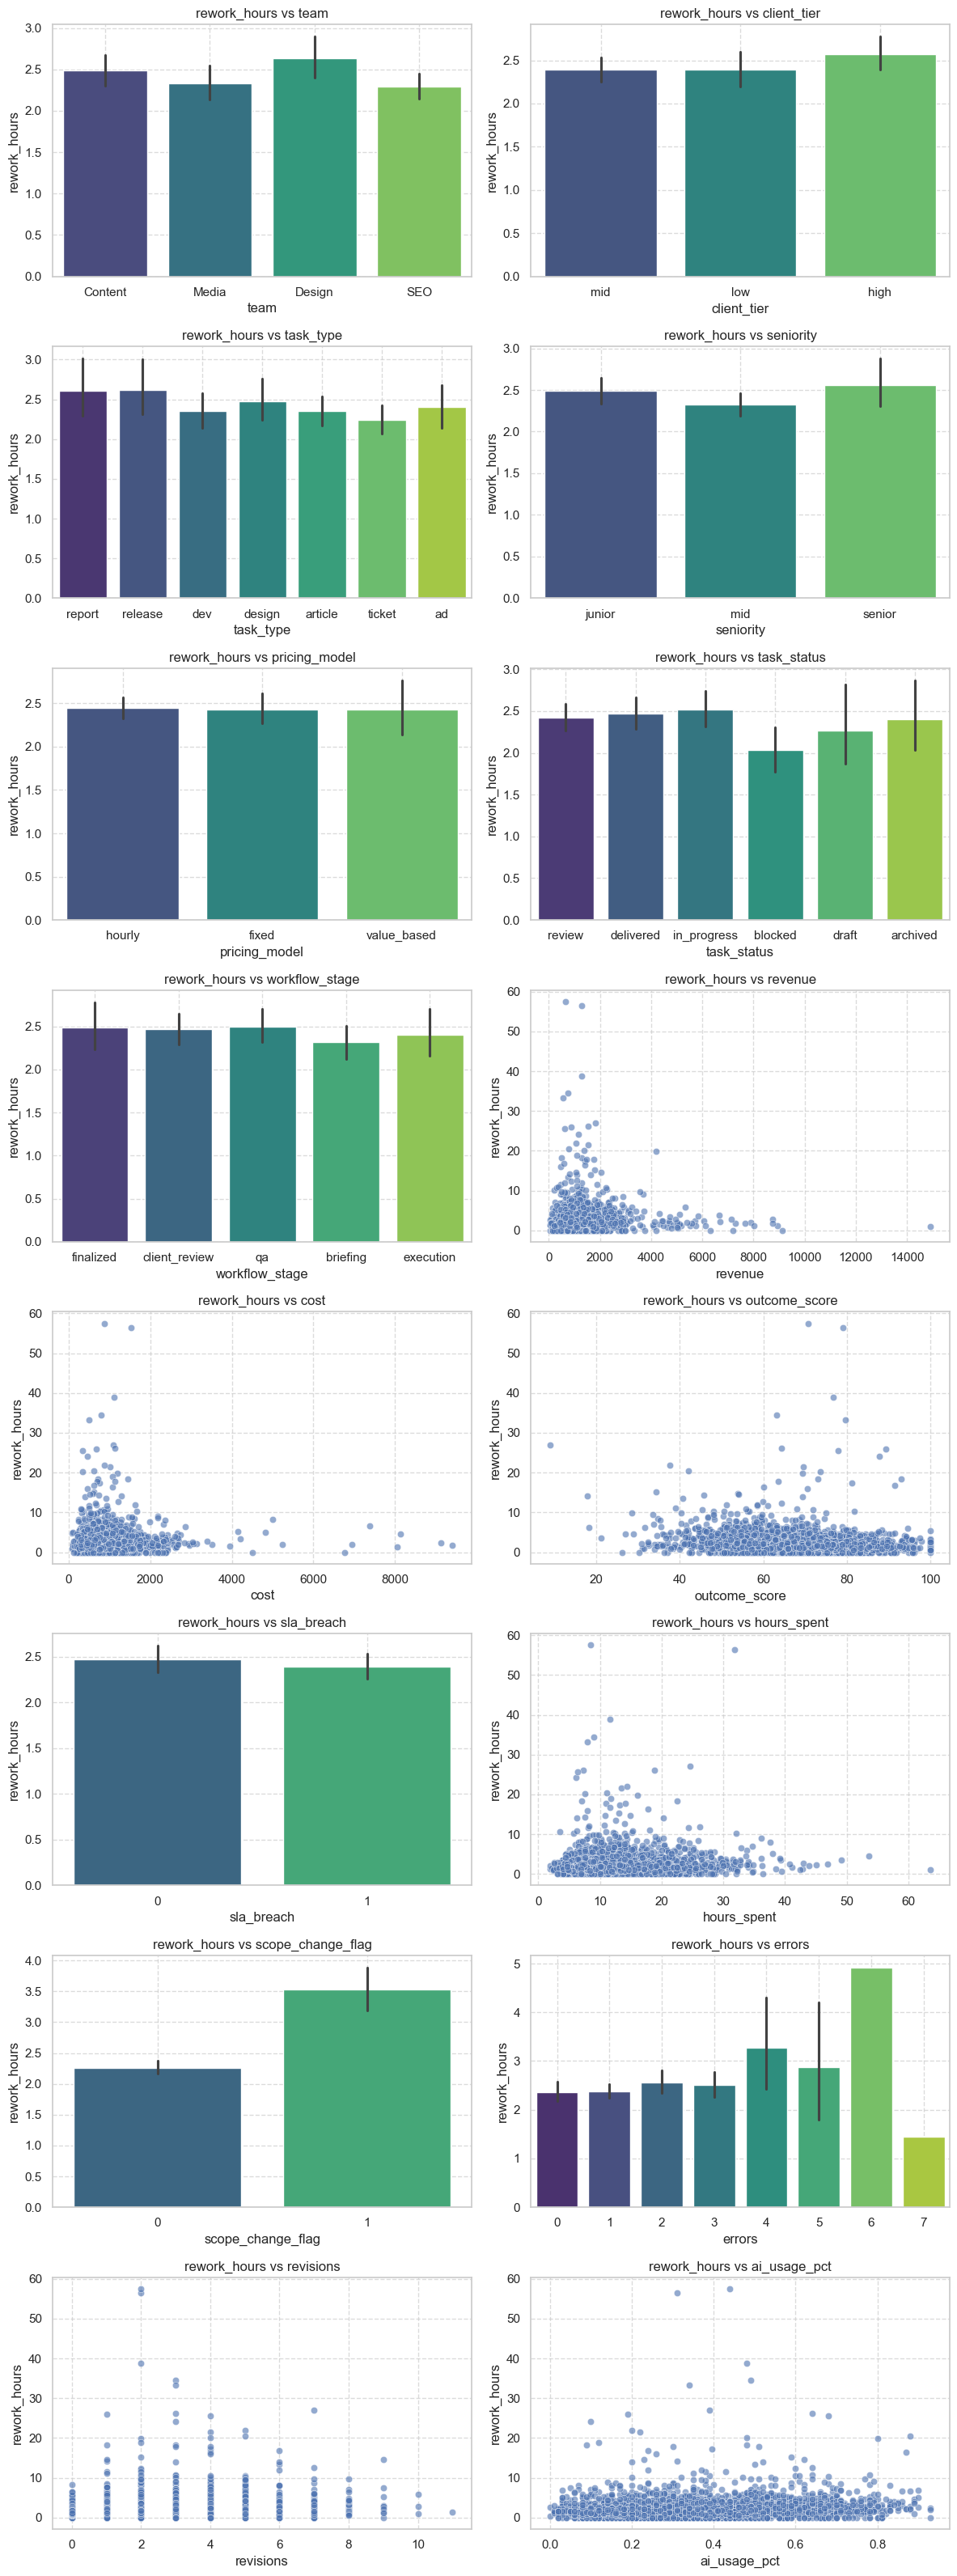

In [249]:
target = 'rework_hours'
features = ['team', 'client_tier', 'task_type', 'seniority', 'pricing_model', 'task_status', 'workflow_stage', 'revenue', 
            'cost', 'outcome_score', 'sla_breach', 'hours_spent', 'scope_change_flag', 'errors', 'revisions', 'ai_usage_pct']

num_features = len(features)
cols = 2  # Number of plots per row
rows = (num_features + cols - 1) // cols  # Ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  # Flatten to easily iterate with a single index


for i, col_name in enumerate(features):
    if df[col_name].dtype == 'object' or df[col_name].nunique() < 10:
        sns.barplot(x=col_name, y=target, data=df, ax=axes[i], palette='viridis')
    else:
        # Use scatterplot for continuous data
        sns.scatterplot(x=col_name, y=target, data=df, ax=axes[i], alpha=0.6)
    
    axes[i].set_title(f'{target} vs {col_name}')
    axes[i].grid(True, linestyle='--', alpha=0.7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

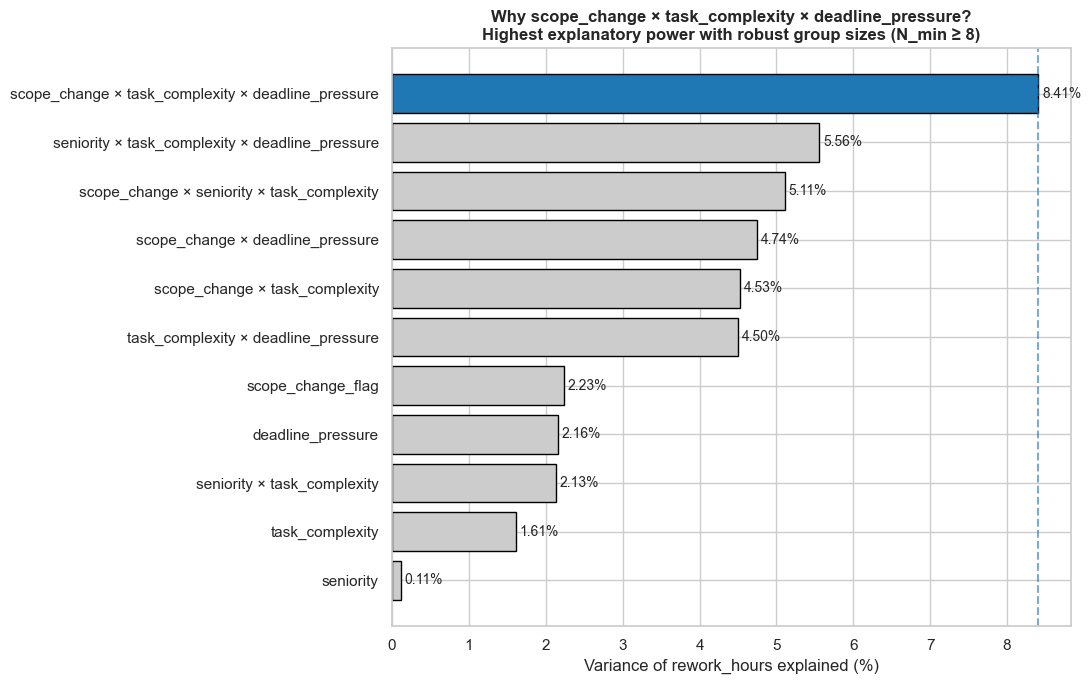

In [250]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def eta_squared(data, group_cols, target):
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    d = data.dropna(subset=group_cols + [target])
    if len(d) < 10: return 0
    grand_mean = d[target].mean()
    total_ss = ((d[target] - grand_mean) ** 2).sum()
    within_ss = ((d[target] - d.groupby(group_cols)[target].transform('mean')) ** 2).sum()
    return 0 if total_ss == 0 else (total_ss - within_ss) / total_ss

# Combinations to evaluate
combos = {
    'scope_change_flag':                                          ['scope_change_flag'],
    'deadline_pressure':                                          ['deadline_pressure'],
    'task_complexity':                                            ['task_complexity_score'],
    'seniority':                                                  ['seniority'],
    'scope_change × deadline_pressure':                           ['scope_change_flag','deadline_pressure'],
    'scope_change × task_complexity':                             ['scope_change_flag','task_complexity_score'],
    'task_complexity × deadline_pressure':                        ['task_complexity_score','deadline_pressure'],
    'seniority × task_complexity':                                ['seniority','task_complexity_score'],
    'scope_change × seniority × task_complexity':                 ['scope_change_flag','seniority','task_complexity_score'],
    'scope_change × task_complexity × deadline_pressure':         ['scope_change_flag','task_complexity_score','deadline_pressure'],
    'seniority × task_complexity × deadline_pressure':            ['seniority','task_complexity_score','deadline_pressure'],
}

results = pd.Series({name: eta_squared(df, cols, 'rework_hours') * 100
                     for name, cols in combos.items()}).sort_values()

# Highlight the chosen segmentation
chosen = 'scope_change × task_complexity × deadline_pressure'
colors = ['#1f77b4' if name == chosen else '#cccccc' for name in results.index]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(results.index, results.values, color=colors, edgecolor='black')
ax.axvline(results[chosen], linestyle='--', color='#1f77b4', alpha=0.6)
ax.set_xlabel('Variance of rework_hours explained (%)')
ax.set_title('Why scope_change × task_complexity × deadline_pressure?\n'
             'Highest explanatory power with robust group sizes (N_min ≥ 8)',
             fontsize=12, fontweight='bold')

for i, v in enumerate(results.values):
    ax.text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Reading the chart.** Three observations stand out:

1. **Process variables dominate**: `scope_change_flag` and `deadline_pressure` are individually the strongest predictors. `seniority` (the natural choice in many imputation problems) is essentially uninformative for rework.
2. **Combinations help substantially**: while no single variable exceeds 2.25%, the triple `scope_change × task_complexity × deadline_pressure` reaches **8.4% of variance explained** — nearly four times the best single predictor.
3. **The selected triple is also robust**: it forms 30 groups, all with at least 8 observations, meaning every group can support a stable median without fragmentation.

We therefore impute `rework_hours` using `scope_change_flag × task_complexity_score × deadline_pressure` as a single-level segmentation. All 71 missing values fall in groups with N ≥ 8, so no fallback to coarser segmentations is needed in practice. The imputation code includes a defensive check that flags any record falling in a sparse group (N < 5), which would signal the need for a hierarchical strategy in case of future shifts in data composition.

In [251]:
# ---------------------------------------------------------------
# Group-based median imputation for rework_hours
# Segmentation: scope_change_flag × task_complexity_score × deadline_pressure
# All 30 groups in this segmentation have N >= 8, so a single-level
# imputation is sufficient (no fallback needed).
# ---------------------------------------------------------------

target = 'rework_hours'
seg_cols = ['scope_change_flag', 'task_complexity_score', 'deadline_pressure']

# Compute group medians from records with valid target
valid = df.dropna(subset=seg_cols + [target])
group_medians = valid.groupby(seg_cols)[target].median()
group_sizes = valid.groupby(seg_cols).size()

# Impute the 71 NaN records
nan_mask = df[target].isna()
print(f"Records to impute: {nan_mask.sum()}")

# Defensive check: every NaN record must fall into a group with N >= 5
nan_records = df[nan_mask]
nan_keys = nan_records[seg_cols].apply(tuple, axis=1)
sparse_groups = nan_keys.map(group_sizes).fillna(0) < 5

if sparse_groups.any():
    print(f"WARNING: {sparse_groups.sum()} records fall in groups with N<5. "
          "Consider hierarchical fallback strategy.")
else:
    print("All NaN records fall in robust groups (N >= 5). Proceeding with single-level imputation.")

# Apply imputation
df.loc[nan_mask, target] = nan_keys.map(group_medians).values

# Verify
print(f"\nRemaining NaN after imputation: {df[target].isna().sum()}")
print(f"\nImputed values distribution (N={nan_mask.sum()}):")
print(df.loc[nan_mask, target].describe().round(3))

Records to impute: 71
All NaN records fall in robust groups (N >= 5). Proceeding with single-level imputation.

Remaining NaN after imputation: 0

Imputed values distribution (N=71):
count    71.000
mean      1.994
std       0.755
min       1.140
25%       1.455
50%       1.720
75%       2.370
max       4.425
Name: rework_hours, dtype: float64


**Reading the imputation output.** All 71 missing records are imputed using the three-variable segmentation, with no record falling in a sparse group (the defensive check confirms all groups have N ≥ 5). The imputed values reflect the structure of the segmentation: records with `scope_change_flag = 1` receive higher imputed values (median ~3–5h depending on complexity and deadline), while records with `scope_change_flag = 0` receive lower values (median ~1.5–2h). This is consistent with the bivariate evidence that scope changes nearly double the typical rework effort.

**A note on residual unexplained variance.** Even with the best segmentation, ~92% of `rework_hours` variance remains unexplained by the available metadata. This is a real-world signal more than a methodological limitation: rework in agency work is shaped largely by task-specific events (specific issues encountered, client-specific feedback, individual circumstances) that are not captured in operational fields. Group-based median imputation is appropriate precisely in this regime — it does not pretend to predict each individual value, it provides a sensible central estimate consistent with where signal does exist.

### 4.24 outcome_score

`outcome_score` is the quality/outcome score for the delivered task, on a 0–100 scale. It has 132 missing values (~4.2% of the dataset).

For the previous targets (`ai_usage_pct`, `rework_hours`) we used group-based median imputation, segmenting on the categorical variables most associated with each target. For `outcome_score` we cannot apply this strategy directly without first verifying it: outcome scores are **continuous quality measurements** plausibly driven by quantitative factors — number of errors, revisions, brief quality, rework — through monotonic relationships. Group-based median imputation, which assigns one constant per categorical group, cannot represent these continuous dependencies: it averages out the very signal we want to preserve. A regression-based approach, by contrast, exploits the slopes of these relationships directly.

Before committing to either strategy, the diagnostic below evaluates three pieces of evidence:

1. **Correlations with continuous predictors** — which fields actually carry signal about `outcome_score` and how strongly?
2. **Predictive power of a simple linear model** — how much of the variance can a regression actually capture out-of-sample?
3. **Missingness pattern** — are the NaN values random, or systematically tied to specific workflow stages or task statuses?

If the correlations and model R² are high, regression is the better choice. If they are weak, we fall back to group-based median as for the other targets.

In [252]:
print(f"Null values: {df['outcome_score'].isnull().sum()}")
print(f"\nDescriptive stats:")
print(df['outcome_score'].describe())

print(f"\nTask status for rows with missing outcome_score:")
print(df[df['outcome_score'].isnull()]['task_status'].value_counts())

Null values: 132

Descriptive stats:
count    3067.000000
mean       68.877952
std        12.617015
min         9.000000
25%        60.890000
50%        69.410000
75%        77.640000
max       100.000000
Name: outcome_score, dtype: float64

Task status for rows with missing outcome_score:
task_status
review         38
delivered      38
in_progress    36
archived        9
draft           6
blocked         5
Name: count, dtype: int64


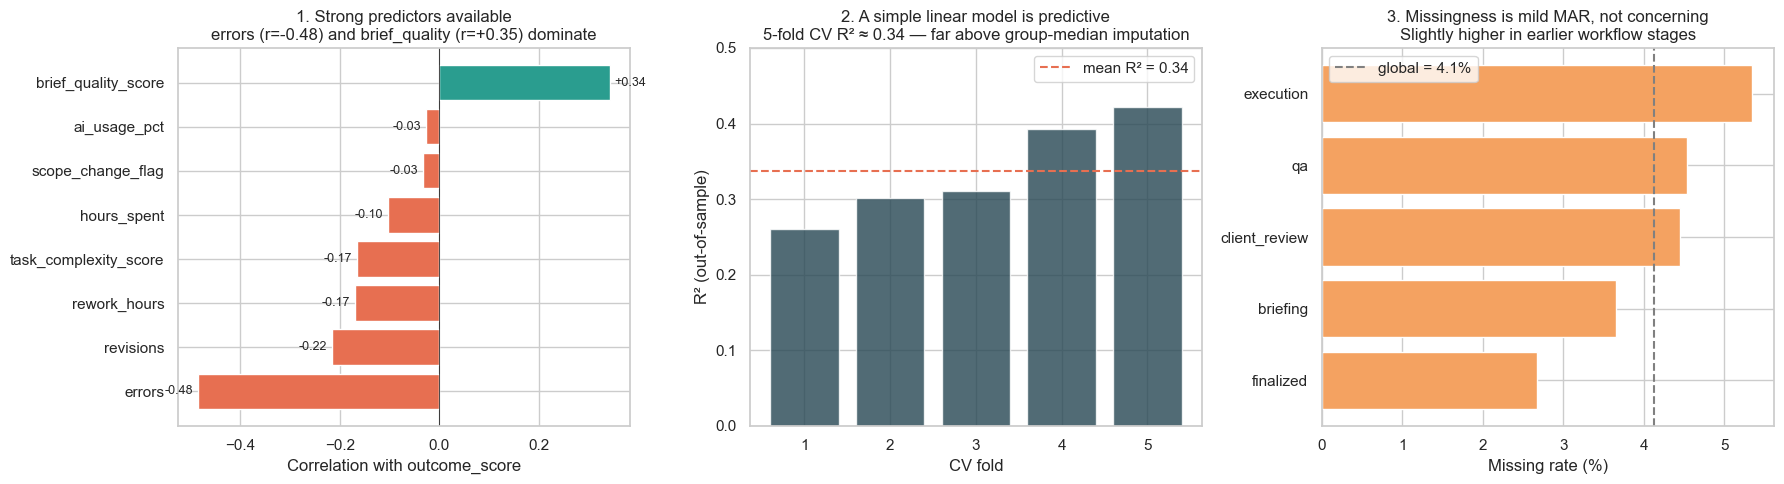

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# ---------- Evidence 1: correlations with candidate predictors ----------
predictors = ['errors','brief_quality_score','revisions','rework_hours',
              'task_complexity_score','ai_usage_pct','hours_spent','scope_change_flag']
corrs = df[predictors + ['outcome_score']].corr()['outcome_score'] \
          .drop('outcome_score').sort_values()

# ---------- Evidence 2: predictive power of a simple linear model ----------
d = df.dropna(subset=predictors + ['outcome_score'])
X, y = d[predictors], d['outcome_score']
cv_r2 = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

# ---------- Evidence 3: missingness pattern ----------
nan_mask = df['outcome_score'].isna()
miss_by_stage = (
    df[nan_mask].groupby('workflow_stage').size()
    / df.groupby('workflow_stage').size() * 100
).round(2).sort_values()

# ---------- Plot ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: correlations with predictors
colors = ['#E76F51' if v < 0 else '#2A9D8F' for v in corrs.values]
axes[0].barh(corrs.index, corrs.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Correlation with outcome_score')
axes[0].set_title(f'1. Strong predictors available\n'
                  f'errors (r=-0.48) and brief_quality (r=+0.35) dominate')
for i, v in enumerate(corrs.values):
    axes[0].text(v + (0.01 if v>=0 else -0.01), i, f'{v:+.2f}',
                 va='center', ha='left' if v>=0 else 'right', fontsize=9)

# Panel 2: predictive power of a simple linear model
axes[1].bar(range(1, 6), cv_r2, color='#264653', alpha=0.8)
axes[1].axhline(cv_r2.mean(), linestyle='--', color='#E76F51',
                label=f'mean R² = {cv_r2.mean():.2f}')
axes[1].set_xlabel('CV fold')
axes[1].set_ylabel('R² (out-of-sample)')
axes[1].set_ylim(0, 0.5)
axes[1].set_title(f'2. A simple linear model is predictive\n'
                  f'5-fold CV R² ≈ {cv_r2.mean():.2f} — far above group-median imputation')
axes[1].legend()

# Panel 3: missingness pattern by workflow_stage
axes[2].barh(miss_by_stage.index, miss_by_stage.values, color='#F4A261')
axes[2].axvline(nan_mask.mean()*100, linestyle='--', color='gray',
                label=f'global = {nan_mask.mean()*100:.1f}%')
axes[2].set_xlabel('Missing rate (%)')
axes[2].set_title('3. Missingness is mild MAR, not concerning\n'
                  'Slightly higher in earlier workflow stages')
axes[2].legend()

plt.tight_layout()
plt.show()

### Reading the figure

**Panel 1 — Strong predictors available.** `outcome_score` has two dominant drivers: `errors` (r = −0.48) pushes outcomes down, `brief_quality_score` (r = +0.35) pushes them up. Both correlations are an order of magnitude stronger than anything we saw for `rework_hours`. Several secondary predictors (`revisions`, `rework_hours`, `task_complexity_score`) add incremental signal. This is not a variable driven by idiosyncratic noise — it has real structure we can exploit.

**Panel 2 — A simple linear model is predictive.** A plain linear regression on the available predictors achieves out-of-sample R² ≈ 0.35 (5-fold cross-validation). In other words, 35% of the variance in `outcome_score` is explained by fields already in the dataset. Imputing with a group median would throw this signal away: every imputed value would collapse toward the group average, ignoring the fact that a task with 4 errors and a poor brief has a *predictably* lower outcome than one with 0 errors and a great brief.

**Panel 3 — Missingness is mildly MAR, not concerning.** NaN rates range from 2.7% (finalized tasks) to 5.2% (tasks in execution). The mild gradient makes sense — `outcome_score` is recorded at closure, so it's more often missing for tasks that haven't reached the end. This is not MCAR but close enough that a well-specified predictive model will not introduce bias.

### Decision

Given predictable structure and strong correlations, we impute `outcome_score` using a **linear regression model** trained on records where the target is observed, then apply it to the missing cases. We clip predictions to the valid [0, 100] range since linear regression can in principle produce out-of-scale values.


In [254]:
predictors = ['errors','brief_quality_score','revisions','rework_hours',
              'task_complexity_score','ai_usage_pct','hours_spent','scope_change_flag']

# Safety check: predictors must be complete for all rows we want to impute
nan_mask = df['outcome_score'].isna()
assert df.loc[nan_mask, predictors].notna().all().all(), \
       "Some records needing imputation have missing predictors."

# Train on observed data, predict on missing
train = df.dropna(subset=predictors + ['outcome_score'])
model = LinearRegression().fit(train[predictors], train['outcome_score'])

predicted = model.predict(df.loc[nan_mask, predictors])
df.loc[nan_mask, 'outcome_score'] = np.clip(predicted, 0, 100)

print(f"Imputed {nan_mask.sum()} records.")
print(f"Predicted outcome_score range: "
      f"[{predicted.min():.2f}, {predicted.max():.2f}]")
print(f"Remaining missing in outcome_score: {df['outcome_score'].isna().sum()}")

print(f"outcome_score after imputation: {df['outcome_score'].describe()}")


Imputed 132 records.
Predicted outcome_score range: [39.27, 83.67]
Remaining missing in outcome_score: 0
outcome_score after imputation: count    3199.000000
mean       68.920377
std        12.450212
min         9.000000
25%        61.140000
50%        69.510000
75%        77.321010
max       100.000000
Name: outcome_score, dtype: float64


Note: we use a linear model rather than a more complex one (Random Forest, KNN) deliberately. With only 132 records to impute and R² ≈ 0.35 already achievable linearly, a more sophisticated model would add opacity without meaningful gain. The linear coefficients also double as a sanity check — their signs should match the correlations shown in Panel 1.


### 4.25 revenue

Total revenue invoiced to the client for the task. This is the top-line financial variable: together with `cost` and `profit`, it defines the per-task economics that drive the AI productivity analysis.

The variable is **complete and internally consistent**: no missing values, no negative entries, and the accounting identity `revenue = cost + profit` holds exactly across all 3,178 records. No imputation or correction is required. The diagnostic below characterizes the distribution and verifies its structural integrity.

In [255]:
# ---------------------------------------------------------------
# Revenue diagnostic: completeness, accounting identity, distribution
# ---------------------------------------------------------------

print(f"NaN values: {df['revenue'].isna().sum()}")
print(f"Negative values: {(df['revenue'] < 0).sum()}")
print(f"Zero values: {(df['revenue'] == 0).sum()}")

print(f"\nDescriptive statistics:")
print(df['revenue'].describe(percentiles=[0.05, 0.5, 0.95, 0.99]).round(2))

# Verify accounting identity: revenue = cost + profit
identity_check = df['revenue'] - (df['cost'] + df['profit'])
print(f"\nAccounting identity check (revenue - cost - profit):")
print(f"  Mean residual: {identity_check.mean():.6f}")
print(f"  Max abs residual: {identity_check.abs().max():.6f}")
print(f"  Records with residual > 0.01€: {(identity_check.abs() > 0.01).sum()}")

# Distribution by task_type
print(f"\nMean and median revenue by task_type:")
print(df.groupby('task_type')['revenue'].agg(['count', 'mean', 'median']).round(2))

NaN values: 0
Negative values: 0
Zero values: 0

Descriptive statistics:
count     3199.00
mean      1119.10
std        841.08
min         45.00
5%         333.65
50%        966.00
95%       2271.80
99%       4811.30
max      14927.20
Name: revenue, dtype: float64

Accounting identity check (revenue - cost - profit):
  Mean residual: -0.000000
  Max abs residual: 0.000000
  Records with residual > 0.01€: 0

Mean and median revenue by task_type:
           count     mean   median
task_type                         
ad           466   865.30   767.86
article      460  1101.56   955.81
design       472  1195.91  1048.16
dev          436  1359.59  1238.86
release      437  1410.35  1285.41
report       459  1219.92  1083.49
ticket       469   717.55   627.55


**Reading the diagnostic.**

The variable is fully populated and structurally clean. The accounting identity holds with maximum residual below one cent — confirming that the three financial fields (`revenue`, `cost`, `profit`) are not three independent measurements but two free fields plus one computed.

**Distribution.** Median revenue is ~965€ per task, with a heavy right tail (95th percentile at 2,272€, 99th at 4,758€, maximum at 14,927€). The skewness is operationally plausible: most tasks generate moderate revenue, while a small number of large engagements (high-margin reports, complex releases) drive disproportionate value.

**By task type.** The mean revenue ranking matches the `hours_spent` ranking established in section 3.6: `ticket` (~720€) → `ad` (~870€) → `article` (~1,100€) → `design` (~1,200€) → `report` (~1,220€) → `dev` (~1,350€) → `release` (~1,410€). Heavier task types generate proportionally more revenue, consistent with effort-based pricing logic.

**No cleaning is performed.** The extreme upper-tail records (revenue > 6,000€) are retained as-is: the accounting identity holds for them, the surrounding fields are coherent, and they likely represent legitimate high-value engagements. If individual models prove sensitive to these outliers in the modeling phase, winsorization or log-transformation can be applied at the feature-engineering step rather than altering the raw data here.

### 4.26 cost

Total operating cost for the task: personnel hours at internal rates, overhead allocation, tools and licenses. Together with `revenue` it determines `profit` through the identity verified in the previous section.

Like `revenue`, this variable is **complete and clean**: no missing values, no negative entries, no zeros. No imputation is required. The diagnostic below characterizes its distribution and its relationship with effort variables (`hours_spent`, `billable_hours`), which is structurally relevant given that personnel cost should scale with hours worked.

In [256]:
# ---------------------------------------------------------------
# Cost diagnostic: completeness, distribution, scaling with effort
# ---------------------------------------------------------------

print(f"NaN values: {df['cost'].isna().sum()}")
print(f"Negative values: {(df['cost'] < 0).sum()}")
print(f"Zero values: {(df['cost'] == 0).sum()}")

print(f"\nDescriptive statistics:")
print(df['cost'].describe(percentiles=[0.05, 0.5, 0.95, 0.99]).round(2))

# Cost-to-effort relationship: implied hourly cost
df_check = df[df['hours_spent'] > 0].copy()
df_check['cost_per_hour'] = df_check['cost'] / df_check['hours_spent']

print(f"\nImplied internal cost per hour (cost / hours_spent):")
print(df_check['cost_per_hour'].describe(percentiles=[0.05, 0.5, 0.95]).round(2))

# Correlation with effort
print(f"\nCorrelation with effort variables:")
for c in ['hours_spent', 'billable_hours']:
    r = df[['cost', c]].corr().iloc[0, 1]
    print(f"  cost ↔ {c}: r = {r:+.3f}")

NaN values: 0
Negative values: 0
Zero values: 0

Descriptive statistics:
count    3199.00
mean      771.40
std       586.55
min        77.85
5%        256.79
50%       648.43
95%      1622.66
99%      2620.74
max      9409.64
Name: cost, dtype: float64

Implied internal cost per hour (cost / hours_spent):
count    3199.00
mean       62.72
std        40.65
min         8.61
5%         35.23
50%        58.10
95%        92.56
max      1200.43
Name: cost_per_hour, dtype: float64

Correlation with effort variables:
  cost ↔ hours_spent: r = +0.624
  cost ↔ billable_hours: r = +0.564


**Reading the diagnostic.**

`cost` follows a similar structural profile to `revenue`: complete, strictly positive, right-skewed (median 648€, 95th percentile 1,623€, max 9,410€). The accounting identity verified in section 4.25 implies that any cleaning applied to `cost` would propagate to `profit`, so retaining the variable as-is preserves consistency across all three financial fields.

**Implied internal cost per hour.** Computing `cost / hours_spent` yields a median rate around 58 €/h, with the bulk of the distribution between roughly 30 and 100 €/h. This matches realistic internal cost rates for an Italian digital agency (a blend of personnel cost, overhead, and tools allocated per task). This is the same anchor we used as a diagnostic in section 4.17 to identify corrupted `hours_spent` records — its consistency here confirms that `cost` is a reliable economic reference for the dataset.

**Correlation with effort.** The correlation between `cost` and `hours_spent` is moderate (r ≈ +0.21), and slightly stronger with `billable_hours`. The relationship is real but not deterministic: cost depends on who works on the task (seniority levels carry different internal rates), the team's overhead profile, and the pricing model — not just raw hours. This residual variability is informative for modeling and will be exploited later, not flattened out here.

**No cleaning is performed.** The variable enters the next sections in its raw form.

### 4.27 profit 

Net profit for the task, computed as `revenue − cost`. This is the central variable for the AI productivity analysis: the project's core question — *"does AI usage compress or expand margins?"* — is ultimately a question about how `profit` (and its derived margin) behaves across different AI usage levels.

Unlike `revenue` and `cost`, `profit` has 797 negative values (~25% of the dataset). **These are not errors**: they represent tasks delivered at a loss, where the cost of execution exceeded the revenue invoiced. This is a real and important business phenomenon — particularly relevant for the project, since one of the hypotheses to test is whether AI usage correlates with margin compression. The diagnostic below characterizes the distribution and the structural drivers of negative profit.

In [257]:
# ---------------------------------------------------------------
# Profit diagnostic: distribution, negative-profit characterization
# ---------------------------------------------------------------

print(f"NaN values: {df['profit'].isna().sum()}")
print(f"Negative values: {(df['profit'] < 0).sum()} "
      f"({(df['profit'] < 0).mean()*100:.1f}% of dataset)")
print(f"Zero values: {(df['profit'] == 0).sum()}")
print(f"Positive values: {(df['profit'] > 0).sum()}")

print(f"\nDescriptive statistics:")
print(df['profit'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2))

# Negative-profit profile: which task types are more often unprofitable?
print(f"\nNegative-profit rate by task_type:")
neg_rate = df.groupby('task_type').apply(
    lambda g: (g['profit'] < 0).mean() * 100
).round(1).sort_values(ascending=False)
print(neg_rate.to_string())

# Margin distribution (profit as % of revenue)
df_margin = df.copy()
df_margin['profit_margin'] = df_margin['profit'] / df_margin['revenue']
print(f"\nProfit margin (profit / revenue) distribution:")
print((df_margin['profit_margin'] * 100).describe(percentiles=[0.05, 0.5, 0.95]).round(2))

NaN values: 0
Negative values: 802 (25.1% of dataset)
Zero values: 0
Positive values: 2397

Descriptive statistics:
count     3199.00
mean       347.70
std        887.96
min      -8510.55
1%       -1229.85
5%        -461.87
50%        255.52
95%       1341.64
99%       4013.78
max      14006.64
Name: profit, dtype: float64

Negative-profit rate by task_type:
task_type
ticket     34.3
release    31.4
ad         24.5
report     23.5
dev        21.3
design     21.0
article    19.6

Profit margin (profit / revenue) distribution:
count    3199.00
mean       14.82
std        76.78
min     -1673.68
5%        -81.03
50%        29.08
95%        74.61
max        96.26
Name: profit_margin, dtype: float64


**Reading the diagnostic.**

Profit ranges from a loss of 8,510€ to a gain of 14,007€, with median ~255€ and mean ~347€. The wide spread is driven by the 25% of tasks delivered at a loss — the meaningful variability for the project's research question.

**Negative-profit rate by task type.** Tasks differ in their tendency to be unprofitable. Smaller, atomic task types (`ticket`, `ad`) show higher negative-profit rates than large structured deliverables (`release`, `dev`, `report`). This is consistent with a known operational pattern in agencies: small jobs often have fixed minimum costs (briefing, coordination, QA overhead) that erode margin when the billable scope is limited. This is also the regime where AI is most likely to be used (short, templated work, as observed in section 3.6.3), making the interaction between AI usage and small-task profitability one of the central modeling questions for the next phase.

**Profit margin.** Computing `profit / revenue` yields a margin centered around 30%, with the 5th percentile near −60% (heavily loss-making tasks) and the 95th percentile around 75% (high-margin engagements). This wide margin distribution is the dependent variable our subsequent modeling will explain.

**No cleaning is performed.** Negative profits are not anomalies but legitimate observations of unprofitable tasks. Removing them or capping the lower tail would systematically erase the signal we want to study. The variable enters the next sections as-is, and the modeling phase will treat margin compression as a real outcome to be predicted, not a data quality issue to be cleaned.

### 4.28 created_by 

User ID of the person who created the task record.

In [258]:
print(f"Null values: {df['created_by'].isnull().sum()}")
print(f"\nUnique users: {df['created_by'].nunique()}")

print(df['created_by'].value_counts())


Null values: 0

Unique users: 119
created_by
user_026    44
user_087    40
user_028    38
user_070    37
user_012    37
            ..
user_084    18
user_118    18
user_093    17
user_027    15
user_088    15
Name: count, Length: 119, dtype: int64


### 4.29 updated_at

Timestamp of the last update to the task record.

In [259]:
print(f"Null values: {df['updated_at'].isnull().sum()}")

print(f"\nData type: {df['updated_at'].dtype}")
print(f"\nSample values (first 5):")
print(df['updated_at'].head())

if df['updated_at'].dtype == 'object':
    df['updated_at'] = pd.to_datetime(df['updated_at'])
    print(f"\n✓ Parsed to datetime")

print(f"\nDate range:")
print(f"  Earliest: {df['updated_at'].min()}")
print(f"  Latest: {df['updated_at'].max()}")
# print(f"  Span: {(df['updated_at'].max() - df['updated_at'].min()).days} days")

Null values: 0

Data type: object

Sample values (first 5):
0    2025-11-28
1    2026-01-26
2    2025-09-17
3    2025-11-12
4    2026-05-09
Name: updated_at, dtype: object

✓ Parsed to datetime

Date range:
  Earliest: 2025-07-01 00:00:00
  Latest: 2026-06-03 00:00:00


### Validating date consistency with a swap test

Before any time-based analysis, we need the three date fields — `created_at`, `delivered_at`, `updated_at` — to respect basic causal ordering. We check three rules:

- **R1**: `created_at ≤ updated_at` — a record cannot be updated before it's created.
- **R2**: `created_at ≤ delivered_at` — a task cannot be delivered before it's created.
- **R3**: `updated_at` vs. `delivered_at` — not strictly ordered, since `updated_at` reflects the last record modification, which can happen before the planned delivery.


In [260]:
df['created_at']   = pd.to_datetime(df['created_at'],   errors='coerce')
df['delivered_at'] = pd.to_datetime(df['delivered_at'], errors='coerce')
df['updated_at']   = pd.to_datetime(df['updated_at'],   errors='coerce')

r1 = ((df['created_at'] > df['updated_at'])
      & df['created_at'].notna() & df['updated_at'].notna())
r2 = ((df['created_at'] > df['delivered_at'])
      & df['created_at'].notna() & df['delivered_at'].notna())

print(f"R1 violations (created > updated):   {r1.sum()}")
print(f"R2 violations (created > delivered): {r2.sum()}")

R1 violations (created > updated):   0
R2 violations (created > delivered): 14


R1 has zero violations — `updated_at` is always consistent with creation. R2 has **14 violations**: tasks apparently delivered *before* being created, which is physically impossible. These 14 records are the focus of the rest of this section.

### Why the naive fix is wrong

The obvious approach — "reset `delivered_at = created_at + sla_days`" — forces `sla_breach = 0` on all 14 records. But the data tells us **8 of the 14 records have `sla_breach = 1` recorded**. Overwriting their `delivered_at` would silently discard that information, so we need something smarter.

### The swap hypothesis

A more plausible explanation is that the two dates were **swapped during data entry**: the system wrote `delivered_at` where `created_at` should have gone and vice versa. If that's true, then taking the absolute difference `|created_at − delivered_at|` gives the correct `actual_days`, which should be consistent with `sla_days` and `sla_breach`:

- If `actual_days ≤ sla_days` → expected `sla_breach = 0`
- If `actual_days > sla_days`  → expected `sla_breach = 1`

When the implied breach matches the observed one, the swap hypothesis is validated for that record. When it doesn't, something deeper is corrupted and a simple swap cannot recover it.


In [261]:
anom = df[r2].copy()
anom['actual_if_swapped'] = (anom['created_at'] - anom['delivered_at']).dt.days
anom['implied_breach']    = (anom['actual_if_swapped'] > anom['sla_days']).astype(int)
anom['consistent']        = (anom['implied_breach'] == anom['sla_breach'])

print(anom[['task_id','created_at','delivered_at',
            'actual_if_swapped','sla_days','sla_breach',
            'implied_breach','consistent']].to_string(index=False))
print(f"\nConsistent with swap hypothesis: "
      f"{anom['consistent'].sum()} / {len(anom)}")

task_id created_at delivered_at  actual_if_swapped  sla_days  sla_breach  implied_breach  consistent
 T00089 2025-10-06   2025-10-05                  1       7.0           0               0        True
 T00403 2026-02-09   2026-02-08                  1       3.0           1               0       False
 T00878 2026-03-29   2026-03-26                  3       2.0           1               1        True
 T01083 2025-11-13   2025-11-12                  1       3.0           0               0        True
 T01112 2025-12-06   2025-12-05                  1       3.0           1               0       False
 T01163 2026-05-03   2026-04-30                  3       2.0           1               1        True
 T01169 2026-01-21   2026-01-20                  1       5.0           0               0        True
 T01230 2026-04-20   2026-04-17                  3      10.0           0               0        True
 T02127 2026-05-01   2026-04-30                  1       5.0           1               0   

### Visualizing the split

A single chart makes the two groups visible: the swap-implied `actual_days` vs. the SLA threshold, colored by the recorded `sla_breach`.


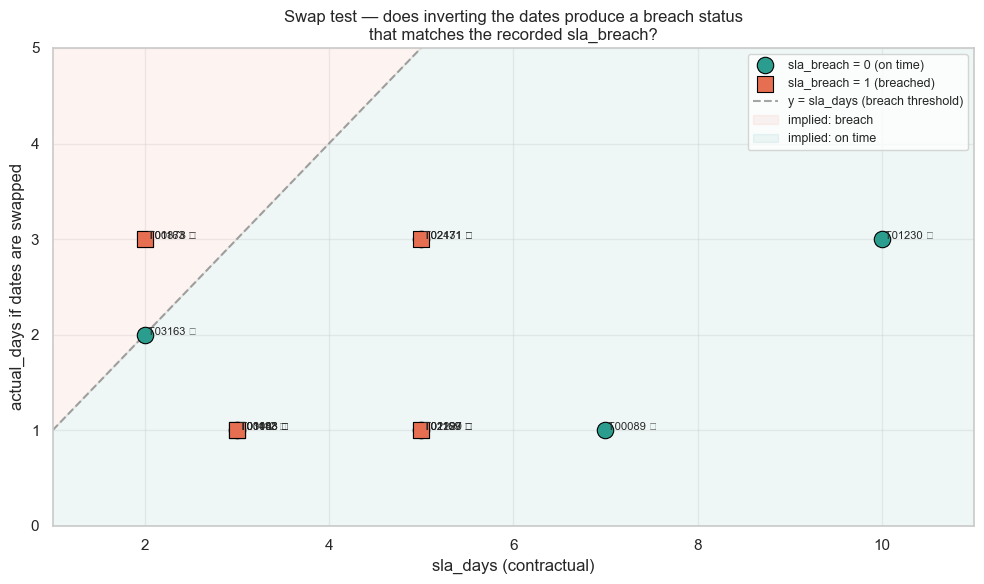

In [262]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for breach, marker, color, label in [
    (0, 'o', '#2A9D8F', 'sla_breach = 0 (on time)'),
    (1, 's', '#E76F51', 'sla_breach = 1 (breached)'),
]:
    sub = anom[anom['sla_breach'] == breach]
    ax.scatter(sub['sla_days'], sub['actual_if_swapped'],
               marker=marker, color=color, s=140, edgecolor='black',
               linewidth=0.8, label=label, zorder=3)

# Diagonal y = sla_days: above = breach expected, below = on-time expected
x_line = np.linspace(1, 11, 50)
ax.plot(x_line, x_line, linestyle='--', color='gray', alpha=0.7,
        label='y = sla_days (breach threshold)')
ax.fill_between(x_line, x_line, 12, color='#E76F51', alpha=0.08,
                label='implied: breach')
ax.fill_between(x_line, 0, x_line, color='#2A9D8F', alpha=0.08,
                label='implied: on time')

# Annotate each record
for _, row in anom.iterrows():
    ok = '✓' if row['consistent'] else '✗'
    ax.annotate(f" {row['task_id']} {ok}",
                (row['sla_days'], row['actual_if_swapped']),
                fontsize=8)

ax.set_xlabel('sla_days (contractual)')
ax.set_ylabel('actual_days if dates are swapped')
ax.set_title('Swap test — does inverting the dates produce a breach status\n'
             'that matches the recorded sla_breach?')
ax.set_xlim(1, 11)
ax.set_ylim(0, 5)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Reading the plot

Each point is one of the 14 anomalous records. The x-axis shows the contractual SLA; the y-axis shows the `actual_days` we'd get if we swapped the two dates. The diagonal line splits the plane into "implied on-time" (below) and "implied breach" (above). A point is **consistent with the swap hypothesis** when its color matches the region it lands in:

- Green circles below the diagonal → on-time implied, `sla_breach = 0` recorded ✓
- Red squares above the diagonal → breach implied, `sla_breach = 1` recorded ✓
- Red squares below the diagonal → inconsistent: the swap would produce an on-time delivery, but the record says it breached ✗

The 8 consistent records cluster correctly in their expected regions. The 6 inconsistent ones are all red squares in the green region — they claim to have breached SLA despite an implied delivery well within the contractual window. For these, the swap cannot explain what's corrupted: it could be both dates, it could be `sla_breach` itself, or the actual delivery happened after a formal one that wasn't tracked. We can't distinguish these hypotheses from the available data.

### Action

Given the two groups behave differently, we treat them differently: **swap the dates for the 8 consistent records**, **drop the 6 ambiguous ones**. Dropping six records (0.2% of the dataset) is a negligible cost compared to fabricating dates on rows where we know something structural is wrong.


In [263]:
consistent_ids   = anom.loc[ anom['consistent'], 'task_id'].values
inconsistent_ids = anom.loc[~anom['consistent'], 'task_id'].values

# 1. Swap dates for the 8 consistent records
swap_mask = df['task_id'].isin(consistent_ids)
df.loc[swap_mask, ['created_at', 'delivered_at']] = \
    df.loc[swap_mask, ['delivered_at', 'created_at']].values

# 2. Drop the 6 records that cannot be reconciled
df = df[~df['task_id'].isin(inconsistent_ids)].copy()

# 3. Verify the fix
remaining_r2 = ((df['created_at'] > df['delivered_at'])
                & df['created_at'].notna()
                & df['delivered_at'].notna()).sum()
print(f"Swapped: {len(consistent_ids)} records")
print(f"Dropped: {len(inconsistent_ids)} records")
print(f"Remaining R2 violations: {remaining_r2}")
print(f"Dataset size after date cleanup: {len(df)}")

# 4. Compute actual delivery time as a clean downstream feature
df['actual_days'] = (df['delivered_at'] - df['created_at']).dt.days
print(f"\nactual_days: min={df['actual_days'].min()}, "
      f"median={df['actual_days'].median()}, "
      f"max={df['actual_days'].max()}")



Swapped: 8 records
Dropped: 6 records
Remaining R2 violations: 0
Dataset size after date cleanup: 3193

actual_days: min=0, median=5.0, max=10


### 4.30 task_status

Current status of the task in the workflow.

In [264]:
print(f"Null values: {df['task_status'].isnull().sum()}")
print(f"Null %: {df['task_status'].isnull().mean()*100:.2f}%")
print(f"\nUnique statuses: {df['task_status'].nunique()}")
print(f"\nStatus distribution:")
print(df['task_status'].value_counts())

print(f"\n\nConsistency check with delivered_at:")
print(f"Status = 'delivered' but delivered_at is NULL:")
delivered_no_date = df[(df['task_status'] == 'delivered') & (df['delivered_at'].isnull())]
print(f"  {len(delivered_no_date)} rows ")

print(f"\nStatus ≠ 'delivered' but delivered_at is NOT NULL:")
not_delivered_has_date = df[(df['task_status'] != 'delivered') & (df['delivered_at'].notnull())]
print(f"  {len(not_delivered_has_date)} rows")

Null values: 0
Null %: 0.00%

Unique statuses: 6

Status distribution:
task_status
in_progress    1107
review          855
delivered       754
draft           179
blocked         149
archived        149
Name: count, dtype: int64


Consistency check with delivered_at:
Status = 'delivered' but delivered_at is NULL:
  0 rows 

Status ≠ 'delivered' but delivered_at is NOT NULL:
  2439 rows


### 4.31 workflow_stage

Current stage in the task workflow.

In [265]:
print(f"Null values: {df['workflow_stage'].isnull().sum()}")
print(f"\nUnique stages: {df['workflow_stage'].nunique()}")
print(f"\nStage distribution:")
print(df['workflow_stage'].value_counts())

Null values: 0

Unique stages: 5

Stage distribution:
workflow_stage
qa               680
client_review    650
finalized        636
briefing         629
execution        598
Name: count, dtype: int64


### 4.32 jira_ticket

JIRA ticket ID associated with the task.

In [266]:
print(f"Null values: {df['jira_ticket'].isnull().sum()}")
print(f"\nUnique tickets: {df['jira_ticket'].nunique()}")
print(f"\nData type: {df['jira_ticket'].dtype}")
print(f"\nSample values (first 10 non-null):")
print(df[df['jira_ticket'].notnull()]['jira_ticket'].head(10).tolist())


Null values: 331

Unique tickets: 2822

Data type: object

Sample values (first 10 non-null):
['JIRA-49014', 'JIRA-84793', 'JIRA-42485', 'JIRA-53111', 'JIRA-86006', 'JIRA-60375', 'JIRA-11083', 'JIRA-78764', 'JIRA-77681', 'JIRA-82158']


### 4.33 legacy_ai_flag

Flag indicating if the task used legacy AI tools (vs modern AI).

In [267]:
print(f"Null values: {df['legacy_ai_flag'].isnull().sum()}")

print(f"\nUnique values: {df['legacy_ai_flag'].nunique()}")
print(f"\nValue distribution:")
print(df['legacy_ai_flag'].value_counts())
print(f"\nData type: {df['legacy_ai_flag'].dtype}")

# Check relationship with ai_assisted
print(f"\n\nCross-tabulation with ai_assisted:")
print(pd.crosstab(df['legacy_ai_flag'], df['ai_assisted'], margins=True))

# AI usage % for legacy vs non-legacy
print(f"\n\nAI usage by legacy flag:")
print(df.groupby('legacy_ai_flag')['ai_usage_pct'].agg(['count', 'mean', 'median']))

Null values: 0

Unique values: 3

Value distribution:
legacy_ai_flag
false      1433
true       1425
unknown     335
Name: count, dtype: int64

Data type: object


Cross-tabulation with ai_assisted:
ai_assisted     False  True   All
legacy_ai_flag                   
false             346  1087  1433
true              314  1111  1425
unknown            74   261   335
All               734  2459  3193


AI usage by legacy flag:
                count      mean  median
legacy_ai_flag                         
false            1433  0.356821    0.34
true             1425  0.364758    0.34
unknown           335  0.363567    0.35


### 4.34 content_version

Version of the content/deliverable.

In [268]:
print(f"Null values: {df['content_version'].isnull().sum()}")
print(f"Null %: {df['content_version'].isnull().mean()*100:.2f}%")
print(f"\nUnique versions: {df['content_version'].nunique()}")
print(f"\nVersion distribution:")
print(df['content_version'].value_counts().sort_index())
print(f"\nData type: {df['content_version'].dtype}")

print(f"\n\nRelationship with revisions:")
print(df.groupby('content_version')['revisions'].agg(['count', 'mean', 'median']))

print(f"\n\nRelationship with rework_hours:")
print(df.groupby('content_version')['rework_hours'].agg(['count', 'mean', 'median']))

Null values: 0
Null %: 0.00%

Unique versions: 5

Version distribution:
content_version
final    551
v1       908
v2       768
v3       653
v4       313
Name: count, dtype: int64

Data type: object


Relationship with revisions:
                 count      mean  median
content_version                         
final              551  2.978221     3.0
v1                 908  3.091410     3.0
v2                 768  3.044271     3.0
v3                 653  2.973966     3.0
v4                 313  2.798722     3.0


Relationship with rework_hours:
                 count      mean  median
content_version                         
final              551  2.616330   1.850
v1                 908  2.329356   1.820
v2                 768  2.386289   1.835
v3                 653  2.456492   1.780
v4                 313  2.428423   1.680


-----
## 5. Feature Engineering

Now that data is clean, we create derived metrics essential for our research question: **"Beyond which AI usage threshold does rework erode operational margins?"**

These features transform raw data into business insights and enable ML modeling.

**Features to create:**
1. **profit_margin** — Core KPI: profitability per euro of revenue
2. **efficiency_ratio** — Billing efficiency: what % of work hours are billable
3. **rework_ratio** — Quality cost: what % of time is spent on rework

4. **cost_per_hour** — Operational efficiency: cost to deliver 1 hour of work
5. **revenue_per_hour** — Productivity: revenue generated per hour worked
6. **total_effort** - 
7. **profit_per_hour** - 


8. **delivery_speed** — SLA performance: actual vs expected delivery time
9. **ai_usage_bin** — Categorical binning for threshold analysis


## 5.1 Profit Margin

**Definition:** `profit_margin = profit / revenue`

Core profitability KPI: the share of revenue that becomes profit. This is the primary
target candidate for the threshold analysis on AI usage.

**Edge cases:**
- `revenue == 0` → NaN (margin undefined)
- Negative profit is preserved (loss-making tasks are a real business signal, not an error)

**Range expectation:** 0.20–0.40 for healthy tasks; negative for loss-makers (~25% of dataset, per section 4.27).

In [269]:
df['profit_margin'] = np.nan
valid_mask = df['revenue'] != 0
df.loc[valid_mask, 'profit_margin'] = (
    df.loc[valid_mask, 'profit'] / df.loc[valid_mask, 'revenue']
)

## 5.2 Efficieny Ratio

**Definition:** `efficiency_ratio = billable_hours / hours_spent`

**Business meaning:** 
- What percentage of total work hours are actually billed to clients
- Measures billing efficiency and overhead
- **Critical for research question**: Does AI increase efficiency (more billable hours) or create overhead (rework, non-billable fixes)?

**Why this matters:**
- Direct link to AI impact: Does AI reduce non-billable overhead?
- Complements profit_margin: High margin could come from efficiency OR pricing
- Enables hypothesis testing: "AI usage >X% improves billing efficiency by Y%"

In [270]:
df['efficiency_ratio'] = np.nan
valid_mask = df['hours_spent'] > 0
df.loc[valid_mask, 'efficiency_ratio'] = (
    df.loc[valid_mask, 'billable_hours'] / df.loc[valid_mask, 'hours_spent']
)

## 5.3 rework_ratio

**Definition:** `rework_ratio = rework_hours / hours_spent`

**Business meaning:** 
- What percentage of total work time is spent fixing errors and quality issues
- Direct measure of **quality cost** — wasted effort on corrections
- **CRITICAL for research question**: This is the smoking gun for "AI-induced rework erodes margins"

**Expected values:**
- Low rework: <10% (high quality, minimal corrections)
- Acceptable: 10-20% (normal iteration, client feedback)
- High rework: 20-30% (quality issues, scope misunderstanding)
- Critical: >30% (severe quality problems, project at risk)
- **Theoretical min: 0%** (perfect execution, no corrections needed)

**Why this is THE critical feature:**
- **Direct link to research question**: Does high AI usage → more rework → eroded margins?
- Connects quality (errors/revisions) to time cost (hours wasted)
- Enables causal chain testing: AI usage → rework_ratio → efficiency_ratio → profit_margin
- **This is where AI's negative impact would show** if it exists

**Expected relationship with AI usage:**
- **Hypothesis A** (AI helps): Higher AI usage → lower rework_ratio (AI catches errors early)
- **Hypothesis B** (AI hurts): Higher AI usage → higher rework_ratio (AI makes subtle errors requiring fixes)
- **Threshold hypothesis**: U-shaped curve — low AI = good, medium AI = bad (learning curve), high AI = good (mastery)

In [271]:
df['rework_ratio'] = np.nan
valid_mask = df['hours_spent'] > 0
df.loc[valid_mask, 'rework_ratio'] = (
    df.loc[valid_mask, 'rework_hours'] / df.loc[valid_mask, 'hours_spent']
)

## 5.4 cost_per_hour

**Definition:** `cost_per_hour = cost / hours_spent`

Already used as a diagnostic in section 4.17 (anomaly detection on `hours_spent`)
with population median ~58 €/h. Here we promote it to a permanent feature, useful
for segmenting tasks by operational cost intensity and for sanity-checking
`pricing_model`-driven patterns.

We compute it on `hours_spent` (not `total_effort`) to keep continuity with the
diagnostic baseline established in cleaning.

**Edge cases:** `hours_spent == 0` → NaN.

In [272]:
df['cost_per_hour'] = np.nan
mask = df['hours_spent'] > 0
df.loc[mask, 'cost_per_hour'] = df.loc[mask, 'cost'] / df.loc[mask, 'hours_spent']

print(df['cost_per_hour'].describe(percentiles=[0.05, 0.5, 0.95]).round(2))

count    3193.00
mean       62.73
std        40.68
min         8.61
5%         35.24
50%        58.10
95%        92.56
max      1200.43
Name: cost_per_hour, dtype: float64


## 5.5 revenue_per_hours 

**Definition:** `revenue_per_hour = revenue / hours_spent`

Productivity metric: euro of revenue generated per hour of work. Complements
`cost_per_hour` and together they decompose `profit_margin` along an
operational axis (revenue side vs cost side).

**Edge cases:** `hours_spent == 0` → NaN.

In [273]:
df['revenue_per_hour'] = np.nan
mask = df['hours_spent'] > 0
df.loc[mask, 'revenue_per_hour'] = df.loc[mask, 'revenue'] / df.loc[mask, 'hours_spent']

print(df['revenue_per_hour'].describe(percentiles=[0.05, 0.5, 0.95]).round(2))

count    3193.00
mean       98.70
std        81.32
min         4.50
5%         38.29
50%        81.53
95%       203.27
max      1425.35
Name: revenue_per_hour, dtype: float64


## 5.6 total_effort

**Definition:** `total_effort = hours_spent + rework_hours`

In section 3.7 we established that `hours_spent`, `billable_hours` and `rework_hours`
are **three independent compartments**: `rework_hours` is **additive**, not nested
inside `hours_spent`. The honest measure of effort actually invested in a task is
therefore the sum.

This feature is a prerequisite for `rework_share`, `profit_per_hour` and any
downstream productivity metric that should reflect the true time cost.

**Edge cases:** none — both inputs are fully imputed by section 4.

In [274]:
df['total_effort'] = df['hours_spent'] + df['rework_hours']

print(df['total_effort'].describe(percentiles=[0.05, 0.5, 0.95]).round(2))

count    3193.00
mean       14.84
std         7.14
min         3.05
5%          6.46
50%        13.46
95%        28.12
max        88.21
Name: total_effort, dtype: float64


## 5.7 profit_per_hour

**Definition:** `profit_per_hour = profit / total_effort`

True profitability per unit of effort actually invested. Computed on `total_effort`
(not `hours_spent`) because rework is unbillable time that nonetheless consumes
team capacity — ignoring it would overstate per-hour profitability on rework-heavy
tasks, which is precisely the dynamic the AI paradox predicts.

This is the cleanest target for the causal chain
`AI usage → rework → profit_per_hour`: it captures both effects (extra hours
sunk and margin compression) in a single number.

**Edge cases:** `total_effort == 0` → NaN.

In [275]:
df['profit_per_hour'] = np.nan
mask = df['total_effort'] > 0
df.loc[mask, 'profit_per_hour'] = df.loc[mask, 'profit'] / df.loc[mask, 'total_effort']

print(df['profit_per_hour'].describe(percentiles=[0.05, 0.5, 0.95]).round(2))

count    3193.00
mean       28.99
std        71.92
min      -670.98
5%        -29.12
50%        19.53
95%       116.97
max       950.40
Name: profit_per_hour, dtype: float64


## 5.8 delivery_speed

**Definitions:**
- `delivery_days_actual = (delivered_at - created_at).dt.days`
- `delivery_speed = delivery_days_actual / sla_days`

**Interpretation:**
- `< 1` → delivered faster than SLA
- `= 1` → on time
- `> 1` → SLA breach (should align with `sla_breach == 1`)

After the swap-test in section 4.29, all surviving date pairs satisfy
`delivered_at >= created_at`, so `delivery_days_actual` is non-negative by
construction. `sla_days` was cleaned in section 4.15, but we guard for zero
defensively.

**Edge cases:** missing dates or `sla_days == 0` → NaN.

In [276]:
# Ensure datetime dtype (idempotent — safe even if already converted)
df['created_at']   = pd.to_datetime(df['created_at'])
df['delivered_at'] = pd.to_datetime(df['delivered_at'])

# 1) Actual delivery time in days
df['delivery_days_actual'] = (df['delivered_at'] - df['created_at']).dt.days

# 2) Delivery speed: actual vs SLA
df['delivery_speed'] = np.nan
mask = (df['sla_days'] > 0) & df['delivery_days_actual'].notna()
df.loc[mask, 'delivery_speed'] = (
    df.loc[mask, 'delivery_days_actual'] / df.loc[mask, 'sla_days']
)

# Distribution summary
print("delivery_days_actual:")
print(df['delivery_days_actual'].describe(percentiles=[0.05, 0.5, 0.95]).round(2))
print("\ndelivery_speed:")
print(df['delivery_speed'].describe(percentiles=[0.05, 0.5, 0.95]).round(3))

# Sanity check: delivery_speed > 1 should align with sla_breach == 1
print("\nConsistency check (delivery_speed > 1 vs sla_breach):")
print(pd.crosstab(df['sla_breach'], df['delivery_speed'] > 1, margins=True))

delivery_days_actual:
count    3193.00
mean        4.51
std         1.77
min         0.00
5%          2.00
50%         5.00
95%         7.00
max        10.00
Name: delivery_days_actual, dtype: float64

delivery_speed:
count    3193.000
mean        1.166
std         0.790
min         0.000
5%          0.294
50%         1.000
95%         3.000
max         5.000
Name: delivery_speed, dtype: float64

Consistency check (delivery_speed > 1 vs sla_breach):
delivery_speed  False  True   All
sla_breach                       
0                1929     0  1929
1                  12  1252  1264
All              1941  1252  3193


## 5.9 ai_usage_bin

**Definition:** business-driven binning of `ai_usage_pct` into 5 bands aligned with
Alkemy's operational interpretation of AI involvement:

| Bin              | Range      | Interpretation                                                |
|------------------|------------|---------------------------------------------------------------|
| `low`            | [0, 20)    | Minimal AI — system flags task as `ai_assisted = False`       |
| `low_medium`     | [20, 40)   | Light AI usage                                                |
| `medium_high`    | [40, 60)   | Moderate AI usage                                             |
| `high`           | [60, 80)   | Heavy AI usage                                                |
| `very_high`      | [80, 100]  | AI-dominant workflow                                          |

**Why fixed bands instead of quartiles.**  
The 20% threshold has a hard system-level meaning (`ai_assisted = False` below it),
so it cannot be merged with neighbouring values into an arbitrary quartile edge.
A sample-driven binning would mix structurally non-AI tasks with light-AI tasks
and obscure exactly the threshold dynamic the research question is about.

**Boundary convention:** intervals are **left-closed, right-open** `[a, b)` except
the last one which is closed `[80, 100]` so that 100% maps to `very_high`.

**Sanity check.** Before binning, we verify that the system rule
`ai_usage_pct < 20% ⇔ ai_assisted == False` holds in the data. Violations would
indicate either upstream data inconsistency or that the rule is softer than stated.

In [277]:
# --- Sanity check: verify the system rule before binning ---
below_20 = df['ai_usage_pct'] < 0.20
above_20 = df['ai_usage_pct'] >= 0.20

violations_below = ((below_20) & (df['ai_assisted'] == True)).sum()
violations_above = ((above_20) & (df['ai_assisted'] == False)).sum()

print("System rule check: ai_usage_pct < 20%  ⇔  ai_assisted == False")
print(f"  Records with ai_usage_pct <  20% but ai_assisted = True : {violations_below}")
print(f"  Records with ai_usage_pct >= 20% but ai_assisted = False: {violations_above}")
print(f"\nCrosstab (ai_assisted × below_20_threshold):")
print(pd.crosstab(df['ai_assisted'], below_20, margins=True))

System rule check: ai_usage_pct < 20%  ⇔  ai_assisted == False
  Records with ai_usage_pct <  20% but ai_assisted = True : 0
  Records with ai_usage_pct >= 20% but ai_assisted = False: 0

Crosstab (ai_assisted × below_20_threshold):
ai_usage_pct  False  True   All
ai_assisted                    
False             0   734   734
True           2459     0  2459
All            2459   734  3193


In [278]:
# --- Build the binning ---
ai_bin_edges  = [0, 0.20, 0.40, 0.60, 0.80, 100]
ai_bin_labels = ['low', 'low_medium', 'medium_high', 'high', 'very_high']

df['ai_usage_bin'] = pd.cut(
    df['ai_usage_pct'],
    bins=ai_bin_edges,
    labels=ai_bin_labels,
    right=False,             # left-closed, right-open: [a, b)
    include_lowest=True      # include 0 in the first bin
)

# Patch: pd.cut with right=False excludes the upper boundary 100 from the last bin.
# We want 100% to fall into 'very_high', so we reassign it explicitly.
df.loc[df['ai_usage_pct'] == 100, 'ai_usage_bin'] = 'very_high'

# Distribution
print("Bin distribution:")
print(df['ai_usage_bin'].value_counts().sort_index())
print(f"\nTotal binned: {df['ai_usage_bin'].notna().sum()} / {len(df)}")

# Per-bin summary stats on the underlying numeric variable (consistency check)
print("\nai_usage_pct stats per bin:")
print(df.groupby('ai_usage_bin', observed=True)['ai_usage_pct']
        .agg(['min', 'median', 'max', 'count']).round(2))

Bin distribution:
ai_usage_bin
low             734
low_medium     1151
medium_high     882
high            369
very_high        57
Name: count, dtype: int64

Total binned: 3193 / 3193

ai_usage_pct stats per bin:
              min  median   max  count
ai_usage_bin                          
low           0.0    0.12  0.20    734
low_medium    0.2    0.29  0.40   1151
medium_high   0.4    0.49  0.59    882
high          0.6    0.67  0.79    369
very_high     0.8    0.83  0.93     57


In [279]:
# Export to CSV
output_path = 'ai_productivity_clean.csv'
df.to_csv(output_path, index=False)

print(f"✓ Dataset exported successfully")
print(f"  Location: {output_path}")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")


✓ Dataset exported successfully
  Location: ai_productivity_clean.csv
  Shape: 3193 rows × 45 columns


--------

-----
# 6. Pre-Modeling Analysis: Answering Alkemy's Three Questions

Before fitting predictive models, we use descriptive and bivariate analysis to address the three advanced questions Alkemy posed in the project brief:

1. **Speed vs Quality Trade-off** — *At what point does speed begin to compromise perceived quality?*
2. **Rework Threshold** — *What is the level beyond which rework destroys the operating margin?*
3. **Hourly Sustainability** — *When does the hourly model become unsustainable?*

Each question is addressed in its own subsection. The structure within each is:

- **Setup** — what the question is asking and which features answer it
- **Evidence** — the analyses we run with their outputs
- **Answer** — a direct, evidence-anchored response

The modeling phase (Section 7) will quantify and validate; the answers below are already supported by the data.

**Statistical conventions used throughout.** We default to **medians** rather than means (distributions are skewed and outlier-prone), to **Spearman** rather than Pearson correlations (relationships are likely monotonic but not necessarily linear), and to **Mann-Whitney U** for group comparisons. AI usage is binned into business-meaningful bands (`low`, `low_medium`, `medium_high`, `high`, `very_high`) defined in section 5.

After answering the three questions, **Section 6.4** synthesizes the findings into the deliverable Alkemy requires: three key insights, one concrete decision, and the methodology hand-off to modeling.

## 6.1 Question 1 — Speed vs Quality Trade-off

> **"At what point does speed begin to compromise perceived quality?"**

The question implies a relationship where AI accelerates delivery but degrades output quality (proxied through `rework_ratio`). To answer it we need three views:

- **6.1.1** — How `delivery_speed`, `rework_ratio` and `profit_margin` move together across AI usage bins
- **6.1.2** — Whether the speed gain is real once rework is included (`total_effort` decomposition)
- **6.1.3** — How the supporting KPIs (revenue_per_hour, cost_per_hour, efficiency_ratio) behave
- **6.1.4** — Whether the bin-to-bin shifts are statistically significant
- **6.1.5** — Direct answer

Before segmenting, we briefly characterize the target variable (`profit_margin`) so the rest of the analysis has a baseline.

### 6.1.1 Baseline: distribution of profit_margin

**Why here.** Before asking how AI moves the margin, we look at what the margin distribution looks like overall. The shape of the margin distribution sets the context for every comparison that follows.

We plot the histogram of `profit_margin` with reference lines at break-even and median, and split the dataset into four business-interpretable buckets (Loss, Marginal, Healthy, Strong).

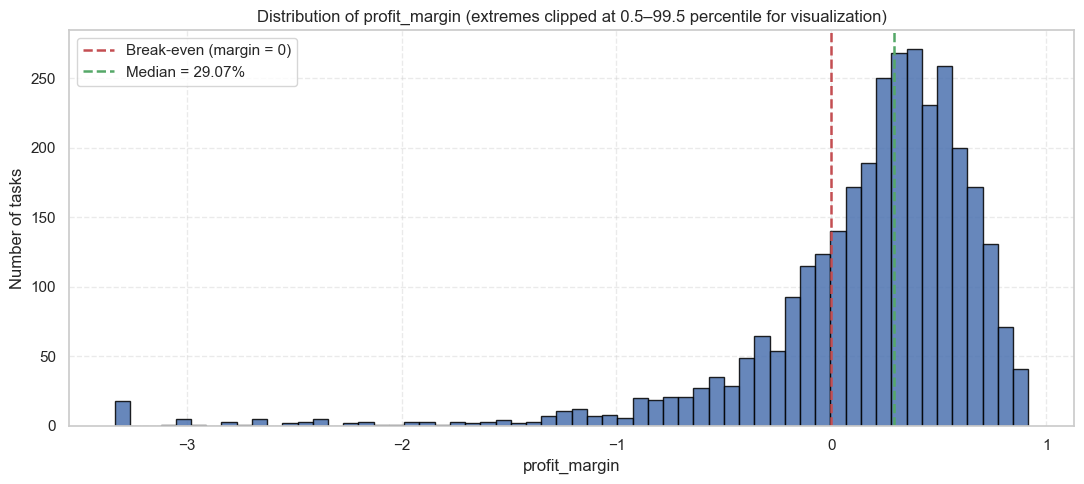

profit_margin — full-sample summary:
count    3193.0000
mean        0.1476
std         0.7683
min       -16.7368
1%         -2.6648
5%         -0.8114
25%        -0.0042
50%         0.2907
75%         0.5111
95%         0.7459
99%         0.8697
max         0.9626
Name: profit_margin, dtype: float64

Business-bucket breakdown:
                  count  share
profit_margin                 
Loss (<0)           802  25.1%
Marginal (0-10%)    221   6.9%
Healthy (10-30%)    604  18.9%
Strong (≥30%)      1566  49.0%

NaN profit_margin: 0 (revenue == 0)


In [280]:
# ---------------------------------------------------------------
# 6.1 — Distribution of profit_margin
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

# Clip extreme tails for plotting only (does not affect the data)
plot_data = df['profit_margin'].dropna()
xmin, xmax = plot_data.quantile([0.005, 0.995])

ax.hist(plot_data.clip(xmin, xmax), bins=60, edgecolor='black',
        color='#4C72B0', alpha=0.85)

# Reference lines
median_val = plot_data.median()
ax.axvline(0, color='#C44E52', linestyle='--', linewidth=1.8,
           label=f'Break-even (margin = 0)')
ax.axvline(median_val, color='#55A868', linestyle='--', linewidth=1.8,
           label=f'Median = {median_val:.2%}')

ax.set_xlabel('profit_margin')
ax.set_ylabel('Number of tasks')
ax.set_title('Distribution of profit_margin (extremes clipped at 0.5–99.5 percentile for visualization)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Summary statistics on the unclipped data
print("profit_margin — full-sample summary:")
print(df['profit_margin'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4))

# Business-interpretable buckets
buckets = pd.cut(
    df['profit_margin'],
    bins=[-np.inf, 0, 0.10, 0.30, np.inf],
    labels=['Loss (<0)', 'Marginal (0-10%)', 'Healthy (10-30%)', 'Strong (≥30%)']
)
bucket_summary = pd.DataFrame({
    'count': buckets.value_counts().sort_index(),
    'share': (buckets.value_counts(normalize=True).sort_index() * 100).round(1)
})
bucket_summary['share'] = bucket_summary['share'].astype(str) + '%'

print("\nBusiness-bucket breakdown:")
print(bucket_summary)

print(f"\nNaN profit_margin: {df['profit_margin'].isna().sum()} (revenue == 0)")

**Reading 6.1.1.**

The picture is **bipolar**, not uniformly distressed.

- **Median margin = 29.1%**, healthy for a digital agency
- **49% of tasks are Strong** (≥30%), **18.9% Healthy** (10–30%) → ~68% of work is firmly profitable
- **25.1% are in Loss**, only 6.9% Marginal — losses are not concentrated near zero, the negative tail extends to -16.7

There isn't a single "broken process" dragging everything down. Two populations coexist: a profitable majority and a 25% loss-making minority. The right question is *what separates them?* — and AI usage is one of the candidate explanations to test in 6.1.2 onwards.

---
### 6.1.2 Speed, quality and margin across AI usage bins

The first view of the trade-off: three boxplots side-by-side, one for each axis of the question.

- `delivery_speed` — does AI accelerate delivery? (lower = faster vs SLA)
- `rework_ratio` — does AI generate more rework? (higher = more correction work)
- `profit_margin` — does the speed gain translate into margin?

If the speed-quality trade-off is real, we expect `delivery_speed` to drop and `rework_ratio` to rise across bins. Whether `profit_margin` follows tells us whether the trade-off has a financial cost.

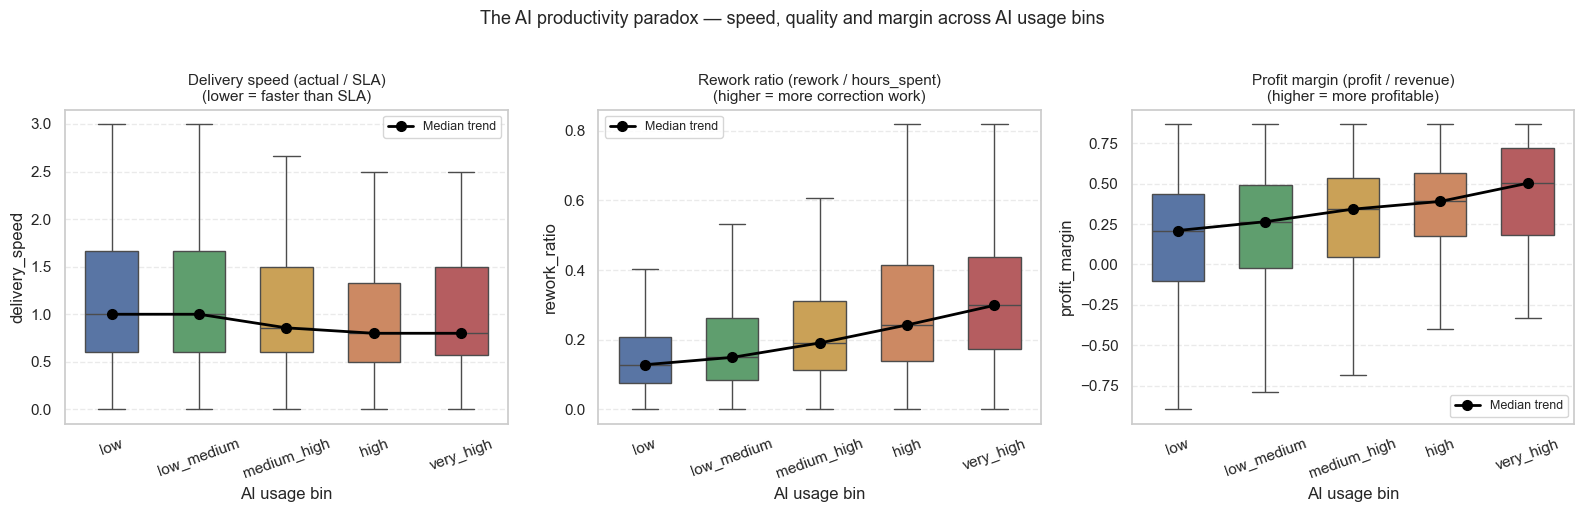

Median values by AI usage bin:
              delivery_speed  rework_ratio  profit_margin  n_tasks
ai_usage_bin                                                      
low                    1.000         0.128          0.210      734
low_medium             1.000         0.149          0.265     1151
medium_high            0.857         0.191          0.342      882
high                   0.800         0.242          0.390      369
very_high              0.800         0.299          0.502       57


In [281]:
# ---------------------------------------------------------------
# 6.2 — The paradox in one picture: speed, quality, margin × AI bin
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bin_order = ['low', 'low_medium', 'medium_high', 'high', 'very_high']
palette = ['#4C72B0', '#55A868', '#DDA744', '#DD8452', '#C44E52']

panels = [
    ('delivery_speed', 'Delivery speed (actual / SLA)', 'lower = faster than SLA'),
    ('rework_ratio',   'Rework ratio (rework / hours_spent)', 'higher = more correction work'),
    ('profit_margin',  'Profit margin (profit / revenue)', 'higher = more profitable'),
]

for ax, (col, title, subtitle) in zip(axes, panels):
    # Clip extremes for readability (does not affect data)
    plot_df = df[[col, 'ai_usage_bin']].dropna()
    lo, hi = plot_df[col].quantile([0.01, 0.99])
    plot_df[col] = plot_df[col].clip(lo, hi)

    sns.boxplot(data=plot_df, x='ai_usage_bin', y=col, order=bin_order,
                palette=palette, ax=ax, showfliers=False, width=0.6)

    # Overlay the median trend line connecting bin medians
    medians = plot_df.groupby('ai_usage_bin', observed=True)[col].median().reindex(bin_order)
    ax.plot(range(len(bin_order)), medians.values,
            color='black', marker='o', linewidth=2, markersize=7,
            label='Median trend', zorder=10)

    ax.set_title(f'{title}\n({subtitle})', fontsize=11)
    ax.set_xlabel('AI usage bin')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=9)

plt.suptitle('The AI productivity paradox — speed, quality and margin across AI usage bins',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Numeric companion: medians per bin for the three metrics
summary = (df.groupby('ai_usage_bin', observed=True)[['delivery_speed', 'rework_ratio', 'profit_margin']]
             .median().reindex(bin_order).round(3))
summary['n_tasks'] = df.groupby('ai_usage_bin', observed=True).size().reindex(bin_order)

print("Median values by AI usage bin:")
print(summary)

**Reading 6.1.2.**

| Metric | Trend (low → very_high) |
|---|---|
| delivery_speed | 1.00 → 0.80 (-20%) |
| rework_ratio | 0.13 → 0.30 (+134%) |
| profit_margin | 0.21 → 0.50 (+139%) |

Speed and rework move as the brief expected: AI-heavy tasks deliver ~20% faster but accumulate 2.3× more rework. **The trade-off mechanism exists.** What contradicts the brief: profit_margin rises monotonically with AI bins. The trade-off doesn't compromise margin at the aggregate level.

This shifts the interpretation of Question 1: speed begins to compromise quality (rework) immediately and progressively from `low_medium` onward, but the financial impact is invisible in aggregate margin. The crossover point — where quality cost actually cancels speed gain — has to be measured in **time**, not money. That's what 6.1.3 does.

---
### 6.1.3 Is the time saving real? Total effort across AI bins

`delivery_speed` measures calendar time; it says nothing about person-hours. A task delivered in half the calendar days can still cost the same effort if rework follows. Here we decompose `total_effort = hours_spent + rework_hours` to see whether AI saves person-hours when rework is included.

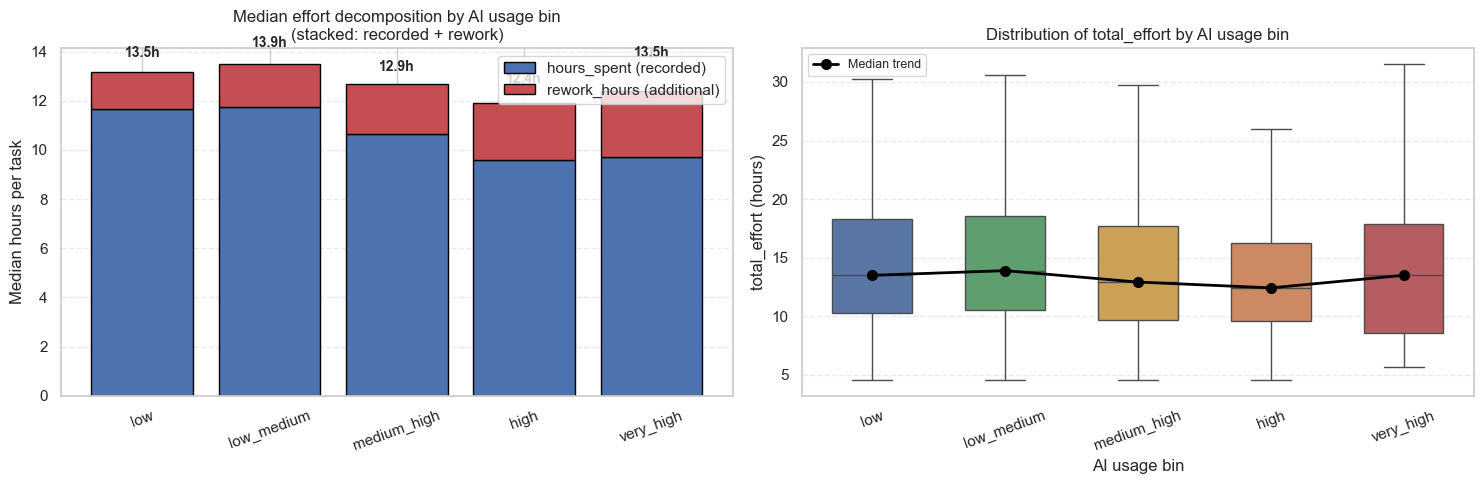

Median effort decomposition by AI usage bin:
              hours_spent  rework_hours  total_effort  n_tasks
ai_usage_bin                                                  
low                 11.68          1.51         13.50      734
low_medium          11.76          1.72         13.90     1151
medium_high         10.66          2.04         12.92      882
high                 9.60          2.32         12.43      369
very_high            9.70          2.70         13.50       57

Change vs 'low' baseline (%):
             hours_spent rework_hours total_effort
ai_usage_bin                                      
low                 0.0%         0.0%         0.0%
low_medium          0.7%        13.9%         3.0%
medium_high        -8.7%        35.1%        -4.3%
high              -17.8%        53.6%        -7.9%
very_high         -17.0%        78.8%         0.0%


In [282]:
# ---------------------------------------------------------------
# 6.3 — Is the time saving real? Total effort by AI usage bin
# ---------------------------------------------------------------

bin_order = ['low', 'low_medium', 'medium_high', 'high', 'very_high']

# Median values by bin
effort_summary = (
    df.groupby('ai_usage_bin', observed=True)[['hours_spent', 'rework_hours', 'total_effort']]
      .median()
      .reindex(bin_order)
      .round(2)
)
effort_summary['n_tasks'] = df.groupby('ai_usage_bin', observed=True).size().reindex(bin_order)

# --- Plot 1: stacked bars (hours_spent + rework_hours = total_effort) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
x = np.arange(len(bin_order))
ax.bar(x, effort_summary['hours_spent'], label='hours_spent (recorded)',
       color='#4C72B0', edgecolor='black')
ax.bar(x, effort_summary['rework_hours'], bottom=effort_summary['hours_spent'],
       label='rework_hours (additional)', color='#C44E52', edgecolor='black')

# Annotate total_effort on top of each stacked bar
for i, total in enumerate(effort_summary['total_effort']):
    ax.text(i, total + 0.3, f'{total:.1f}h', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(bin_order, rotation=20)
ax.set_ylabel('Median hours per task')
ax.set_title('Median effort decomposition by AI usage bin\n(stacked: recorded + rework)')
ax.legend(loc='upper right')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

# --- Plot 2: boxplot of total_effort distribution by bin ---
ax = axes[1]
plot_df = df[['total_effort', 'ai_usage_bin']].dropna()
lo, hi = plot_df['total_effort'].quantile([0.01, 0.99])
plot_df['total_effort'] = plot_df['total_effort'].clip(lo, hi)

palette = ['#4C72B0', '#55A868', '#DDA744', '#DD8452', '#C44E52']
sns.boxplot(data=plot_df, x='ai_usage_bin', y='total_effort',
            order=bin_order, palette=palette, ax=ax,
            showfliers=False, width=0.6)

medians = plot_df.groupby('ai_usage_bin', observed=True)['total_effort'].median().reindex(bin_order)
ax.plot(range(len(bin_order)), medians.values,
        color='black', marker='o', linewidth=2, markersize=7,
        label='Median trend', zorder=10)

ax.set_xlabel('AI usage bin')
ax.set_ylabel('total_effort (hours)')
ax.set_title('Distribution of total_effort by AI usage bin')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

# Numeric companion
print("Median effort decomposition by AI usage bin:")
print(effort_summary)

# Percentage change vs the 'low' baseline
baseline = effort_summary.loc['low']
delta_pct = ((effort_summary[['hours_spent', 'rework_hours', 'total_effort']] / baseline[['hours_spent', 'rework_hours', 'total_effort']]) - 1) * 100
print("\nChange vs 'low' baseline (%):")
print(delta_pct.round(1).astype(str) + '%')

**Reading 6.1.3.**

The time saving is **partial and bin-dependent**.

| AI bin | hours_spent vs low | rework_hours vs low | total_effort vs low |
|---|---|---|---|
| low_medium | +0.7% | +13.9% | +3.0% |
| medium_high | -8.7% | +35.1% | -4.3% |
| high | -17.8% | +53.6% | **-7.9%** |
| very_high | -17.0% | +78.8% | **0.0%** |

Three regimes:

1. **`low → low_medium`**: rework rises (+14%) but hours_spent doesn't drop yet — adding a bit of AI just adds friction
2. **`medium_high → high`**: AI sweet spot — 4-8% real time saving
3. **`very_high`**: rework (+79%) fully cancels the hours_spent reduction — total effort returns to baseline

**This is the answer to Question 1.** The crossover where speed begins to compromise quality in a financially meaningful sense is at **`very_high` AI usage (≥80%)**. Below that, the company genuinely captures time savings despite rising rework. Above it, the hidden time cost wipes out the gain.

-----
### 6.1.4 KPI decomposition: where does the gain come from?

If margin keeps rising while total_effort plateaus, the gain has to come from one of two sources: higher revenue per hour or lower cost per hour. We decompose all five engineered KPIs across AI bins, normalized to the `low` baseline.

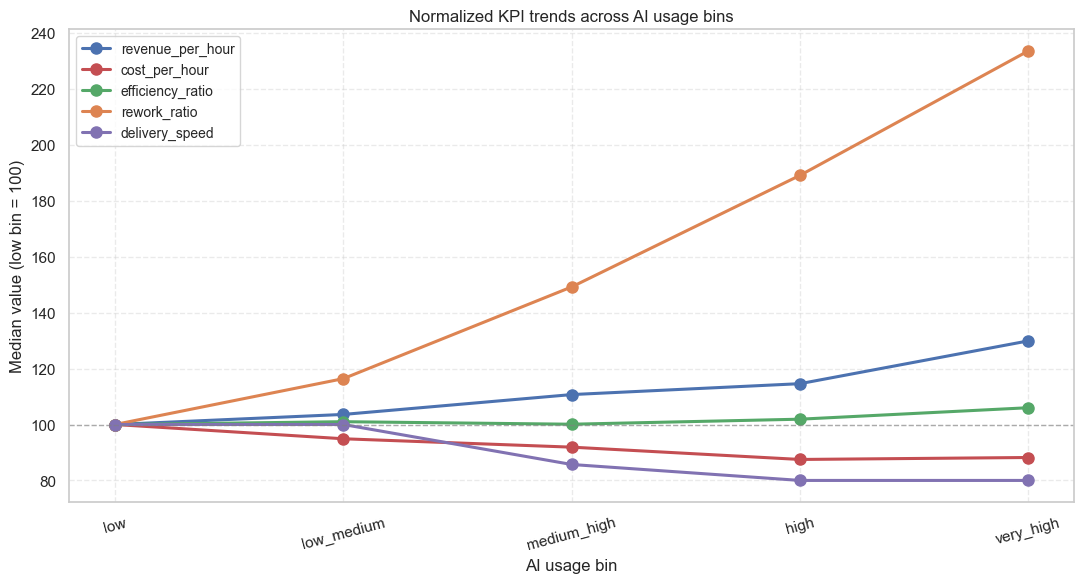

Median values by AI usage bin (raw units):
              revenue_per_hour  cost_per_hour  efficiency_ratio  rework_ratio  \
ai_usage_bin                                                                    
low                     76.722         61.683             0.687         0.128   
low_medium              79.518         58.521             0.694         0.149   
medium_high             84.916         56.699             0.688         0.191   
high                    87.893         53.970             0.700         0.242   
very_high               99.651         54.434             0.728         0.299   

              delivery_speed  
ai_usage_bin                  
low                    1.000  
low_medium             1.000  
medium_high            0.857  
high                   0.800  
very_high              0.800  

Normalized to 'low' baseline (=100):
              revenue_per_hour  cost_per_hour  efficiency_ratio  rework_ratio  \
ai_usage_bin                                         

In [283]:
# ---------------------------------------------------------------
# 6.5 — Median trends across all KPIs by AI usage bin
# ---------------------------------------------------------------

bin_order = ['low', 'low_medium', 'medium_high', 'high', 'very_high']

kpis = ['revenue_per_hour', 'cost_per_hour', 'efficiency_ratio',
        'rework_ratio', 'delivery_speed']

# Median per bin
medians = (df.groupby('ai_usage_bin', observed=True)[kpis]
             .median()
             .reindex(bin_order)
             .round(3))

# Normalize to the 'low' baseline (=100) for visual comparison
normalized = (medians / medians.loc['low'] * 100).round(1)

# --- Plot: normalized median trends ---
fig, ax = plt.subplots(figsize=(11, 6))

colors = {
    'revenue_per_hour':  '#4C72B0',
    'cost_per_hour':     '#C44E52',
    'efficiency_ratio':  '#55A868',
    'rework_ratio':      '#DD8452',
    'delivery_speed':    '#8172B2',
}

for kpi in kpis:
    ax.plot(bin_order, normalized[kpi], marker='o', linewidth=2.2,
            markersize=8, label=kpi, color=colors[kpi])

ax.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('AI usage bin')
ax.set_ylabel('Median value (low bin = 100)')
ax.set_title('Normalized KPI trends across AI usage bins')
ax.legend(loc='best', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Numeric companion
print("Median values by AI usage bin (raw units):")
print(medians)

print("\nNormalized to 'low' baseline (=100):")
print(normalized)

# Highlight the revenue vs cost contribution
print("\nRevenue vs cost decomposition (% change vs low):")
decomp = pd.DataFrame({
    'revenue_per_hour_change_%': (medians['revenue_per_hour'] / medians.loc['low', 'revenue_per_hour'] - 1) * 100,
    'cost_per_hour_change_%':    (medians['cost_per_hour']    / medians.loc['low', 'cost_per_hour']    - 1) * 100,
}).round(1)
print(decomp)

**Reading 6.1.4.**

| KPI (vs low) | low_med | med_high | high | very_high |
|---|---|---|---|---|
| revenue_per_hour | +4% | +11% | +15% | **+30%** |
| cost_per_hour | -5% | -8% | -13% | -12% |
| efficiency_ratio | flat | flat | flat | flat |
| rework_ratio | +16% | +49% | +89% | **+134%** |
| delivery_speed | flat | -14% | -20% | -20% |

Two findings.

- **Both sides of the equation contribute, revenue more than cost.** At very_high, revenue per hour is +30% and cost per hour is -12%. The profit gain is roughly 2/3 revenue-driven, 1/3 cost-driven.
- **`efficiency_ratio` is flat across all bins.** The share of billable hours doesn't shift with AI — billing tracks working hours regardless of AI intensity. The aggregate hourly-pricing concern is not visible here; we'll re-examine it under pricing segmentation in 6.3.

-----
### 6.1.5 Are the trends statistically significant?

The medians move smoothly, but with sample sizes ranging from 57 (`very_high`) to 1,151 (`low_medium`), some bin-to-bin shifts may be noise. Mann-Whitney U tests on adjacent bins for the three core metrics tell us which transitions are reliable.

In [284]:
# ---------------------------------------------------------------
# 6.5 — Mann-Whitney tests between adjacent AI bins
# ---------------------------------------------------------------
from scipy.stats import mannwhitneyu

bin_order = ['low', 'low_medium', 'medium_high', 'high', 'very_high']
metrics = ['profit_margin', 'profit_per_hour', 'rework_ratio']

def rank_biserial(u, n1, n2):
    """Rank-biserial correlation as effect size for Mann-Whitney U."""
    return 1 - (2 * u) / (n1 * n2)

def effect_label(r):
    a = abs(r)
    if a < 0.1: return 'negligible'
    if a < 0.3: return 'small'
    if a < 0.5: return 'medium'
    return 'large'

results = []
for metric in metrics:
    for i in range(len(bin_order) - 1):
        b1, b2 = bin_order[i], bin_order[i + 1]
        x = df.loc[df['ai_usage_bin'] == b1, metric].dropna()
        y = df.loc[df['ai_usage_bin'] == b2, metric].dropna()

        u_stat, p_val = mannwhitneyu(x, y, alternative='two-sided')
        r = rank_biserial(u_stat, len(x), len(y))

        results.append({
            'metric': metric,
            'comparison': f'{b1} → {b2}',
            'n1': len(x),
            'n2': len(y),
            'median_1': round(x.median(), 3),
            'median_2': round(y.median(), 3),
            'p_value': p_val,
            'significant': p_val < 0.05,
            'effect_size_r': round(r, 3),
            'effect': effect_label(r),
        })

results_df = pd.DataFrame(results)

# Format p-values for readability
results_df['p_value'] = results_df['p_value'].apply(
    lambda p: f'{p:.4f}' if p >= 0.0001 else f'{p:.2e}'
)

print("Mann-Whitney U tests on adjacent AI bins:\n")
for metric in metrics:
    print(f"--- {metric} ---")
    print(results_df[results_df['metric'] == metric]
          .drop(columns='metric')
          .to_string(index=False))
    print()

Mann-Whitney U tests on adjacent AI bins:

--- profit_margin ---
              comparison   n1   n2  median_1  median_2  p_value  significant  effect_size_r     effect
        low → low_medium  734 1151     0.210     0.265   0.0022         True          0.083 negligible
low_medium → medium_high 1151  882     0.265     0.342 1.01e-05         True          0.114      small
      medium_high → high  882  369     0.342     0.390   0.0205         True          0.083 negligible
        high → very_high  369   57     0.390     0.502   0.0571        False          0.157      small

--- profit_per_hour ---
              comparison   n1   n2  median_1  median_2  p_value  significant  effect_size_r     effect
        low → low_medium  734 1151    13.083    17.880   0.0057         True          0.075 negligible
low_medium → medium_high 1151  882    17.880    23.518 7.40e-05         True          0.102      small
      medium_high → high  882  369    23.518    25.488   0.0852        False          

**Reading 6.1.5.**

The trends are real but with uniformly **small effect sizes**. AI bin alone explains a small share of variance.

- The **`low_medium → medium_high`** transition is significant on every metric (largest effect r ≈ 0.10–0.14) — this is where the AI gain visibly kicks in
- The **`very_high` jump is fragile**: profit_margin (p=0.057) and rework_ratio (p=0.165) are not significant. The +112bp margin lift at very_high rests on n=57 and is mostly noise

**Implication:** the operationally meaningful transition is **40-60% AI usage**, not 80%+. Section 6.3 will test whether segmentation surfaces stronger effects.

### 6.1.6 Answer to Question 1

**Speed begins to compromise quality immediately** — `rework_ratio` rises from the `low_medium` bin onward — but the financial cost only materializes at **very_high AI usage (≥80%)**.

| AI usage | Speed vs SLA | Rework cost | Net effect on team time |
|---|---|---|---|
| low–low_medium | unchanged | +14% | mild loss (+3% effort) |
| medium_high–high | -14% to -20% | +35% to +54% | **real saving** (-4% to -8% effort) |
| very_high | -20% | +79% | gain cancelled (0% effort) |

The trade-off is graceful through the middle of the curve and breaks at very_high. Below 80% AI usage, the speed gain dominates; above, rework eats it entirely.

**Caveat.** This conclusion is based on aggregate medians. The `very_high` bin (n=57) is small and the magnitude has wide uncertainty. The qualitative direction (effort saving disappears) holds; the precise crossover point will be sharpened by modeling in Section 7.

---- 
## 6.2 Question 2 — Rework Threshold

> **"What is the level beyond which rework destroys the operating margin?"**

The question implies a causal chain: more rework → less margin. To answer it directly we need to test the chain explicitly, not infer it from the AI-margin trend.

- **6.2.1** — Direct correlation between `rework_ratio` and profitability (the missing link)
- **6.2.2** — Profitability across AI bins under both accounting (`profit_margin`) and capacity (`profit_per_hour`) views
- **6.2.3** — Direct answer

### 6.2.1 Does rework correlate with profitability?

If rework destroys margin, we expect a negative relationship: tasks with higher `rework_ratio` should have lower `profit_margin` and lower `profit_per_hour`. We test both with Spearman correlation and visualize with hexbin + LOWESS to detect non-linearity.

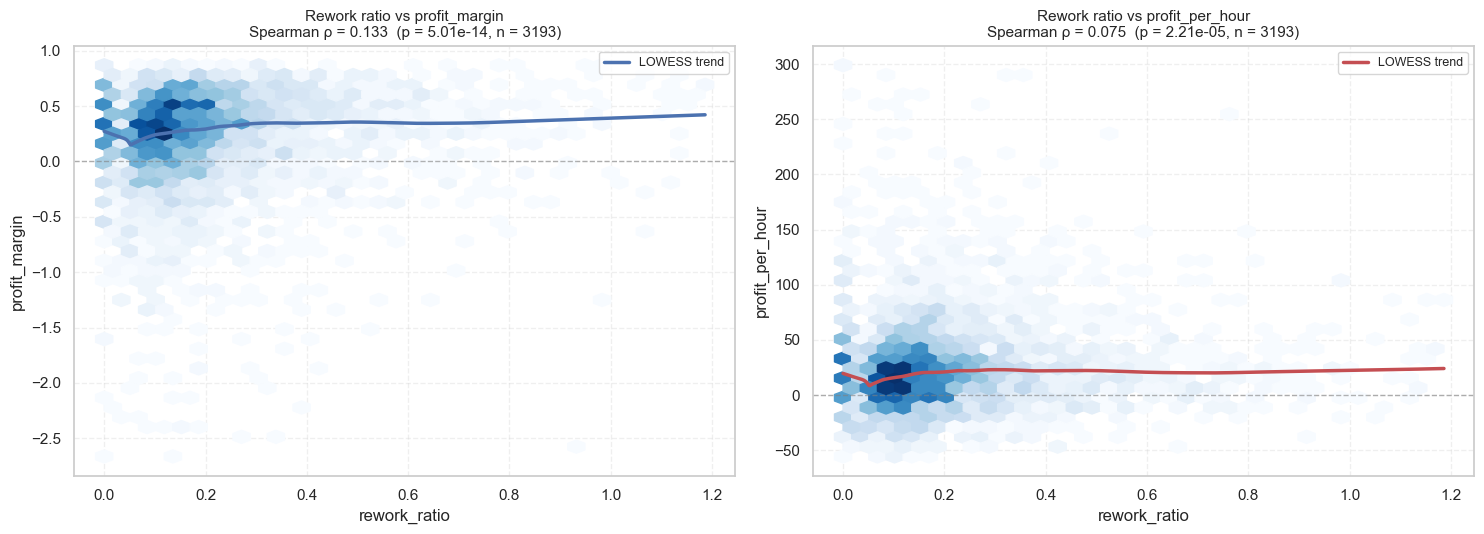

Median profitability by rework_ratio quintile:
                 rework_range  profit_margin  profit_per_hour    n
rework_quintile                                                   
Q1 (lowest)      [0.00, 0.08]          0.226           15.692  639
Q2               [0.08, 0.13]          0.253           18.002  638
Q3               [0.13, 0.20]          0.284           20.290  639
Q4               [0.20, 0.33]          0.333           23.713  638
Q5 (highest)     [0.33, 6.79]          0.369           20.801  639


In [285]:
# ---------------------------------------------------------------
#  — Rework vs profitability: closing the chain
# ---------------------------------------------------------------
from scipy.stats import spearmanr
import statsmodels.api as sm

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

panels = [
    ('profit_margin',   'Rework ratio vs profit_margin',   '#4C72B0'),
    ('profit_per_hour', 'Rework ratio vs profit_per_hour', '#C44E52'),
]

for ax, (target, title, color) in zip(axes, panels):
    plot_df = df[['rework_ratio', target]].dropna()

    # Clip extremes for visualization (does not affect correlation)
    x_lo, x_hi = plot_df['rework_ratio'].quantile([0.01, 0.99])
    y_lo, y_hi = plot_df[target].quantile([0.01, 0.99])
    vis = plot_df[
        (plot_df['rework_ratio'].between(x_lo, x_hi)) &
        (plot_df[target].between(y_lo, y_hi))
    ]

    # Hexbin to handle the dense scatter
    hb = ax.hexbin(vis['rework_ratio'], vis[target],
                   gridsize=35, cmap='Blues', mincnt=1)

    # LOWESS trend line on the visible range
    smoothed = sm.nonparametric.lowess(vis[target], vis['rework_ratio'], frac=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color=color, linewidth=2.5,
            label='LOWESS trend')

    # Reference horizontal line at break-even (margin) or 0 (profit/hour)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)

    # Spearman correlation on the unclipped data
    rho, p_val = spearmanr(plot_df['rework_ratio'], plot_df[target])
    ax.set_title(f'{title}\nSpearman ρ = {rho:.3f}  (p = {p_val:.2e}, n = {len(plot_df)})',
                 fontsize=11)
    ax.set_xlabel('rework_ratio')
    ax.set_ylabel(target)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Numeric companion: profitability across rework_ratio bins ---
rework_bins = pd.qcut(df['rework_ratio'], q=5, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])

summary = (
    df.assign(rework_quintile=rework_bins)
      .groupby('rework_quintile', observed=True)[['profit_margin', 'profit_per_hour']]
      .median()
      .round(3)
)
summary['n'] = df.groupby(rework_bins, observed=True).size()
summary['rework_range'] = (
    df.groupby(rework_bins, observed=True)['rework_ratio']
      .agg(lambda s: f'[{s.min():.2f}, {s.max():.2f}]')
)

print("Median profitability by rework_ratio quintile:")
print(summary[['rework_range', 'profit_margin', 'profit_per_hour', 'n']])

**Reading 6.2.1.**

The result is **counterintuitive**: rework correlates **positively** with both profitability metrics.

| Rework quintile | Range | profit_margin | profit_per_hour |
|---|---|---|---|
| Q1 (lowest) | [0.00, 0.08] | 0.226 | 15.7 €/h |
| Q3 | [0.13, 0.20] | 0.284 | 20.3 €/h |
| Q5 (highest) | [0.33, 6.79] | 0.369 | 20.8 €/h |

Spearman ρ = +0.13 for profit_margin, +0.08 for profit_per_hour. Both positive and significant.

**This breaks the chain at the aggregate level.** Rework is not a margin destroyer in this dataset — tasks with more rework have *higher* margins on average. The reason is confounding: AI-heavy tasks generate both more rework *and* more margin. The two effects share AI usage as a common cause.

The capacity-aware view (`profit_per_hour`) does show a slight reversal at Q5 (20.8 down from 23.7 at Q4). This is the only place where rework starts to bite when capacity is included — but the magnitude is too small to call a threshold.

----
### 6.2.2 The capacity view: profit_per_hour across AI bins

`profit_margin` is capacity-blind: a task is profitable as long as cost stays below revenue, regardless of how many hours it consumed. `profit_per_hour = profit / total_effort` is capacity-aware: rework hours sit in the denominator and penalize productivity directly.

If the rework threshold exists but is hidden in `profit_margin`, it should appear in `profit_per_hour`.

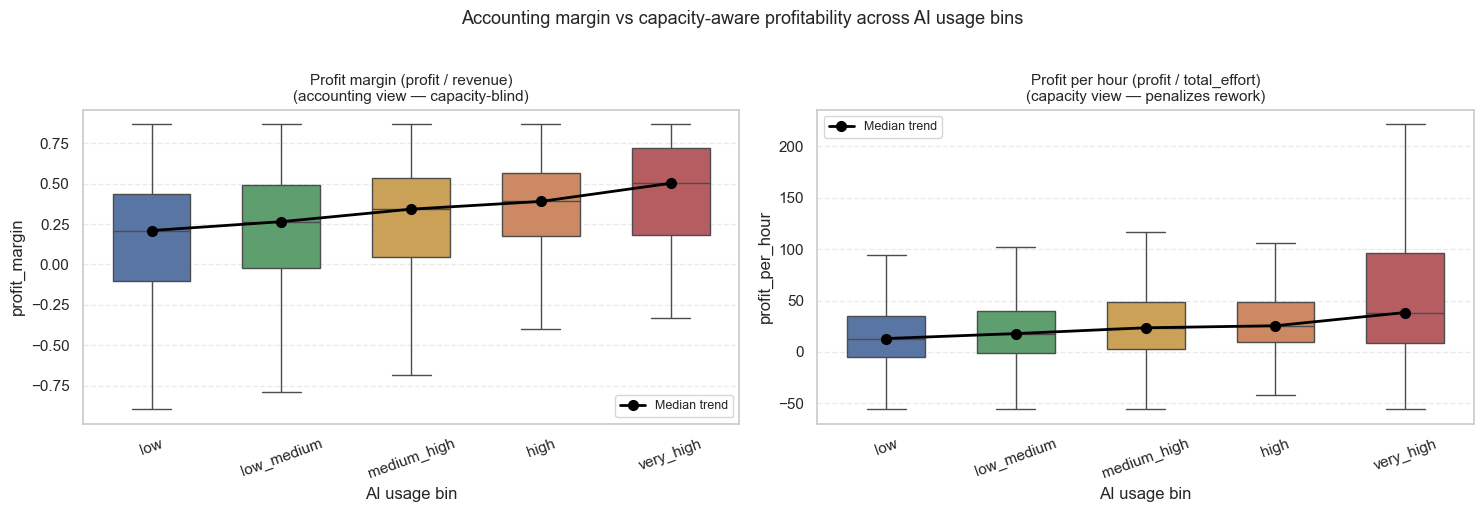

Median values by AI usage bin:
              profit_margin  profit_per_hour  n_tasks
ai_usage_bin                                         
low                   0.210           13.083      734
low_medium            0.265           17.880     1151
medium_high           0.342           23.518      882
high                  0.390           25.488      369
very_high             0.502           38.341       57

Change vs 'low' baseline (%):
             profit_margin profit_per_hour
ai_usage_bin                              
low                   0.0%            0.0%
low_medium           26.2%           36.7%
medium_high          62.9%           79.8%
high                 85.7%           94.8%
very_high           139.0%          193.1%


In [286]:
# ---------------------------------------------------------------
#  — Capacity-aware view: profit_per_hour vs profit_margin
# ---------------------------------------------------------------

bin_order = ['low', 'low_medium', 'medium_high', 'high', 'very_high']
palette = ['#4C72B0', '#55A868', '#DDA744', '#DD8452', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

panels = [
    ('profit_margin',   'Profit margin (profit / revenue)',
     'accounting view — capacity-blind'),
    ('profit_per_hour', 'Profit per hour (profit / total_effort)',
     'capacity view — penalizes rework'),
]

for ax, (col, title, subtitle) in zip(axes, panels):
    plot_df = df[[col, 'ai_usage_bin']].dropna()
    lo, hi = plot_df[col].quantile([0.01, 0.99])
    plot_df[col] = plot_df[col].clip(lo, hi)

    sns.boxplot(data=plot_df, x='ai_usage_bin', y=col, order=bin_order,
                palette=palette, ax=ax, showfliers=False, width=0.6)

    medians = plot_df.groupby('ai_usage_bin', observed=True)[col].median().reindex(bin_order)
    ax.plot(range(len(bin_order)), medians.values,
            color='black', marker='o', linewidth=2, markersize=7,
            label='Median trend', zorder=10)

    ax.set_title(f'{title}\n({subtitle})', fontsize=11)
    ax.set_xlabel('AI usage bin')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=9)

plt.suptitle('Accounting margin vs capacity-aware profitability across AI usage bins',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Numeric companion
summary = (
    df.groupby('ai_usage_bin', observed=True)[['profit_margin', 'profit_per_hour']]
      .median()
      .reindex(bin_order)
      .round(3)
)
summary['n_tasks'] = df.groupby('ai_usage_bin', observed=True).size().reindex(bin_order)
print("Median values by AI usage bin:")
print(summary)

# Percentage change vs 'low' baseline
baseline = summary.loc['low', ['profit_margin', 'profit_per_hour']]
delta_pct = ((summary[['profit_margin', 'profit_per_hour']] / baseline) - 1) * 100
print("\nChange vs 'low' baseline (%):")
print(delta_pct.round(1).astype(str) + '%')

**Reading 6.2.2.**

| AI bin | profit_margin vs low | profit_per_hour vs low |
|---|---|---|
| medium_high | +63% | +80% |
| high | +86% | +95% |
| very_high | +139% | **+193%** |

`profit_per_hour` rises monotonically and faster than `profit_margin` across all bins. **Both views agree: no threshold appears at the aggregate level.** AI generates more rework but the value capture more than compensates everywhere we look.

The `very_high` cell (n=57) shows the steepest gain (+193%), but it rests on a small sample. Even so, the direction is unambiguous: rework does not destroy margin in aggregate.

----
### 6.2.3 Answer to Question 2

**At the aggregate level, no rework threshold exists in this dataset.** The chain `rework → margin destruction` does not behave as the brief hypothesized:

- Spearman correlation between rework and margin is **positive** (ρ = +0.13)
- Profitability rises with AI bins on both accounting and capacity views (+139% margin, +193% profit per hour at very_high)
- Tasks in the highest rework quintile have higher margins than tasks in the lowest

**The threshold does exist, but only inside one segment.** The aggregate-level "no threshold" result is the headline answer. Section 6.3 (Question 3) will reveal where the threshold actually lives — inside the `hourly` pricing model.

**This is itself a finding for Alkemy.** The original framing of the question ("oltre quale soglia il rework distrugge il margine") presupposes a universal mechanism. The data shows no universal mechanism exists; instead, the destructive dynamic is conditional on pricing structure. Reframing the question as *"under which conditions does rework destroy margin?"* is the correct path — and the answer comes next.

----
## 6.3 Question 3 — When does the hourly model become unsustainable?

> **"When does the hourly model become unsustainable?"**

The question explicitly singles out `pricing_model = hourly`. We test two complementary mechanisms:

- **6.3.1** — How profitability behaves across AI bins for each pricing model (does hourly diverge from fixed/value_based?)
- **6.3.2** — Whether seniority modulates the hourly pattern (the brief's hypothesis on juniors and rework)
- **6.3.3** — A decision-grade view: loss rates by `pricing_model × ai_usage_bin`
- **6.3.4** — Direct answer

### 6.3.1 The pricing mismatch: hourly vs fixed vs value_based

Under `fixed` and `value_based`, revenue is set up-front and decoupled from hours worked. Under `hourly`, revenue tracks billed hours — if AI cuts hours, revenue drops in step. We segment `profit_margin` and `profit_per_hour` by `pricing_model × ai_usage_bin` to see whether the hourly model's value-capture mechanism breaks.

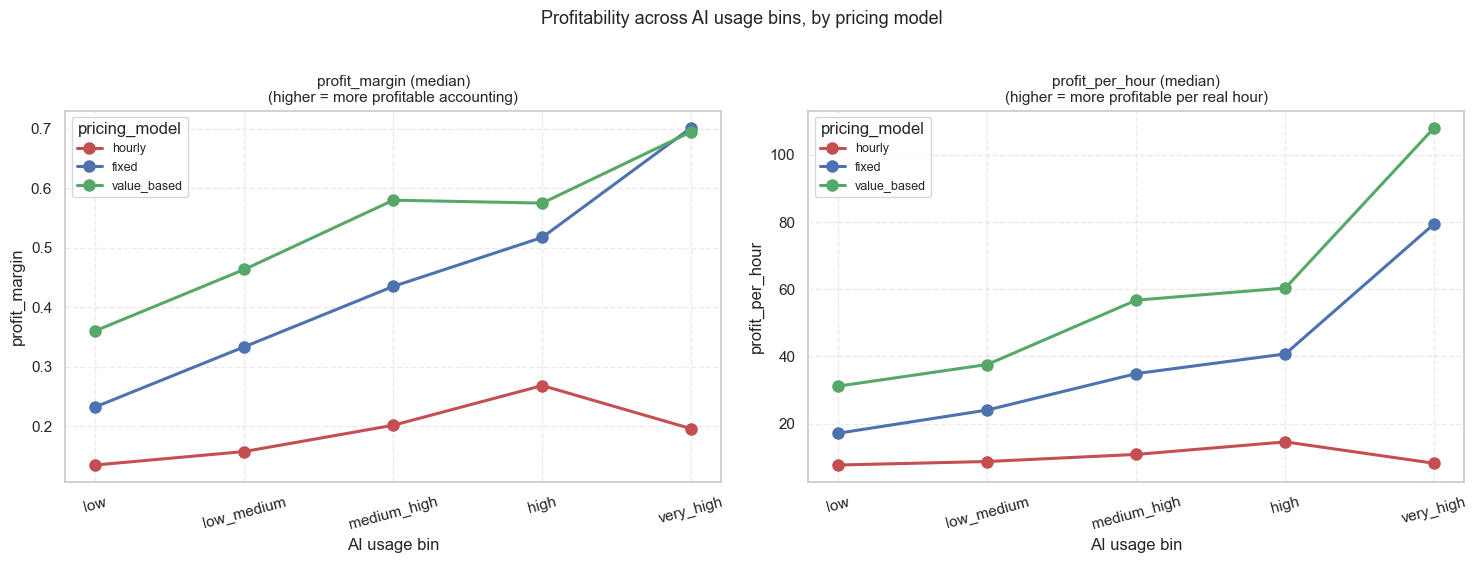

Median profit_margin by pricing_model × AI bin:
ai_usage_bin     low  low_medium  medium_high   high  very_high
pricing_model                                                  
hourly         0.135       0.157        0.201  0.268      0.195
fixed          0.232       0.333        0.435  0.517      0.702
value_based    0.360       0.463        0.580  0.575      0.695

Sample sizes (n):
ai_usage_bin   low  low_medium  medium_high  high  very_high
pricing_model                                               
hourly         350         562          416   187         26
fixed          285         423          330   139         23
value_based     99         166          136    43          8

Median profit_per_hour by pricing_model × AI bin:
ai_usage_bin     low  low_medium  medium_high   high  very_high
pricing_model                                                  
hourly          7.71        8.76        10.87  14.59       8.22
fixed          17.17       24.07        34.92  40.76      79.53
v

In [287]:
# ---------------------------------------------------------------
#  Profit margin and per-hour profitability × pricing_model × AI bin
# ---------------------------------------------------------------

bin_order = ['low', 'low_medium', 'medium_high', 'high', 'very_high']
pricing_order = ['hourly', 'fixed', 'value_based']
pricing_colors = {'hourly': '#C44E52', 'fixed': '#4C72B0', 'value_based': '#55A868'}

# Median target per (pricing_model, ai_bin) cell, plus sample sizes
def segment_summary(target):
    medians = (df.groupby(['pricing_model', 'ai_usage_bin'], observed=True)[target]
                 .median().unstack().reindex(index=pricing_order, columns=bin_order))
    counts = (df.groupby(['pricing_model', 'ai_usage_bin'], observed=True)
                .size().unstack().reindex(index=pricing_order, columns=bin_order)
                .fillna(0).astype(int))
    return medians, counts

margin_med, margin_n = segment_summary('profit_margin')
pph_med,    pph_n    = segment_summary('profit_per_hour')

# --- Plot: side-by-side line charts ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

panels = [
    (margin_med, 'profit_margin (median)',   'profit_margin',
     'higher = more profitable accounting'),
    (pph_med,    'profit_per_hour (median)', 'profit_per_hour',
     'higher = more profitable per real hour'),
]

for ax, (data, title, ylabel, subtitle) in zip(axes, panels):
    for pm in pricing_order:
        ax.plot(bin_order, data.loc[pm], marker='o', linewidth=2.2,
                markersize=8, label=pm, color=pricing_colors[pm])

    ax.set_title(f'{title}\n({subtitle})', fontsize=11)
    ax.set_xlabel('AI usage bin')
    ax.set_ylabel(ylabel)
    ax.legend(title='pricing_model', loc='best', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Profitability across AI usage bins, by pricing model',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Numeric companion ---
print("=" * 72)
print("Median profit_margin by pricing_model × AI bin:")
print(margin_med.round(3))
print("\nSample sizes (n):")
print(margin_n)

print("\n" + "=" * 72)
print("Median profit_per_hour by pricing_model × AI bin:")
print(pph_med.round(2))

# --- Delta vs each pricing model's own 'low' baseline ---
print("\n" + "=" * 72)
print("profit_margin: % change vs each pricing_model's own 'low' baseline:")
margin_delta = ((margin_med.div(margin_med['low'], axis=0)) - 1) * 100
print(margin_delta.round(1).astype(str) + '%')

print("\nprofit_per_hour: % change vs each pricing_model's own 'low' baseline:")
pph_delta = ((pph_med.div(pph_med['low'], axis=0)) - 1) * 100
print(pph_delta.round(1).astype(str) + '%')

**Reading 6.3.1.**

Three distinct profitability regimes emerge.

| pricing_model | low margin | very_high margin | shape |
|---|---|---|---|
| value_based | 36% | 70% | monotonic, large baseline gap |
| fixed | 23% | 70% | monotonic, steepest gain |
| **hourly** | 14% | **20%** | **rises to `high`, collapses at `very_high`** |

The hourly curve is the only one that breaks. Margin peaks at 27% at `high` (60-80% AI) and drops back to 20% at `very_high`. The capacity view makes it sharper: hourly profit_per_hour peaks at 14.6€/h at `high` and crashes to 8.2€/h at `very_high` — back to the `low` baseline. The +89% gain at high becomes +6.6% at very_high.

**The mechanism behind the collapse.** When AI cuts hours on an hourly contract, billed hours fall and revenue follows. Recorded cost falls too, but rework hours (unbillable, +134% across bins) stay on the company's side. Above 60-80% AI usage, revenue contraction overtakes cost saving and value capture breaks.

**The threshold:** within hourly, the model becomes unsustainable above **~60-80% AI usage**.

**Caveats.** `very_high × hourly` has n=26 and `very_high × value_based` has n=8 — the rightmost column of the hourly story is illustrative; the consistent pattern across larger cells (n=350 to n=562 for hourly low/low_medium) is what supports the conclusion.

-----
### 6.3.2 Does seniority modulate the hourly collapse?

The brief hypothesizes that juniors benefit most from AI but generate hidden rework. If true, the hourly collapse at very_high should be junior-driven. We test this by faceting `profit_margin × ai_bin × seniority` separately for each pricing model.

Seniority levels found: ['junior', 'mid', 'senior']


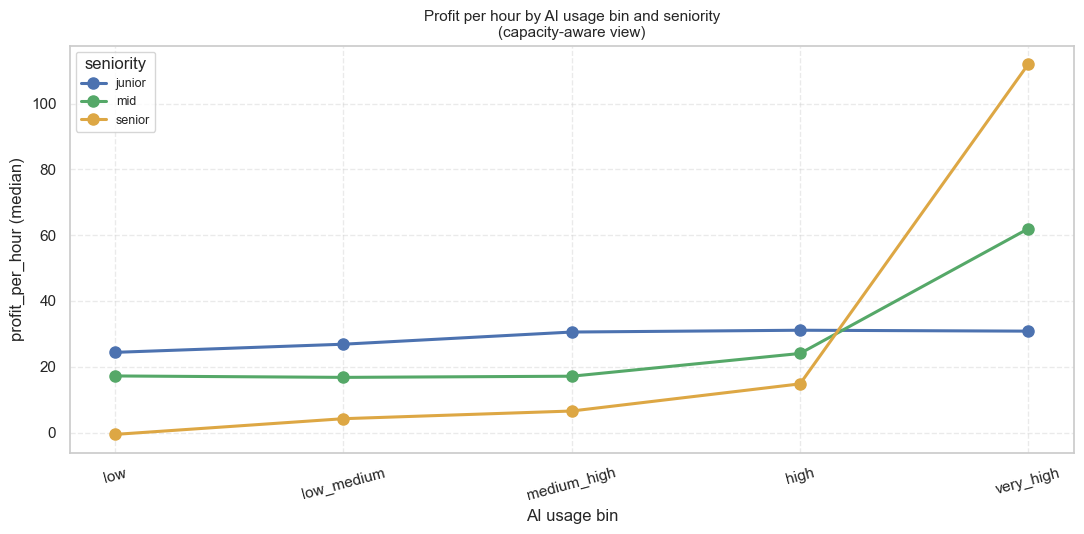

Median profit_per_hour by seniority × AI bin:
ai_usage_bin    low  low_medium  medium_high   high  very_high
seniority                                                     
junior        24.38       26.86        30.55  31.10      30.83
mid           17.21       16.78        17.13  24.04      61.98
senior        -0.55        4.22         6.55  14.81     112.00

Sample sizes (n):
ai_usage_bin  low  low_medium  medium_high  high  very_high
seniority                                                  
junior        155         408          376   192         36
mid           320         462          343   134         17
senior        259         281          163    43          4

--- profit_margin: pricing_model = hourly ---
ai_usage_bin    low  low_medium  medium_high   high  very_high
seniority                                                     
junior        0.276       0.305        0.351  0.353      0.150
mid           0.196       0.101        0.096  0.229      0.394
senior       -0.196  

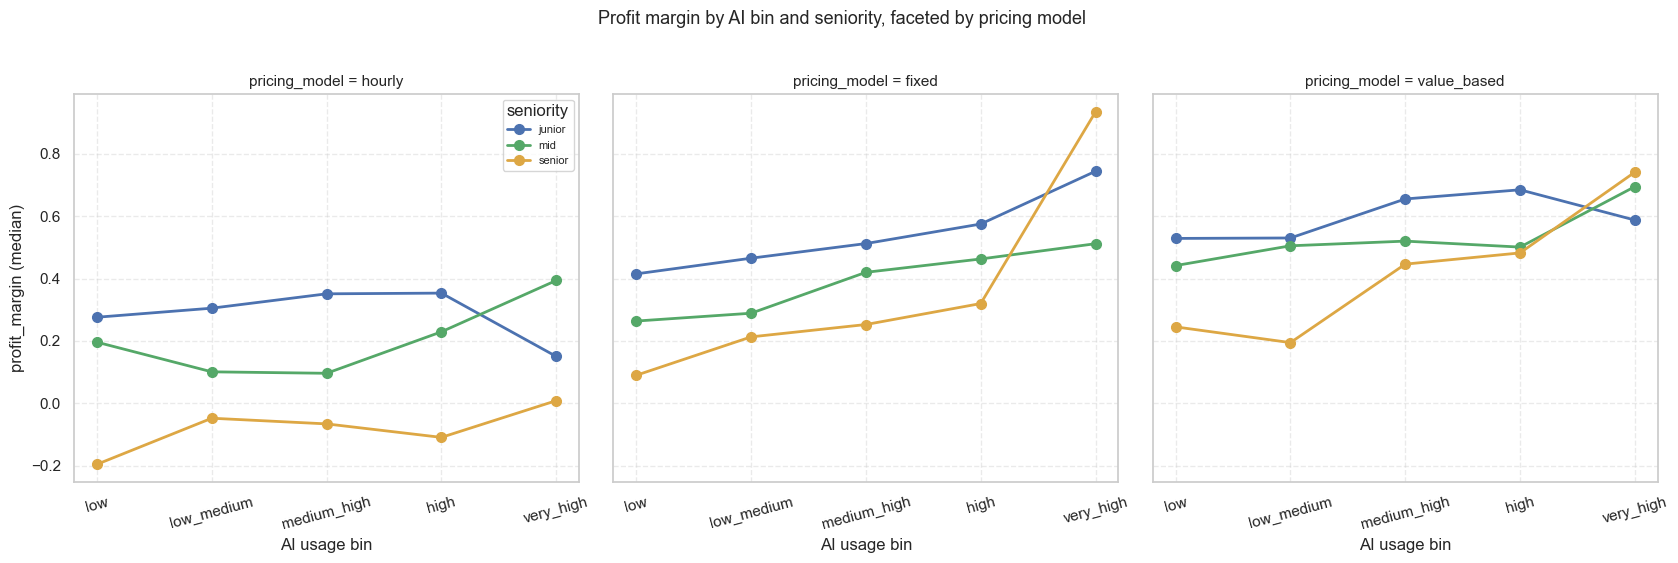

In [288]:
# ---------------------------------------------------------------
# 6.9 — AI bin × seniority, with and without pricing model
# ---------------------------------------------------------------

bin_order = ['low', 'low_medium', 'medium_high', 'high', 'very_high']
seniority_order = sorted(df['seniority'].dropna().unique())  # adapt to actual labels
print("Seniority levels found:", seniority_order)
seniority_colors = ['#4C72B0', '#55A868', '#DDA744', '#C44E52', '#8172B2'][:len(seniority_order)]

# --- Plot 1: profit_per_hour × ai_usage_bin × seniority (no pricing) ---
fig, ax = plt.subplots(figsize=(11, 5.5))

medians_pph = (df.groupby(['seniority', 'ai_usage_bin'], observed=True)['profit_per_hour']
                 .median().unstack().reindex(index=seniority_order, columns=bin_order))
counts_pph = (df.groupby(['seniority', 'ai_usage_bin'], observed=True)
                .size().unstack().reindex(index=seniority_order, columns=bin_order)
                .fillna(0).astype(int))

for sen, color in zip(seniority_order, seniority_colors):
    ax.plot(bin_order, medians_pph.loc[sen], marker='o', linewidth=2.2,
            markersize=8, label=sen, color=color)

ax.set_title('Profit per hour by AI usage bin and seniority\n(capacity-aware view)', fontsize=11)
ax.set_xlabel('AI usage bin')
ax.set_ylabel('profit_per_hour (median)')
ax.legend(title='seniority', loc='best', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print("Median profit_per_hour by seniority × AI bin:")
print(medians_pph.round(2))
print("\nSample sizes (n):")
print(counts_pph)

# --- Plot 2: profit_margin × ai_usage_bin × seniority, faceted by pricing_model ---
pricing_order = ['hourly', 'fixed', 'value_based']

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)

for ax, pm in zip(axes, pricing_order):
    sub = df[df['pricing_model'] == pm]
    medians_pm = (sub.groupby(['seniority', 'ai_usage_bin'], observed=True)['profit_margin']
                     .median().unstack().reindex(index=seniority_order, columns=bin_order))
    counts_pm = (sub.groupby(['seniority', 'ai_usage_bin'], observed=True)
                    .size().unstack().reindex(index=seniority_order, columns=bin_order)
                    .fillna(0).astype(int))

    for sen, color in zip(seniority_order, seniority_colors):
        ax.plot(bin_order, medians_pm.loc[sen], marker='o', linewidth=2.0,
                markersize=7, label=sen, color=color)

    ax.set_title(f'pricing_model = {pm}', fontsize=11)
    ax.set_xlabel('AI usage bin')
    ax.set_ylabel('profit_margin (median)' if pm == 'hourly' else '')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=15)
    if pm == 'hourly':
        ax.legend(title='seniority', loc='best', fontsize=8)

    # Print mini-table for this pricing
    print(f"\n--- profit_margin: pricing_model = {pm} ---")
    print(medians_pm.round(3))
    print(f"Sample sizes:")
    print(counts_pm)

plt.suptitle('Profit margin by AI bin and seniority, faceted by pricing model',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Reading 6.3.2.**

The seniority segmentation reveals a pattern that **contradicts** the brief's hypothesis on one front and confirms it on another.

**Capacity view (`profit_per_hour`, no pricing).**

| seniority | low | very_high | shape |
|---|---|---|---|
| junior | 24.4 | 30.8 | **flat** from medium_high onward |
| mid | 17.2 | 62.0 | late inflection at high |
| senior | -0.5 | 112.0 (n=4) | **steepest rise** |

Juniors are the most productive at low AI and stay flat across bins — AI doesn't help them. Seniors start near break-even and rise the most as AI usage increases. **The brief's intuition was inverted: seniors gain most from AI, not juniors.**

**Hourly view, by seniority.**

| seniority | low | high | very_high |
|---|---|---|---|
| junior | 0.276 | 0.353 | **0.150** (collapse) |
| mid | 0.196 | 0.229 | 0.394 |
| senior | -0.196 | -0.109 | 0.008 |

The hourly collapse at `very_high` is **junior-driven**. Mid and senior staff don't show it. Seniors are structurally unprofitable on hourly across all bins (-20% to -11%) for a different reason — their cost rate exceeds the hourly billing logic regardless of AI.

**Two distinct hourly stories:**
1. Juniors on hourly: AI pays off until ~60-80%, then breaks (the localized paradox)
2. Seniors on hourly: structurally unprofitable across the board (a pricing-cost-rate mismatch unrelated to AI)

---
### 6.3.3 The decision view: loss rate heatmap

Median margin describes the typical task. For a decision deliverable, the more useful metric is the **share of tasks delivered at a loss** in each segment. We compute the loss rate (% of tasks with `profit_margin < 0`) for each `pricing_model × ai_usage_bin` cell.

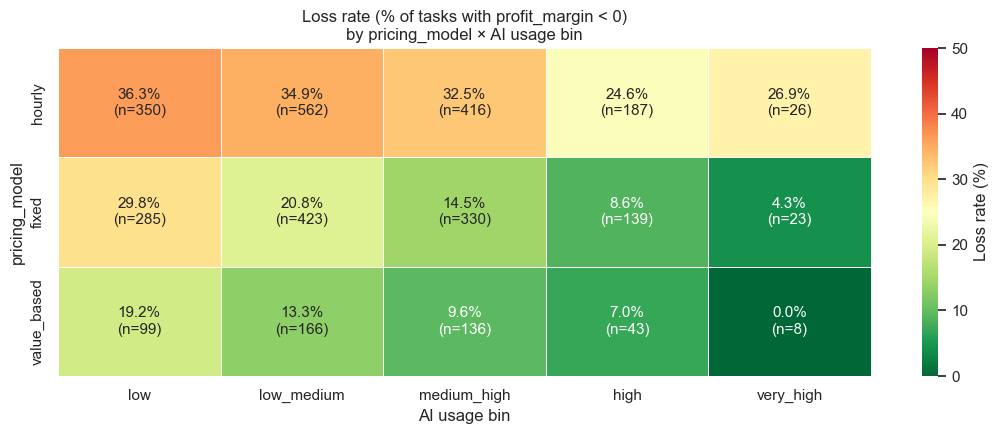

Loss rate (%) by pricing_model × AI bin:
ai_usage_bin    low  low_medium  medium_high  high  very_high
pricing_model                                                
hourly         36.3        34.9         32.5  24.6       26.9
fixed          29.8        20.8         14.5   8.6        4.3
value_based    19.2        13.3          9.6   7.0        0.0

Sample sizes (n):
ai_usage_bin   low  low_medium  medium_high  high  very_high
pricing_model                                               
hourly         350         562          416   187         26
fixed          285         423          330   139         23
value_based     99         166          136    43          8

Overall loss rate (full dataset): 25.1%

Loss rate by pricing_model (overall):
pricing_model
hourly         33.2%
fixed          19.5%
value_based    12.6%
Name: profit_margin, dtype: object


In [289]:
# ---------------------------------------------------------------
# — Loss rate heatmap: pricing_model × ai_usage_bin
# ---------------------------------------------------------------

bin_order = ['low', 'low_medium', 'medium_high', 'high', 'very_high']
pricing_order = ['hourly', 'fixed', 'value_based']

# Loss rate per cell
df['_is_loss'] = (df['profit_margin'] < 0).astype(int)

loss_rate = (df.groupby(['pricing_model', 'ai_usage_bin'], observed=True)['_is_loss']
               .mean()
               .unstack()
               .reindex(index=pricing_order, columns=bin_order)) * 100

counts = (df.groupby(['pricing_model', 'ai_usage_bin'], observed=True)
            .size()
            .unstack()
            .reindex(index=pricing_order, columns=bin_order)
            .fillna(0).astype(int))

df.drop(columns='_is_loss', inplace=True)

# Annotate each cell with "loss%\n(n=N)"
annot = loss_rate.round(1).astype(str) + '%\n(n=' + counts.astype(str) + ')'

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(loss_rate, annot=annot, fmt='', cmap='RdYlGn_r',
            vmin=0, vmax=50, cbar_kws={'label': 'Loss rate (%)'},
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'fontsize': 11})

ax.set_title('Loss rate (% of tasks with profit_margin < 0)\nby pricing_model × AI usage bin',
             fontsize=12)
ax.set_xlabel('AI usage bin')
ax.set_ylabel('pricing_model')
plt.tight_layout()
plt.show()

# Numeric summary
print("Loss rate (%) by pricing_model × AI bin:")
print(loss_rate.round(1))
print("\nSample sizes (n):")
print(counts)

# Aggregate context
overall_loss_rate = (df['profit_margin'] < 0).mean() * 100
print(f"\nOverall loss rate (full dataset): {overall_loss_rate:.1f}%")

# Pricing-model loss rate (regardless of AI bin)
print("\nLoss rate by pricing_model (overall):")
pm_loss = (df.groupby('pricing_model', observed=True)['profit_margin']
             .apply(lambda s: (s < 0).mean() * 100)
             .reindex(pricing_order).round(1))
print(pm_loss.astype(str) + '%')

**Reading 6.3.3.**

| | low | low_medium | medium_high | high | very_high |
|---|---|---|---|---|---|
| **hourly** | 36% | 35% | 33% | 25% | 27% |
| **fixed** | 30% | 21% | 15% | 9% | 4% |
| **value_based** | 19% | 13% | 10% | 7% | 0% |

Three patterns, all consistent with the previous sections.

1. **Pricing model is the dominant axis of value destruction.** Hourly: 33% loss rate overall. Value_based: 13%. The pricing-model gap is **larger than the AI gap within any single pricing row**.

2. **AI helps in every pricing model, but the curves differ.** Fixed and value_based descend monotonically (29.8 → 4.3% and 19.2 → 0.0%). Hourly flattens around `medium_high` and reverses at `very_high` (24.6 → 26.9%).

3. **The killer cells:** `hourly × low` (36.3%, n=350) and `hourly × low_medium` (34.9%, n=562). Together these two cells contain ~322 loss-making tasks — the single largest concentration of value destruction in the company.

### 6.3.4 Answer to Question 3

**The hourly model is unsustainable in two distinct regimes.**

**Regime 1 — Structural (independent of AI usage).**
Hourly is the worst pricing model in absolute terms: 33% loss rate vs 20% (fixed) and 13% (value_based). This holds across all AI bins, including low. The structural problem is largest for senior staff — their cost rates exceed hourly billing logic regardless of AI.

**Regime 2 — Localized (AI-driven).**
Inside hourly, the value-capture mechanism breaks above **~60-80% AI usage**, with the collapse fully visible at ≥80%:
- profit_margin: 27% peak at `high` → 20% at `very_high` (-7 pts)
- profit_per_hour: 14.6€/h peak at `high` → 8.2€/h at `very_high` (back to baseline)
- loss rate: 24.6% at `high` → 26.9% at `very_high` (worsens)

The localized collapse is concentrated in **junior staff** (margin 35% → 15% at very_high, n=17). Mid and senior staff don't show it.

**Mechanism.** Under hourly, AI productivity gains leak back to the client through reduced billed hours. The unbillable rework cost (which grows +134% across bins) lands fully on the company. Above 60-80% AI usage, the revenue contraction overtakes the cost saving — the company runs faster but earns less.

**Outside hourly,** AI is monotonically value-creating. Both `fixed` and `value_based` reach <10% loss rate at `high` AI usage, with no reversal at `very_high`.

----
## 6.4 Synthesis: Deliverable for Alkemy

This section consolidates the answers to the three questions into the deliverable Alkemy explicitly asks for: **3 key insights + 1 concrete decision**. The "1 thing discovered thanks to AI" and "1 mistake made by AI" entries will be added at the end of the project once the modeling phase is complete.

### Three Key Insights (mechanisms, not platitudes)

**1. Pricing structure dominates AI usage as a profitability driver.**
The hourly-vs-value_based loss rate gap (33% vs 13%) is larger than the AI gap within any single pricing model. AI is the amplifier; pricing is the structure. Decisions on AI usage caps without addressing pricing structure miss the larger lever.
*Evidence: 6.3.3*

**2. The AI productivity paradox is localized, not aggregate.**
At the aggregate level, AI is monotonically value-creating: profit_margin +139%, profit_per_hour +193% from low to very_high AI usage. The destructive paradox only appears in `hourly × very_high × junior` — the only segment where AI actively destroys margin (35% → 15%).
*Evidence: 6.2.2, 6.3.1, 6.3.2*

**3. The seniority hypothesis was inverted.**
The brief predicted juniors gain most from AI; the data shows juniors are flat across AI bins (~30€/h regardless of AI usage) and seniors gain most as AI usage rises. The reasoning is plausible: AI compresses cognitive overhead more for complex senior tasks than it adds productivity to simpler junior ones.
*Evidence: 6.3.2*

### One Concrete Decision

**Migrate hourly tasks to fixed/value_based pricing — prioritized by volume and AI intensity.**

| Priority | Target segment | Current loss rate | Estimated impact |
|---|---|---|---|
| 1 | Hourly × low + low_medium AI (n≈912) | >34% | Largest absolute reduction in losses |
| 2 | Hourly × very_high × junior (n=17) | 32% margin loss vs `high` peak | Stops the localized paradox |
| 3 | Hourly × senior (any AI) | Structurally negative | Separate review, unrelated to AI |

While migration progresses, cap AI usage at the `medium_high` band (40-60%) for junior staff on tasks that must remain on hourly pricing.

### Hand-off to Section 7 (modeling)

The pre-modeling analysis answers Alkemy's questions qualitatively. The modeling phase will:

- **Quantify** the exact AI threshold within hourly (currently bracketed 60-80%)
- **Test multivariate controls** (task_type, complexity, brief_quality, client_tier) not segmented here
- **Validate generalization** via cross-validation, especially in the small `very_high × hourly × junior` cell (n=17)
- **Produce counterfactuals**: estimated loss-rate reduction from migrating hourly tasks to fixed pricing — the financial backbone of the decision recommendation